# 📊 Multi-Asset Sector-Constrained Portfolio Optimization

## เป้าหมาย
- ดาวน์โหลดข้อมูลสินทรัพย์ 30 ตัว จากหลากหลาย Asset Class & ภูมิภาค
- รวมหุ้น US, หุ้นไทย, หุ้นจีน, พันธบัตร (US/จีน/ไทย-EM), ทองคำ, Silver
- จำกัดน้ำหนัก (Weight) ในแต่ละกลุ่ม (Sector/Asset Class) เพื่อป้องกันการกระจุกตัว
- เปรียบเทียบพอร์ตที่มี Sector Constraint vs ไม่มี


## 1. Install & Import Libraries


In [1]:
!pip install yfinance pandas numpy matplotlib seaborn scipy pyswarm -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from datetime import datetime, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12


## 2. กำหนดสินทรัพย์ 30 ตัว (Multi-Asset, Multi-Region)

ครอบคลุม 9 กลุ่ม: US Tech, Healthcare, Financial, Energy, Consumer, Thai, Chinese, Crypto, Bonds, Commodities


In [2]:
# กำหนด Asset 30 ตัว แยกตาม Sector / Asset Class
# คัดเลือกเฉพาะตัวที่มี Sharpe Ratio > 0.5 (ย้อนหลัง 4 ปี)
stock_sector_map = {
    # US Technology (30 ตัว) - เน้นกลุ่ม Tech ขนาดใหญ่, เซมิคอนดักเตอร์ และซอฟต์แวร์
    'AAPL':      'US Technology',
    'NVDA':      'US Technology',
    'META':      'US Technology',
    # 'AVGO':      'US Technology',      # Sharpe 1.219
    'GOOGL':     'US Technology',      # Sharpe 0.854
    'MSFT':      'US Technology',
    # 'AMZN':      'US Technology',
    # 'TSLA':      'US Technology',
    # 'AMD':       'US Technology',
    # 'INTC':      'US Technology',
    # 'CRM':       'US Technology',
    # 'ADBE':      'US Technology',
    # 'CSCO':      'US Technology',
    # 'ORCL':      'US Technology',
    # 'IBM':       'US Technology',
    # 'QCOM':      'US Technology',
    # 'TXN':       'US Technology',
    # 'NOW':       'US Technology',
    # 'INTU':      'US Technology',
    # 'AMAT':      'US Technology',
    # 'MU':        'US Technology',
    # 'PANW':      'US Technology',
    # 'SNPS':      'US Technology',
    # 'CDNS':      'US Technology',
    # 'KLAC':      'US Technology',
    # 'ANET':      'US Technology',
    # 'ROP':       'US Technology',
    # 'MCHP':      'US Technology',
    # 'MRVL':      'US Technology',
    # 'FTNT':      'US Technology',

    # US Healthcare (30 ตัว) - บริษัทยา, อุปกรณ์การแพทย์ และประกันสุขภาพ
    'JNJ':       'US Healthcare',
    'ABBV':      'US Healthcare',
    'LLY':       'US Healthcare',
    'UNH':       'US Healthcare',
    'MRK':       'US Healthcare',
    # 'TMO':       'US Healthcare',
    # 'DHR':       'US Healthcare',
    # 'PFE':       'US Healthcare',
    # 'AMGN':      'US Healthcare',
    # 'ISRG':      'US Healthcare',
    # 'SYK':       'US Healthcare',
    # 'BDX':       'US Healthcare',
    # 'CI':        'US Healthcare',
    # 'VRTX':      'US Healthcare',
    # 'REGN':      'US Healthcare',
    # 'ZTS':       'US Healthcare',
    # 'BSX':       'US Healthcare',
    # 'HUM':       'US Healthcare',
    # 'MDT':       'US Healthcare',
    # 'MCK':       'US Healthcare',
    # 'COR':       'US Healthcare',
    # 'EW':        'US Healthcare',
    # 'CNC':       'US Healthcare',
    # 'IQV':       'US Healthcare',
    # 'HCA':       'US Healthcare',
    # 'BIIB':      'US Healthcare',
    # 'ILMN':      'US Healthcare',
    # 'RMD':       'US Healthcare',
    # 'IDXX':      'US Healthcare',
    # 'MTD':       'US Healthcare',

    # US Financial (30 ตัว) - ธนาคาร, บัตรเครดิต, ประกัน และจัดการกองทุน
    'JPM':       'US Financial',
    'GS':        'US Financial',
    'V':         'US Financial',       # Sharpe 0.750
    'MA':        'US Financial',
    'BAC':       'US Financial',
    # 'WFC':       'US Financial',
    # 'MS':        'US Financial',
    # 'SCHW':      'US Financial',
    # 'AXP':       'US Financial',
    # 'C':         'US Financial',
    # 'SPGI':      'US Financial',
    # 'BLK':       'US Financial',
    # 'PGR':       'US Financial',
    # 'CB':        'US Financial',
    # 'CME':       'US Financial',
    # 'PYPL':      'US Financial',
    # 'ICE':       'US Financial',
    # 'AON':       'US Financial',
    # 'USB':       'US Financial',
    # 'PNC':       'US Financial',
    # 'TFC':       'US Financial',
    # 'COF':       'US Financial',
    # 'BK':        'US Financial',
    # 'AIG':       'US Financial',
    # 'TRV':       'US Financial',
    # 'PRU':       'US Financial',
    # 'MET':       'US Financial',
    # 'STT':       'US Financial',

    # US Energy (30 ตัว) - พลังงานต้นน้ำ กลางน้ำ ปลายน้ำ และบริการขุดเจาะ
    'XOM':       'US Energy',
    'MPC':       'US Energy',
    'CVX':       'US Energy',
    'COP':       'US Energy',
    'EOG':       'US Energy',
    # 'SLB':       'US Energy',
    # 'OXY':       'US Energy',
    # 'VLO':       'US Energy',
    # 'WMB':       'US Energy',
    # 'PSX':       'US Energy',
    # 'BKR':       'US Energy',
    # 'HAL':       'US Energy',
    # 'KMI':       'US Energy',
    # 'DVN':       'US Energy',
    # 'TRGP':      'US Energy',
    # 'CTRA':      'US Energy',
    # 'FANG':      'US Energy',
    # 'EQT':       'US Energy',
    # 'OKE':       'US Energy',
    # 'APA':       'US Energy',
    # 'MUR':       'US Energy',
    # 'MTDR':      'US Energy',
    # 'PR':        'US Energy',
    # 'CHRD':      'US Energy',
    # 'SM':        'US Energy',
    # 'CIVI':      'US Energy',
    # 'MGY':       'US Energy',
    # 'CRK':       'US Energy',

    # US Consumer (30 ตัว) - ครอบคลุมอุปโภคบริโภคจำเป็น ฟุ่มเฟือย และอุตสาหกรรม
    'CAT':       'US Consumer',
    'WMT':       'US Consumer',
    'COST':      'US Consumer',        # Sharpe 0.869
    'MCD':       'US Consumer',        # Sharpe 0.779
    'HD':        'US Consumer',
    # 'PG':        'US Consumer',
    # 'KO':        'US Consumer',
    # 'PEP':       'US Consumer',
    # 'NKE':       'US Consumer',
    # 'SBUX':      'US Consumer',
    # 'TGT':       'US Consumer',
    # 'LOW':       'US Consumer',
    # 'TJX':       'US Consumer',
    # 'EL':        'US Consumer',
    # 'CL':        'US Consumer',
    # 'KMB':       'US Consumer',
    # 'MDLZ':      'US Consumer',
    # 'SYY':       'US Consumer',
    # 'YUM':       'US Consumer',
    # 'DG':        'US Consumer',
    # 'ROST':      'US Consumer',
    # 'TSCO':      'US Consumer',
    # 'F':         'US Consumer',
    # 'GM':        'US Consumer',
    # 'GIS':       'US Consumer',
    # 'HSY':       'US Consumer',
    # 'KHC':       'US Consumer',
    # 'CHD':       'US Consumer',
    # 'CLX':       'US Consumer',

    # Thai Stocks (30 ตัว) - หุ้น SET50 ตัวหลักและมาร์เก็ตแคปสูง
    'DELTA.BK':  'Thai Stocks',
    'ADVANC.BK': 'Thai Stocks',
    'KBANK.BK':  'Thai Stocks',
    'PTT.BK':    'Thai Stocks',
    'AOT.BK':    'Thai Stocks',
    # 'PTTEP.BK':  'Thai Stocks',
    # 'CPALL.BK':  'Thai Stocks',
    # 'SCB.BK':    'Thai Stocks',
    # 'BDMS.BK':   'Thai Stocks',
    # 'GULF.BK':   'Thai Stocks',
    # 'BBL.BK':    'Thai Stocks',
    # 'SCC.BK':    'Thai Stocks',
    # 'CPN.BK':    'Thai Stocks',
    # 'EA.BK':     'Thai Stocks',
    # 'TISCO.BK':  'Thai Stocks',
    # 'KTB.BK':    'Thai Stocks',
    # 'MINT.BK':   'Thai Stocks',
    # 'CRC.BK':    'Thai Stocks',
    # 'TRUE.BK':   'Thai Stocks',
    # 'BEM.BK':    'Thai Stocks',
    # 'OSP.BK':    'Thai Stocks',
    # 'CBG.BK':    'Thai Stocks',
    # 'HMPRO.BK':  'Thai Stocks',
    # 'CPF.BK':    'Thai Stocks',
    # 'IVL.BK':    'Thai Stocks',
    # 'TU.BK':     'Thai Stocks',
    # 'TOP.BK':    'Thai Stocks',
    # 'SAWAD.BK':  'Thai Stocks',
    # 'MTC.BK':    'Thai Stocks',

    # Chinese Stocks (30 ตัว) - หุ้นจีนที่จดทะเบียนเป็น ADRs ในตลาดสหรัฐฯ
    'PDD':       'Chinese Stocks',
    'FUTU':      'Chinese Stocks',
    'BABA':      'Chinese Stocks',
    'JD':        'Chinese Stocks',
    'BIDU':      'Chinese Stocks',
    # 'NTES':      'Chinese Stocks',
    # 'TCOM':      'Chinese Stocks',
    # 'BILI':      'Chinese Stocks',
    # 'NIO':       'Chinese Stocks',
    # 'XPEV':      'Chinese Stocks',
    # 'LI':        'Chinese Stocks',
    # 'VIPS':      'Chinese Stocks',
    # 'ZTO':       'Chinese Stocks',
    # 'TME':       'Chinese Stocks',
    # 'BEKE':      'Chinese Stocks',
    # 'EDU':       'Chinese Stocks',
    # 'TAL':       'Chinese Stocks',
    # 'IQ':        'Chinese Stocks',
    # 'HUYA':      'Chinese Stocks',
    # 'DOYU':      'Chinese Stocks',
    # 'WB':        'Chinese Stocks',
    # 'YUMC':      'Chinese Stocks',
    # 'BZUN':      'Chinese Stocks',
    # 'GDS':       'Chinese Stocks',
    # 'MOMO':      'Chinese Stocks',
    # 'LU':        'Chinese Stocks',
    # 'YMM':       'Chinese Stocks',
    # 'TIGR':      'Chinese Stocks',
    # 'BBAI':      'Chinese Stocks',

    # Crypto (30 ตัว) - เหรียญคริปโตชั้นนำที่มี Market Cap ขนาดใหญ่
    'BTC-USD':   'Crypto',
    'ETH-USD':   'Crypto',             # Sharpe 0.200 but important for diversity
    'BNB-USD':   'Crypto',
    'SOL-USD':   'Crypto',
    'XRP-USD':   'Crypto',
    # 'ADA-USD':   'Crypto',
    # 'DOGE-USD':  'Crypto',
    # 'AVAX-USD':  'Crypto',
    # 'LINK-USD':  'Crypto',
    # 'DOT-USD':   'Crypto',
    # 'MATIC-USD': 'Crypto',
    # 'SHIB-USD':  'Crypto',
    # 'LTC-USD':   'Crypto',
    # 'BCH-USD':   'Crypto',
    # 'UNI-USD':   'Crypto',
    # 'ATOM-USD':  'Crypto',
    # 'XLM-USD':   'Crypto',
    # 'XMR-USD':   'Crypto',
    # 'ETC-USD':   'Crypto',
    # 'FIL-USD':   'Crypto',
    # 'NEAR-USD':  'Crypto',
    # 'VET-USD':   'Crypto',
    # 'ICP-USD':   'Crypto',
    # 'ALGO-USD':  'Crypto',
    # 'APE-USD':   'Crypto',
    # 'SAND-USD':  'Crypto',
    # 'MANA-USD':  'Crypto',
    # 'THETA-USD': 'Crypto',
    # 'AXS-USD':   'Crypto',
    # 'XTZ-USD':   'Crypto',

    # Bonds (30 ตัว) - กองทุนตราสารหนี้ พันธบัตรรัฐบาล และเอกชน
    'HYG':       'Bonds',
    'VCSH':      'Bonds',
    'EMLC':      'Bonds',
    'AGG':       'Bonds',
    'BND':       'Bonds',
    # 'LQD':       'Bonds',
    # 'TLT':       'Bonds',
    # 'IEF':       'Bonds',
    # 'SHY':       'Bonds',
    # 'IEI':       'Bonds',
    # 'MUB':       'Bonds',
    # 'TIP':       'Bonds',
    # 'MBB':       'Bonds',
    # 'GOVT':      'Bonds',
    # 'BIL':       'Bonds',
    # 'JNK':       'Bonds',
    # 'BNDX':      'Bonds',
    # 'EMB':       'Bonds',
    # 'VCIT':      'Bonds',
    # 'IGSB':      'Bonds',
    # 'BSV':       'Bonds',
    # 'VTEB':      'Bonds',
    # 'SPAB':      'Bonds',
    # 'BKLN':      'Bonds',
    # 'FALN':      'Bonds',
    # 'USIG':      'Bonds',
    # 'SCHZ':      'Bonds',
    # 'STIP':      'Bonds',
    # 'SCHO':      'Bonds',
    # 'SPMB':      'Bonds',

    # Commodities (30 ตัว) - สินค้าโภคภัณฑ์ กองทุนโลหะ พลังงาน และการเกษตร
    'GLD':       'Commodities',
    'SLV':       'Commodities',
    'COPX':      'Commodities',        # Copper miners, Sharpe 0.743
    'IAU':       'Commodities',
    'SGOL':      'Commodities',
    # 'SIVR':      'Commodities',
    # 'PALL':      'Commodities',
    # 'PPLT':      'Commodities',
    # 'USO':       'Commodities',
    # 'BNO':       'Commodities',
    # 'UNG':       'Commodities',
    # 'BOIL':      'Commodities',
    # 'WEAT':      'Commodities',
    # 'CORN':      'Commodities',
    # 'SOYB':      'Commodities',
    # 'JO':        'Commodities',
    # 'SGG':       'Commodities',
    # 'BAL':       'Commodities',
    # 'DBA':       'Commodities',
    # 'DBC':       'Commodities',
    # 'GSG':       'Commodities',
    # 'PDBC':      'Commodities',
    # 'URA':       'Commodities',
    # 'URNM':      'Commodities',
    # 'LIT':       'Commodities',
    # 'REMX':      'Commodities',
    # 'SIL':       'Commodities',
    # 'SILJ':      'Commodities',
    # 'GDX':       'Commodities',
    # 'GDXJ':      'Commodities',
}

stock_list = list(stock_sector_map.keys())
tickers = stock_list

# Summary
print(f'จำนวน Asset ทั้งหมด: {len(stock_list)} ตัว')
sectors = sorted(set(stock_sector_map.values()))
print(f'จำนวนกลุ่ม: {len(sectors)} กลุ่ม')
print()
for s in sectors:
    members = [t for t in stock_list if stock_sector_map[t] == s]
    print(f'  {s:20s} ({len(members)} ตัว): {", ".join(members)}')


จำนวน Asset ทั้งหมด: 50 ตัว
จำนวนกลุ่ม: 10 กลุ่ม

  Bonds                (5 ตัว): HYG, VCSH, EMLC, AGG, BND
  Chinese Stocks       (5 ตัว): PDD, FUTU, BABA, JD, BIDU
  Commodities          (5 ตัว): GLD, SLV, COPX, IAU, SGOL
  Crypto               (5 ตัว): BTC-USD, ETH-USD, BNB-USD, SOL-USD, XRP-USD
  Thai Stocks          (5 ตัว): DELTA.BK, ADVANC.BK, KBANK.BK, PTT.BK, AOT.BK
  US Consumer          (5 ตัว): CAT, WMT, COST, MCD, HD
  US Energy            (5 ตัว): XOM, MPC, CVX, COP, EOG
  US Financial         (5 ตัว): JPM, GS, V, MA, BAC
  US Healthcare        (5 ตัว): JNJ, ABBV, LLY, UNH, MRK
  US Technology        (5 ตัว): AAPL, NVDA, META, GOOGL, MSFT


## 3. ดาวน์โหลดข้อมูลราคา (4 ปี)


In [3]:
# กำหนดช่วงเวลา
end_date = datetime.now()
start_date = end_date - timedelta(days=365*4)  # 4 ปี

print(f"ช่วงเวลา: {start_date.strftime('%Y-%m-%d')} ถึง {end_date.strftime('%Y-%m-%d')}")
print(f"กำลังดาวน์โหลดข้อมูล {len(tickers)} ตัว...")
print()

# ดาวน์โหลดราคาปิด (Adjusted Close)
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)['Close']

# ลบแถวที่มี NaN
data = data.dropna(  how='any')
# data = data.ffill().dropna(axis=1)

print(f"\nได้ข้อมูล {data.shape[0]} Daysทำการ, {data.shape[1]} Asset")
print(f"\nAssetที่ได้: {list(data.columns)}")
data


ช่วงเวลา: 2022-03-26 ถึง 2026-03-25
กำลังดาวน์โหลดข้อมูล 50 ตัว...



[*********************100%***********************]  50 of 50 completed


ได้ข้อมูล 930 Daysทำการ, 50 Asset

Assetที่ได้: ['AAPL', 'ABBV', 'ADVANC.BK', 'AGG', 'AOT.BK', 'BABA', 'BAC', 'BIDU', 'BNB-USD', 'BND', 'BTC-USD', 'CAT', 'COP', 'COPX', 'COST', 'CVX', 'DELTA.BK', 'EMLC', 'EOG', 'ETH-USD', 'FUTU', 'GLD', 'GOOGL', 'GS', 'HD', 'HYG', 'IAU', 'JD', 'JNJ', 'JPM', 'KBANK.BK', 'LLY', 'MA', 'MCD', 'META', 'MPC', 'MRK', 'MSFT', 'NVDA', 'PDD', 'PTT.BK', 'SGOL', 'SLV', 'SOL-USD', 'UNH', 'V', 'VCSH', 'WMT', 'XOM', 'XRP-USD']


Ticker,AAPL,ABBV,ADVANC.BK,AGG,AOT.BK,BABA,BAC,BIDU,BNB-USD,BND,...,PTT.BK,SGOL,SLV,SOL-USD,UNH,V,VCSH,WMT,XOM,XRP-USD
Date,,,,,,,,,,,,,,,,,,,,,
2022-03-28,172.050171,139.997635,187.714630,92.987961,63.313255,109.300392,39.308689,147.449997,430.390869,69.019775,...,30.321262,18.400000,22.930000,106.465256,477.394897,214.122711,67.660187,46.276215,72.158730,0.863304
2022-03-29,175.342255,140.179169,191.760193,93.425102,63.796558,110.838905,39.209400,147.690002,434.505676,69.325760,...,30.126890,18.420000,22.910000,111.710312,475.097168,221.251419,67.886368,46.666084,71.775322,0.858000
2022-03-30,174.176285,141.536209,190.141968,93.678635,63.796558,110.715446,38.812260,143.830002,442.684845,69.483131,...,30.126890,18.559999,22.940001,120.699486,484.483246,217.206970,67.912445,47.502865,73.003975,0.860814
2022-03-31,171.080185,140.118652,188.523743,93.634918,64.038208,103.326820,37.205620,132.300003,428.916107,69.535576,...,29.932524,18.580000,22.879999,122.661461,474.390198,215.092590,67.921158,47.201752,71.967041,0.814564
2022-04-01,170.786224,140.611343,190.951065,93.468575,64.279869,104.656387,36.916775,140.970001,446.604279,69.384834,...,30.126890,18.450001,22.740000,134.430939,476.827484,219.544418,67.813126,47.864201,72.428879,0.827740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-17,254.229996,219.759995,379.000000,99.800003,49.500000,136.570007,47.279999,120.690002,668.780945,73.980003,...,34.000000,47.619999,71.660004,94.705971,287.570007,308.459991,79.339996,124.823830,158.809998,1.518544
2026-03-18,249.940002,208.339996,379.000000,99.379997,49.500000,134.429993,46.830002,121.870003,652.059082,73.680000,...,33.500000,46.130001,68.699997,90.065720,284.329987,299.019989,79.139999,121.730179,157.589996,1.463854
2026-03-19,248.960007,206.229996,376.000000,99.489998,48.000000,124.900002,47.009998,119.010002,639.266174,73.760002,...,34.250000,44.230000,65.680000,88.917847,280.440002,299.709991,79.230003,120.841995,158.160004,1.447323


### Currency Conversion (THB Base)
Convert all prices to THB for fair comparison:
- US stocks/ETFs: multiply by USD/THB exchange rate
- Thai stocks (.BK): already in THB
- Crypto: multiply by USD/THB


In [4]:
# ==========================================================
# Currency Conversion: All Prices to THB
# ==========================================================

# Download USD/THB exchange rate
print("Downloading USD/THB exchange rate...")
try:
    usdthb = yf.download("USDTHB=X", start=start_date, end=end_date, auto_adjust=True)["Close"]
    usdthb = usdthb.reindex(data.index).ffill().bfill()
    print(f"  USD/THB range: {float(usdthb.min().values[0]):.2f} - {float(usdthb.max().values[0]):.2f}")
    print(f"  USD/THB latest: {float(usdthb.iloc[-1].values[0]):.2f}")
except Exception as e:
    print(f"  Warning: Could not download USD/THB ({e})")
    print("  Using fixed rate: 35.00 THB/USD")
    usdthb = pd.Series(35.0, index=data.index)

# Convert to THB
data_thb = data.copy()
thai_tickers = [t for t in data.columns if t.endswith(".BK")]
usd_tickers = [t for t in data.columns if not t.endswith(".BK")]

for ticker in usd_tickers:
    data_thb[ticker] = data[ticker] * usdthb.values.flatten()

print(f"\nConverted {len(usd_tickers)} USD assets to THB")
print(f"Thai assets ({len(thai_tickers)}): already in THB")

# Show latest prices in THB
print("\nLatest Prices (THB):")
print("-" * 40)
latest_thb = data_thb.iloc[-1]
for ticker in sorted(data_thb.columns):
    currency = "THB" if ticker.endswith(".BK") else "USD->THB"
    print(f"  {ticker:12s} {latest_thb[ticker]:>12,.2f} THB  ({currency})")

# IMPORTANT: Use THB-converted data for returns going forward
data = data_thb
print("\n>> All prices converted to THB base for fair comparison")


[*********************100%***********************]  1 of 1 completed

  USD/THB range: 30.91 - 38.30
  USD/THB latest: 32.88

Converted 45 USD assets to THB
Thai assets (5): already in THB

Latest Prices (THB):
----------------------------------------
  AAPL             8,269.75 THB  (USD->THB)
  ABBV             6,738.71 THB  (USD->THB)
  ADVANC.BK          366.00 THB  (THB)
  AGG              3,256.40 THB  (USD->THB)
  AOT.BK              47.75 THB  (THB)
  BABA             4,145.23 THB  (USD->THB)
  BAC              1,562.60 THB  (USD->THB)
  BIDU             3,766.09 THB  (USD->THB)
  BNB-USD         20,997.01 THB  (USD->THB)
  BND              2,415.26 THB  (USD->THB)
  BTC-USD      2,331,893.28 THB  (USD->THB)
  CAT             23,074.00 THB  (USD->THB)
  COP              4,182.39 THB  (USD->THB)
  COPX             2,418.54 THB  (USD->THB)
  COST            31,756.10 THB  (USD->THB)
  CVX              6,747.92 THB  (USD->THB)
  DELTA.BK           260.00 THB  (THB)
  EMLC               830.62 THB  (USD->THB)
  EOG              4,593.10 THB  (USD->TH

In [5]:
data

Ticker,AAPL,ABBV,ADVANC.BK,AGG,AOT.BK,BABA,BAC,BIDU,BNB-USD,BND,...,PTT.BK,SGOL,SLV,SOL-USD,UNH,V,VCSH,WMT,XOM,XRP-USD
Date,,,,,,,,,,,,,,,,,,,,,
2022-03-28,5786.907209,4708.820214,187.714630,3127.649906,63.313255,3676.318507,1322.147692,4959.480400,14476.196161,2321.480029,...,30.321262,618.883956,771.250522,3580.958698,16057.176575,7202.017031,2275.750268,1556.500400,2427.058747,29.037229
2022-03-29,5923.762800,4735.813091,191.760193,3156.273691,63.796558,3744.581622,1324.650391,4989.559101,14679.339939,2342.101500,...,30.126890,622.301290,773.991444,3774.021221,16050.682911,7474.758030,2293.473077,1576.567010,2424.857506,28.986672
2022-03-30,5833.686312,4740.472256,190.141968,3137.578513,63.796558,3708.192452,1299.939014,4817.298256,14826.843526,2327.198522,...,30.126890,621.630063,768.329439,4042.587881,16226.797368,7274.913060,2274.591525,1591.013453,2445.122134,28.831243
2022-03-31,5700.220724,4668.613412,188.523743,3119.821863,64.038208,3442.746353,1239.654056,4408.103834,14291.055880,2316.855869,...,29.932524,619.067022,762.338698,4086.957245,15806.207115,7166.670070,2263.065075,1572.715177,2397.869857,27.140458
2022-04-01,5676.592348,4673.639685,190.951065,3106.708383,64.279869,3478.568893,1227.039721,4685.560754,14844.232548,2306.213050,...,30.126890,613.241106,755.832089,4468.215402,15848.791423,7297.217149,2253.972599,1590.910250,2407.390998,27.512422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-17,8224.339974,7109.235487,379.000000,3228.529946,49.500000,4418.039529,1529.507888,3904.321395,21635.062545,2393.252996,...,34.000000,1540.506893,2318.201009,3063.738010,9302.889298,9978.680253,2566.648760,4038.050699,5137.503179,49.124895
2026-03-18,8078.060803,6733.548618,379.000000,3211.961481,49.500000,4344.777322,1513.545645,3938.838452,21074.549332,2381.337587,...,33.500000,1490.921620,2220.383880,2910.924030,9189.545079,9664.325954,2557.804756,3934.319343,5093.308634,47.311759
2026-03-19,8165.888030,6764.343703,376.000000,3263.271854,48.000000,4096.719955,1541.927909,3903.527979,20967.930030,2419.328014,...,34.250000,1450.743951,2154.303960,2916.505303,9198.431866,9830.487491,2598.744050,3963.617352,5187.647999,47.472192


## 4. คำนวณ Returns และ Statistics


In [6]:
# Daily returns
returns = data.pct_change().dropna()

# Annualized statistics
annual_returns = returns.mean() * 252
annual_volatility = returns.std() * np.sqrt(252)
sharpe_ratios = annual_returns / annual_volatility

# สร้างตาราง summary
summary = pd.DataFrame({
    'Sector': [stock_sector_map[t] for t in returns.columns], 
    'Annual Return (%)': (annual_returns * 100).round(2), # ผลตอบแทนเฉลี่ยต่อปี
    'Annual Vol (%)': (annual_volatility * 100).round(2), # ความเสี่ยง หรือ ความเหวี่ยงรายปี
    'Sharpe Ratio': sharpe_ratios.round(3) # อัตราส่วนความคุ้มค่าเทียบกับความเสี่ยง -> การหา Annual Return / Annual Vol
})

print("=" * 70)
print("สรุปผลตอบแทนรายปี (Annualized)")
print("=" * 70)
summary.sort_values('Sharpe Ratio', ascending=False)


สรุปผลตอบแทนรายปี (Annualized)


,Sector,Annual Return (%),Annual Vol (%),Sharpe Ratio
Ticker,,,,
SGOL,Commodities,23.77,20.23,1.175
IAU,Commodities,23.69,20.29,1.167
WMT,US Consumer,28.39,24.37,1.165
NVDA,US Technology,64.00,54.97,1.164
GLD,Commodities,23.55,20.35,1.157
CAT,US Consumer,38.06,33.15,1.148
DELTA.BK,Thai Stocks,71.22,62.02,1.148
LLY,US Healthcare,37.51,35.51,1.056
GS,US Financial,31.27,30.09,1.039


In [7]:
summary.sort_values('Sharpe Ratio', ascending=False)


,Sector,Annual Return (%),Annual Vol (%),Sharpe Ratio
Ticker,,,,
SGOL,Commodities,23.77,20.23,1.175
IAU,Commodities,23.69,20.29,1.167
WMT,US Consumer,28.39,24.37,1.165
NVDA,US Technology,64.00,54.97,1.164
GLD,Commodities,23.55,20.35,1.157
CAT,US Consumer,38.06,33.15,1.148
DELTA.BK,Thai Stocks,71.22,62.02,1.148
LLY,US Healthcare,37.51,35.51,1.056
GS,US Financial,31.27,30.09,1.039


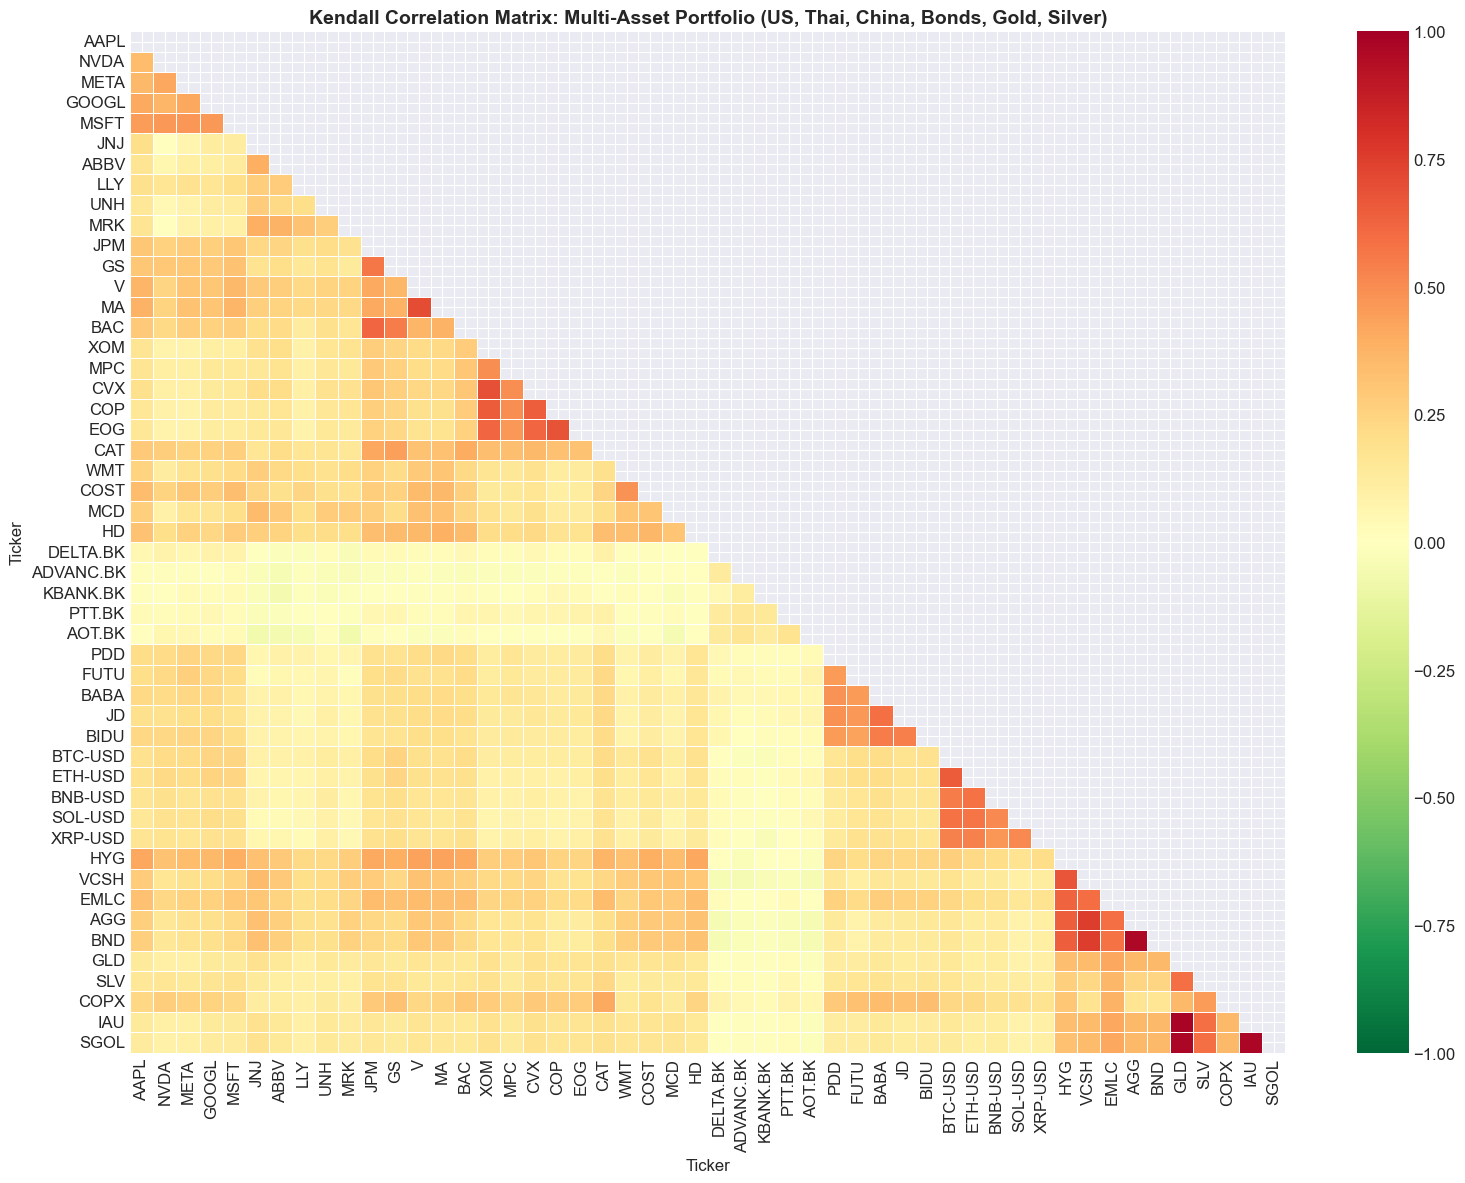

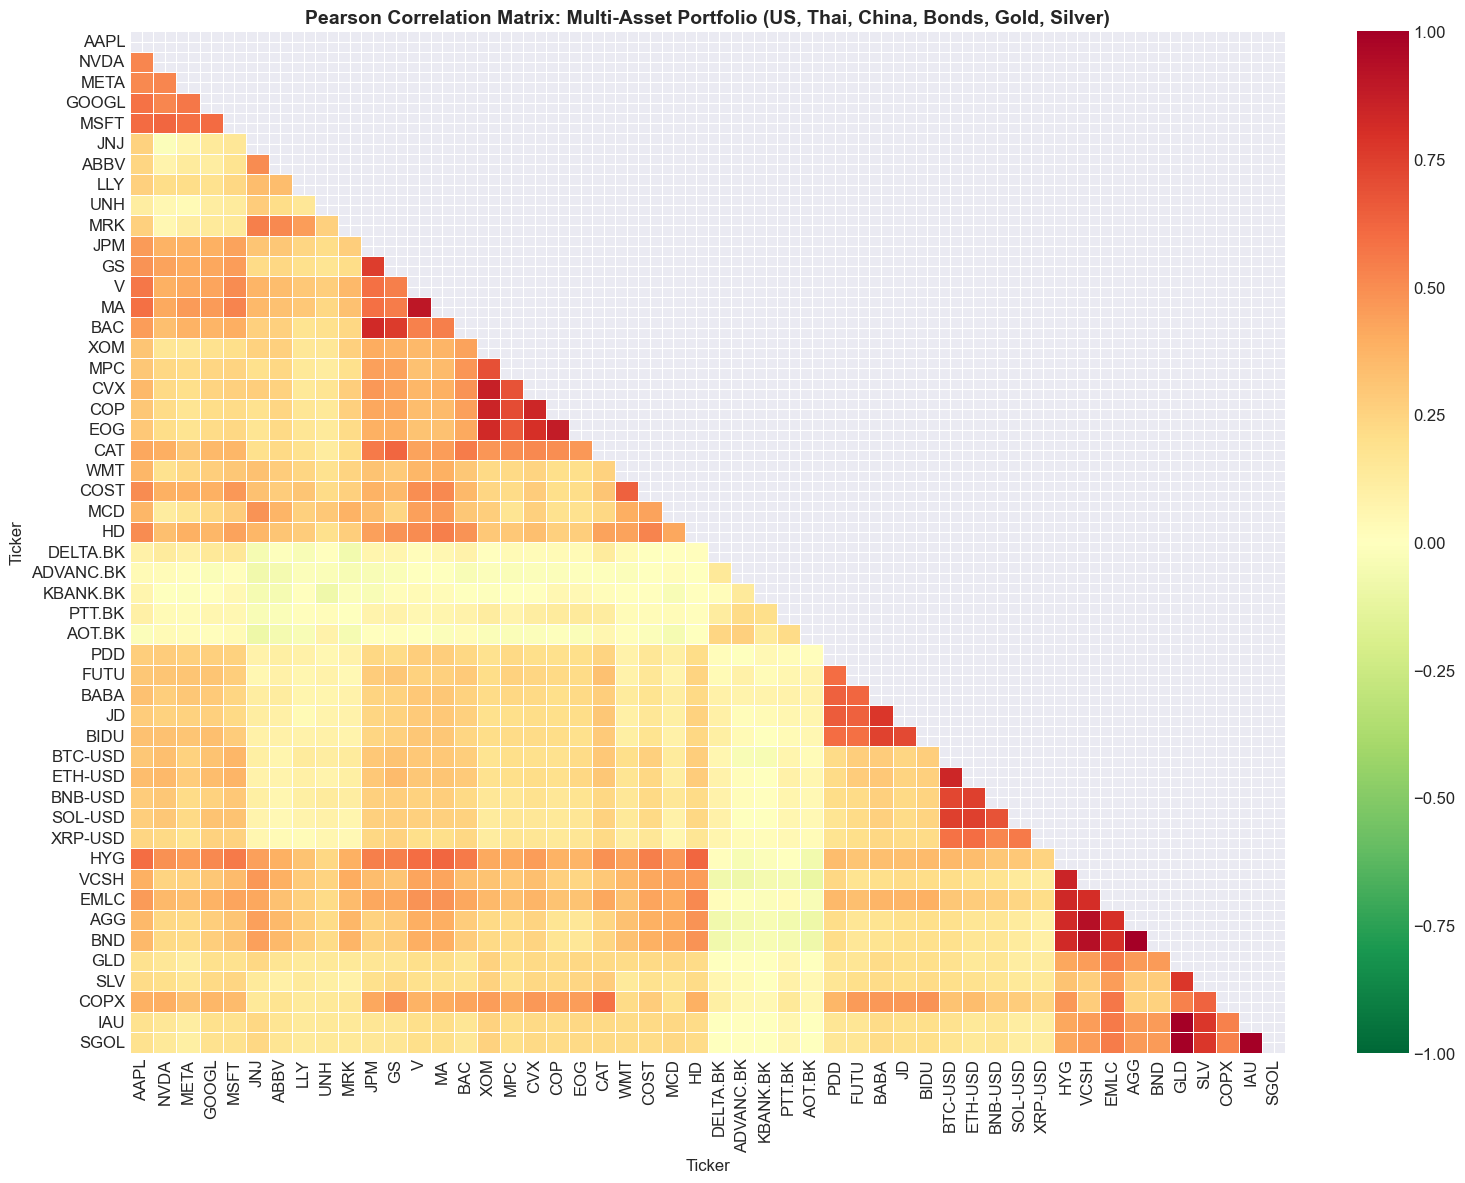

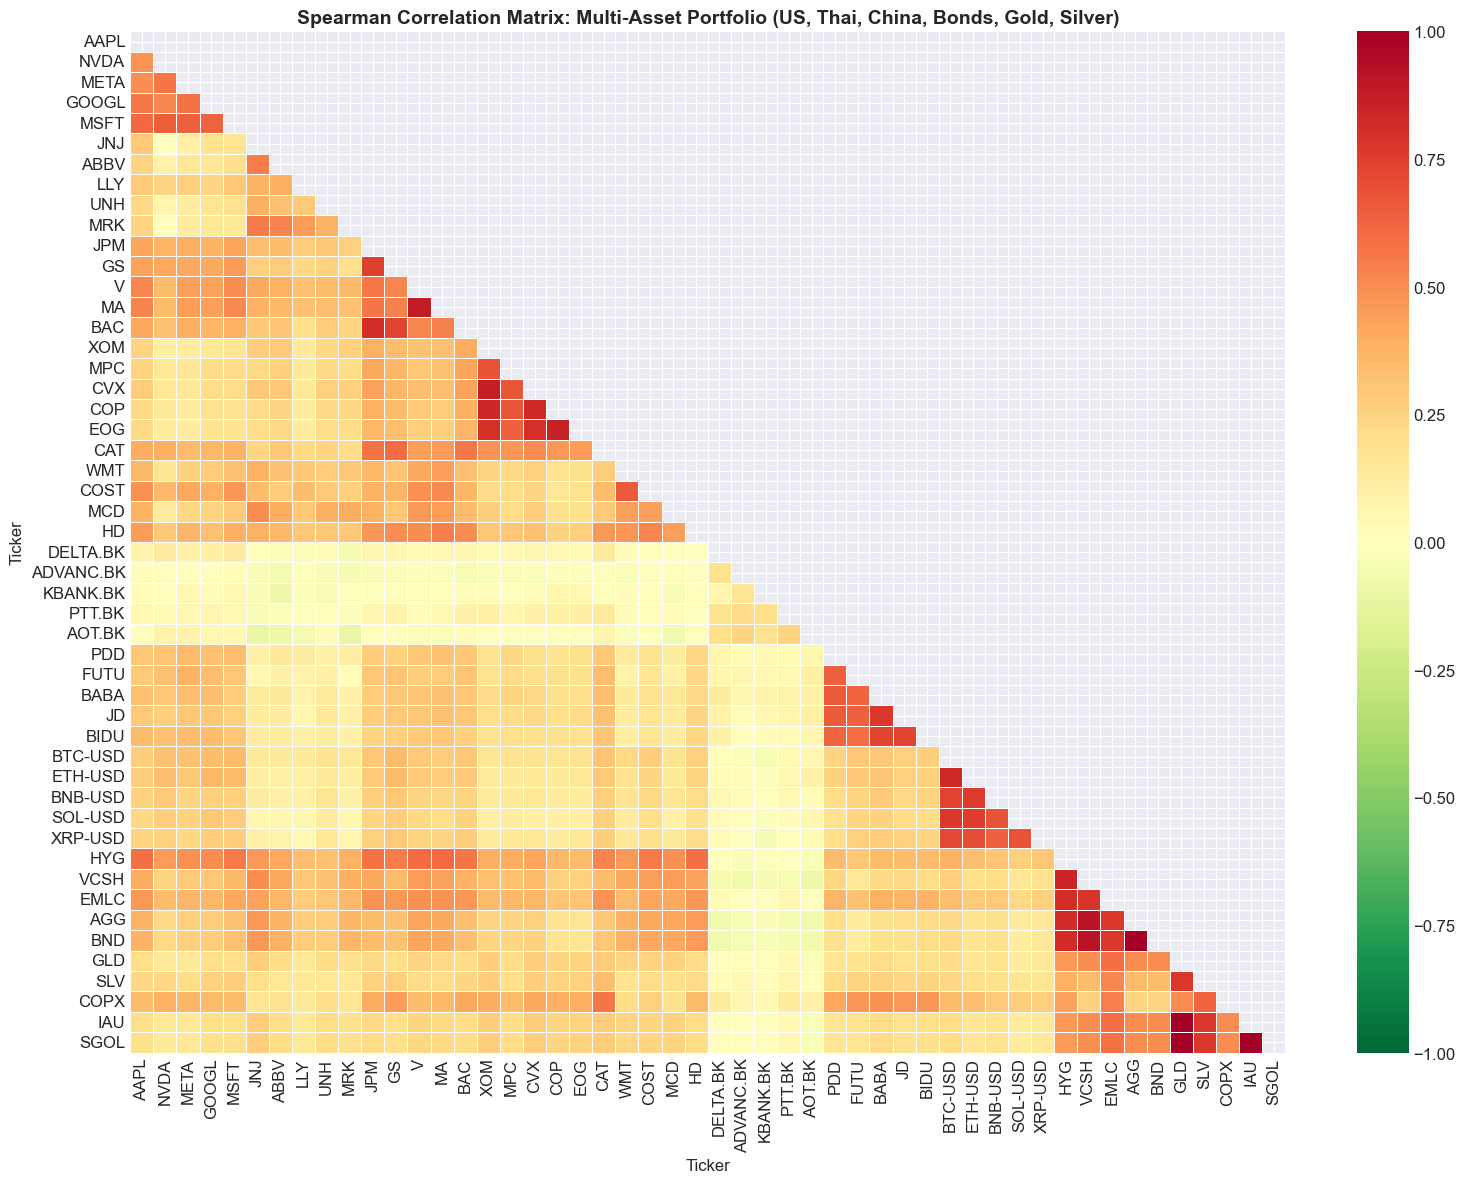

In [8]:
# Correlation Heatmap แผนภาพความสัมพันธ์ ดูทิศทางของราคาไปในทางเดียวกันหรือสวนทางกัน
ordered_tickers = [ticker for ticker in stock_sector_map.keys() if ticker in returns.columns]
fig, ax = plt.subplots(figsize=(16, 12))
corr_matrix = returns[ordered_tickers].corr(method='kendall')  # ใช้ Pearson correlation
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  
# สีแดง (ค่าเข้าใกล้ 1): หุ้นสองตัวนี้วิ่งไปในทิศทาง เดียวกัน อย่างรุนแรง
# สีเขียว (ค่าเข้าใกล้ -1): หุ้นสองตัวนี้วิ่ง สวนทางกัน ชัดเจน (ถ้า A ลง B จะขึ้น)
# สีเหลือง (ค่าใกล้ 0): ไม่มีความเกี่ยวข้องกันเลย วิ่งสะเปะสะปะตามใจตัวเอง
sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 7})
ax.set_title('Kendall Correlation Matrix: Multi-Asset Portfolio (US, Thai, China, Bonds, Gold, Silver)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# Correlation Heatmap แผนภาพความสัมพันธ์ ดูทิศทางของราคาไปในทางเดียวกันหรือสวนทางกัน
fig, ax = plt.subplots(figsize=(16, 12))
corr_matrix = returns[ordered_tickers].corr(method='pearson')  # ใช้ Pearson correlation
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  
# สีแดง (ค่าเข้าใกล้ 1): หุ้นสองตัวนี้วิ่งไปในทิศทาง เดียวกัน อย่างรุนแรง
# สีเขียว (ค่าเข้าใกล้ -1): หุ้นสองตัวนี้วิ่ง สวนทางกัน ชัดเจน (ถ้า A ลง B จะขึ้น)
# สีเหลือง (ค่าใกล้ 0): ไม่มีความเกี่ยวข้องกันเลย วิ่งสะเปะสะปะตามใจตัวเอง
sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 7})
ax.set_title('Pearson Correlation Matrix: Multi-Asset Portfolio (US, Thai, China, Bonds, Gold, Silver)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# Correlation Heatmap แผนภาพความสัมพันธ์ ดูทิศทางของราคาไปในทางเดียวกันหรือสวนทางกัน
fig, ax = plt.subplots(figsize=(16, 12))
corr_matrix = returns[ordered_tickers].corr(method='spearman')  # ใช้ Pearson correlation
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  
# สีแดง (ค่าเข้าใกล้ 1): หุ้นสองตัวนี้วิ่งไปในทิศทาง เดียวกัน อย่างรุนแรง
# สีเขียว (ค่าเข้าใกล้ -1): หุ้นสองตัวนี้วิ่ง สวนทางกัน ชัดเจน (ถ้า A ลง B จะขึ้น)
# สีเหลือง (ค่าใกล้ 0): ไม่มีความเกี่ยวข้องกันเลย วิ่งสะเปะสะปะตามใจตัวเอง
sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 7})
ax.set_title('Spearman Correlation Matrix: Multi-Asset Portfolio (US, Thai, China, Bonds, Gold, Silver)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


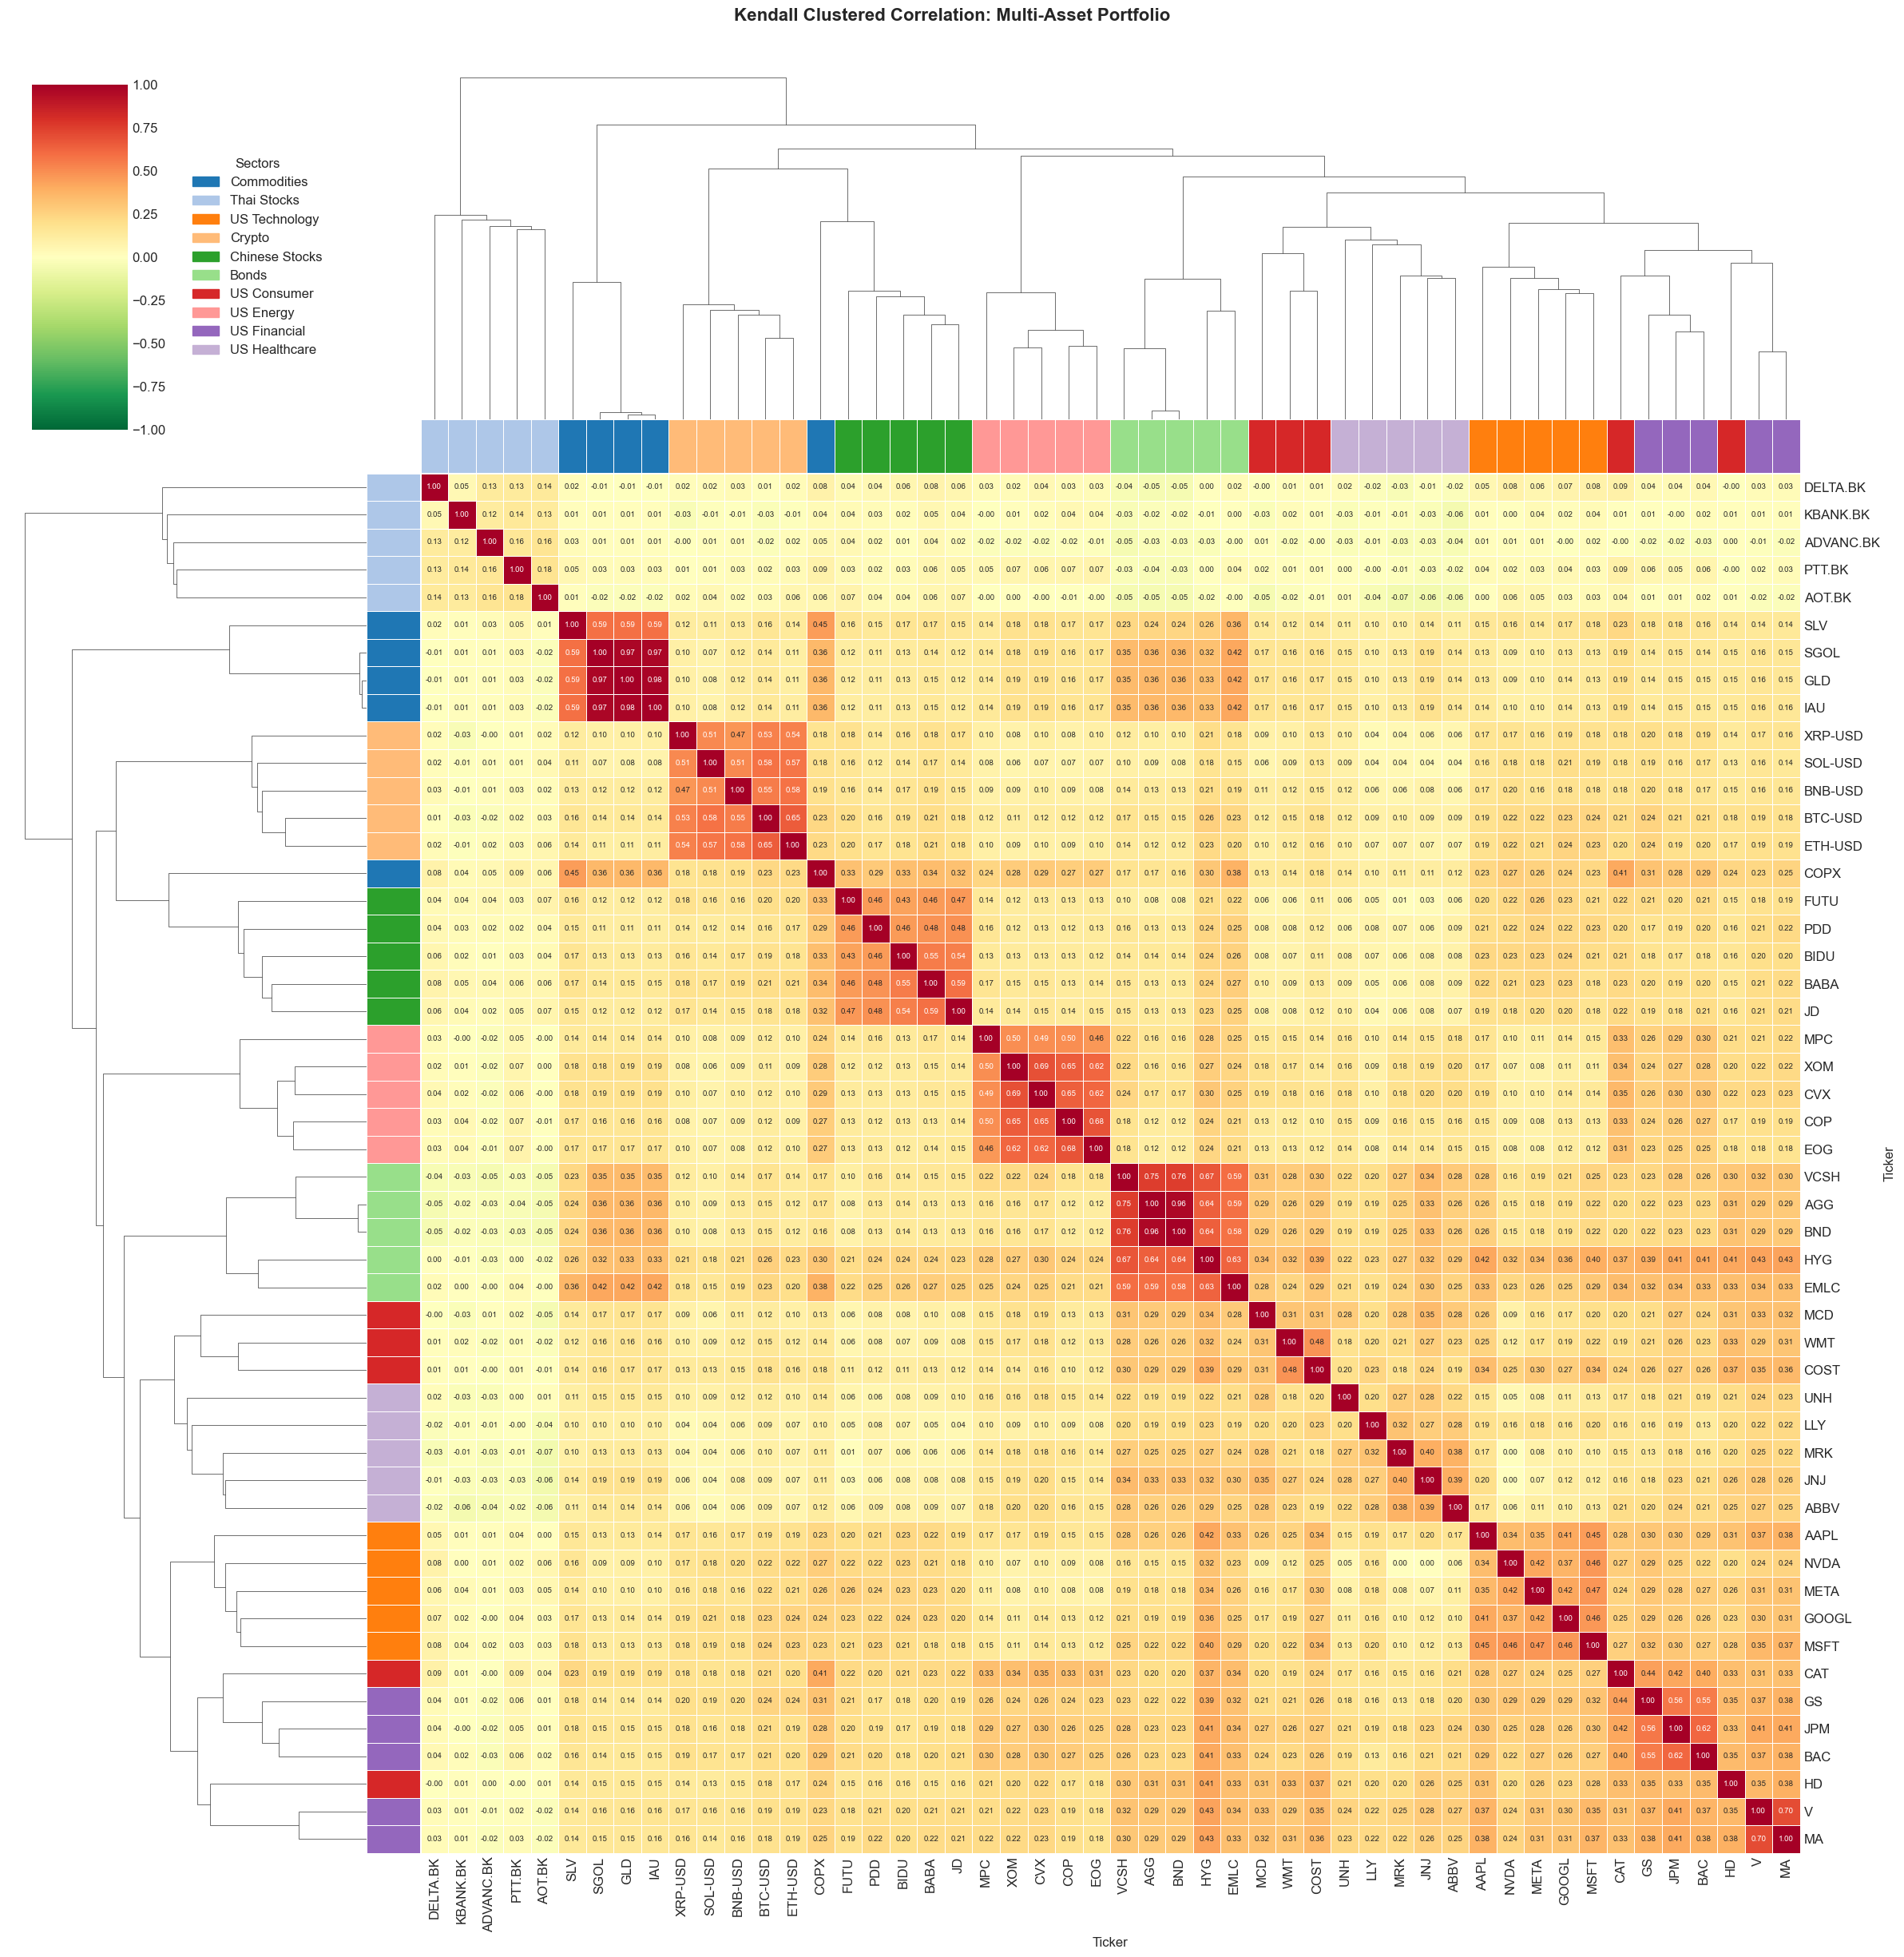

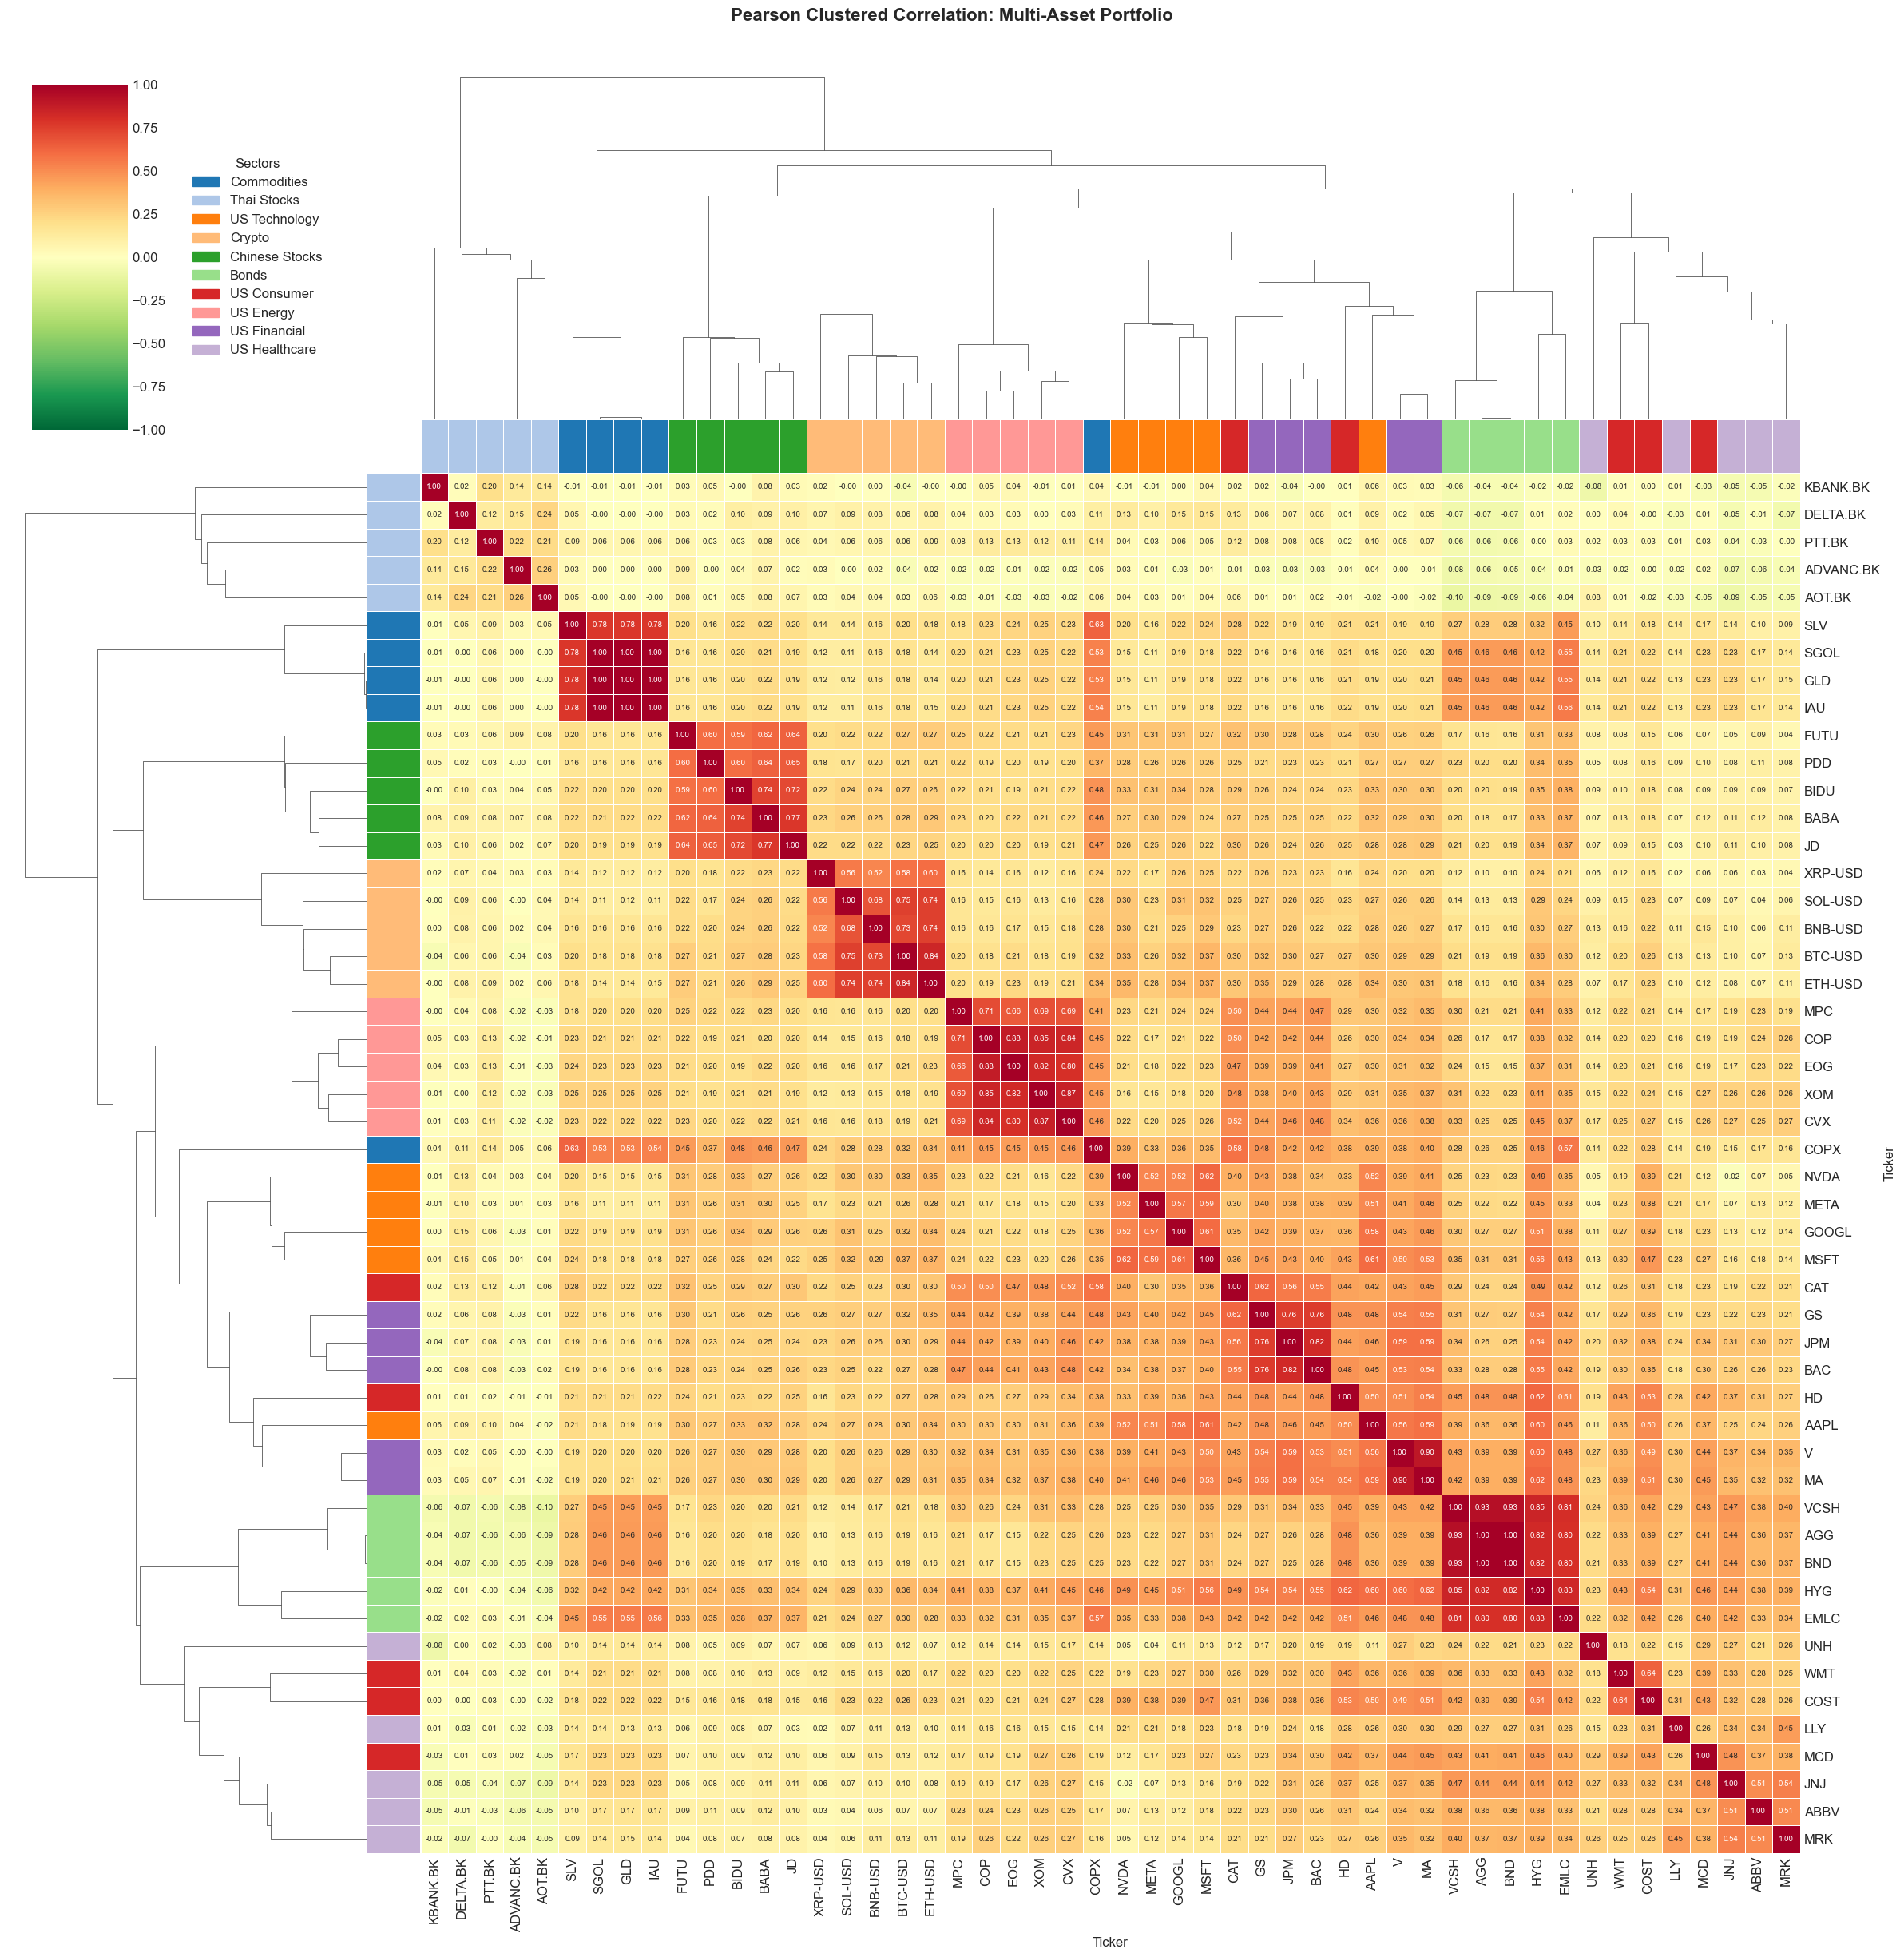

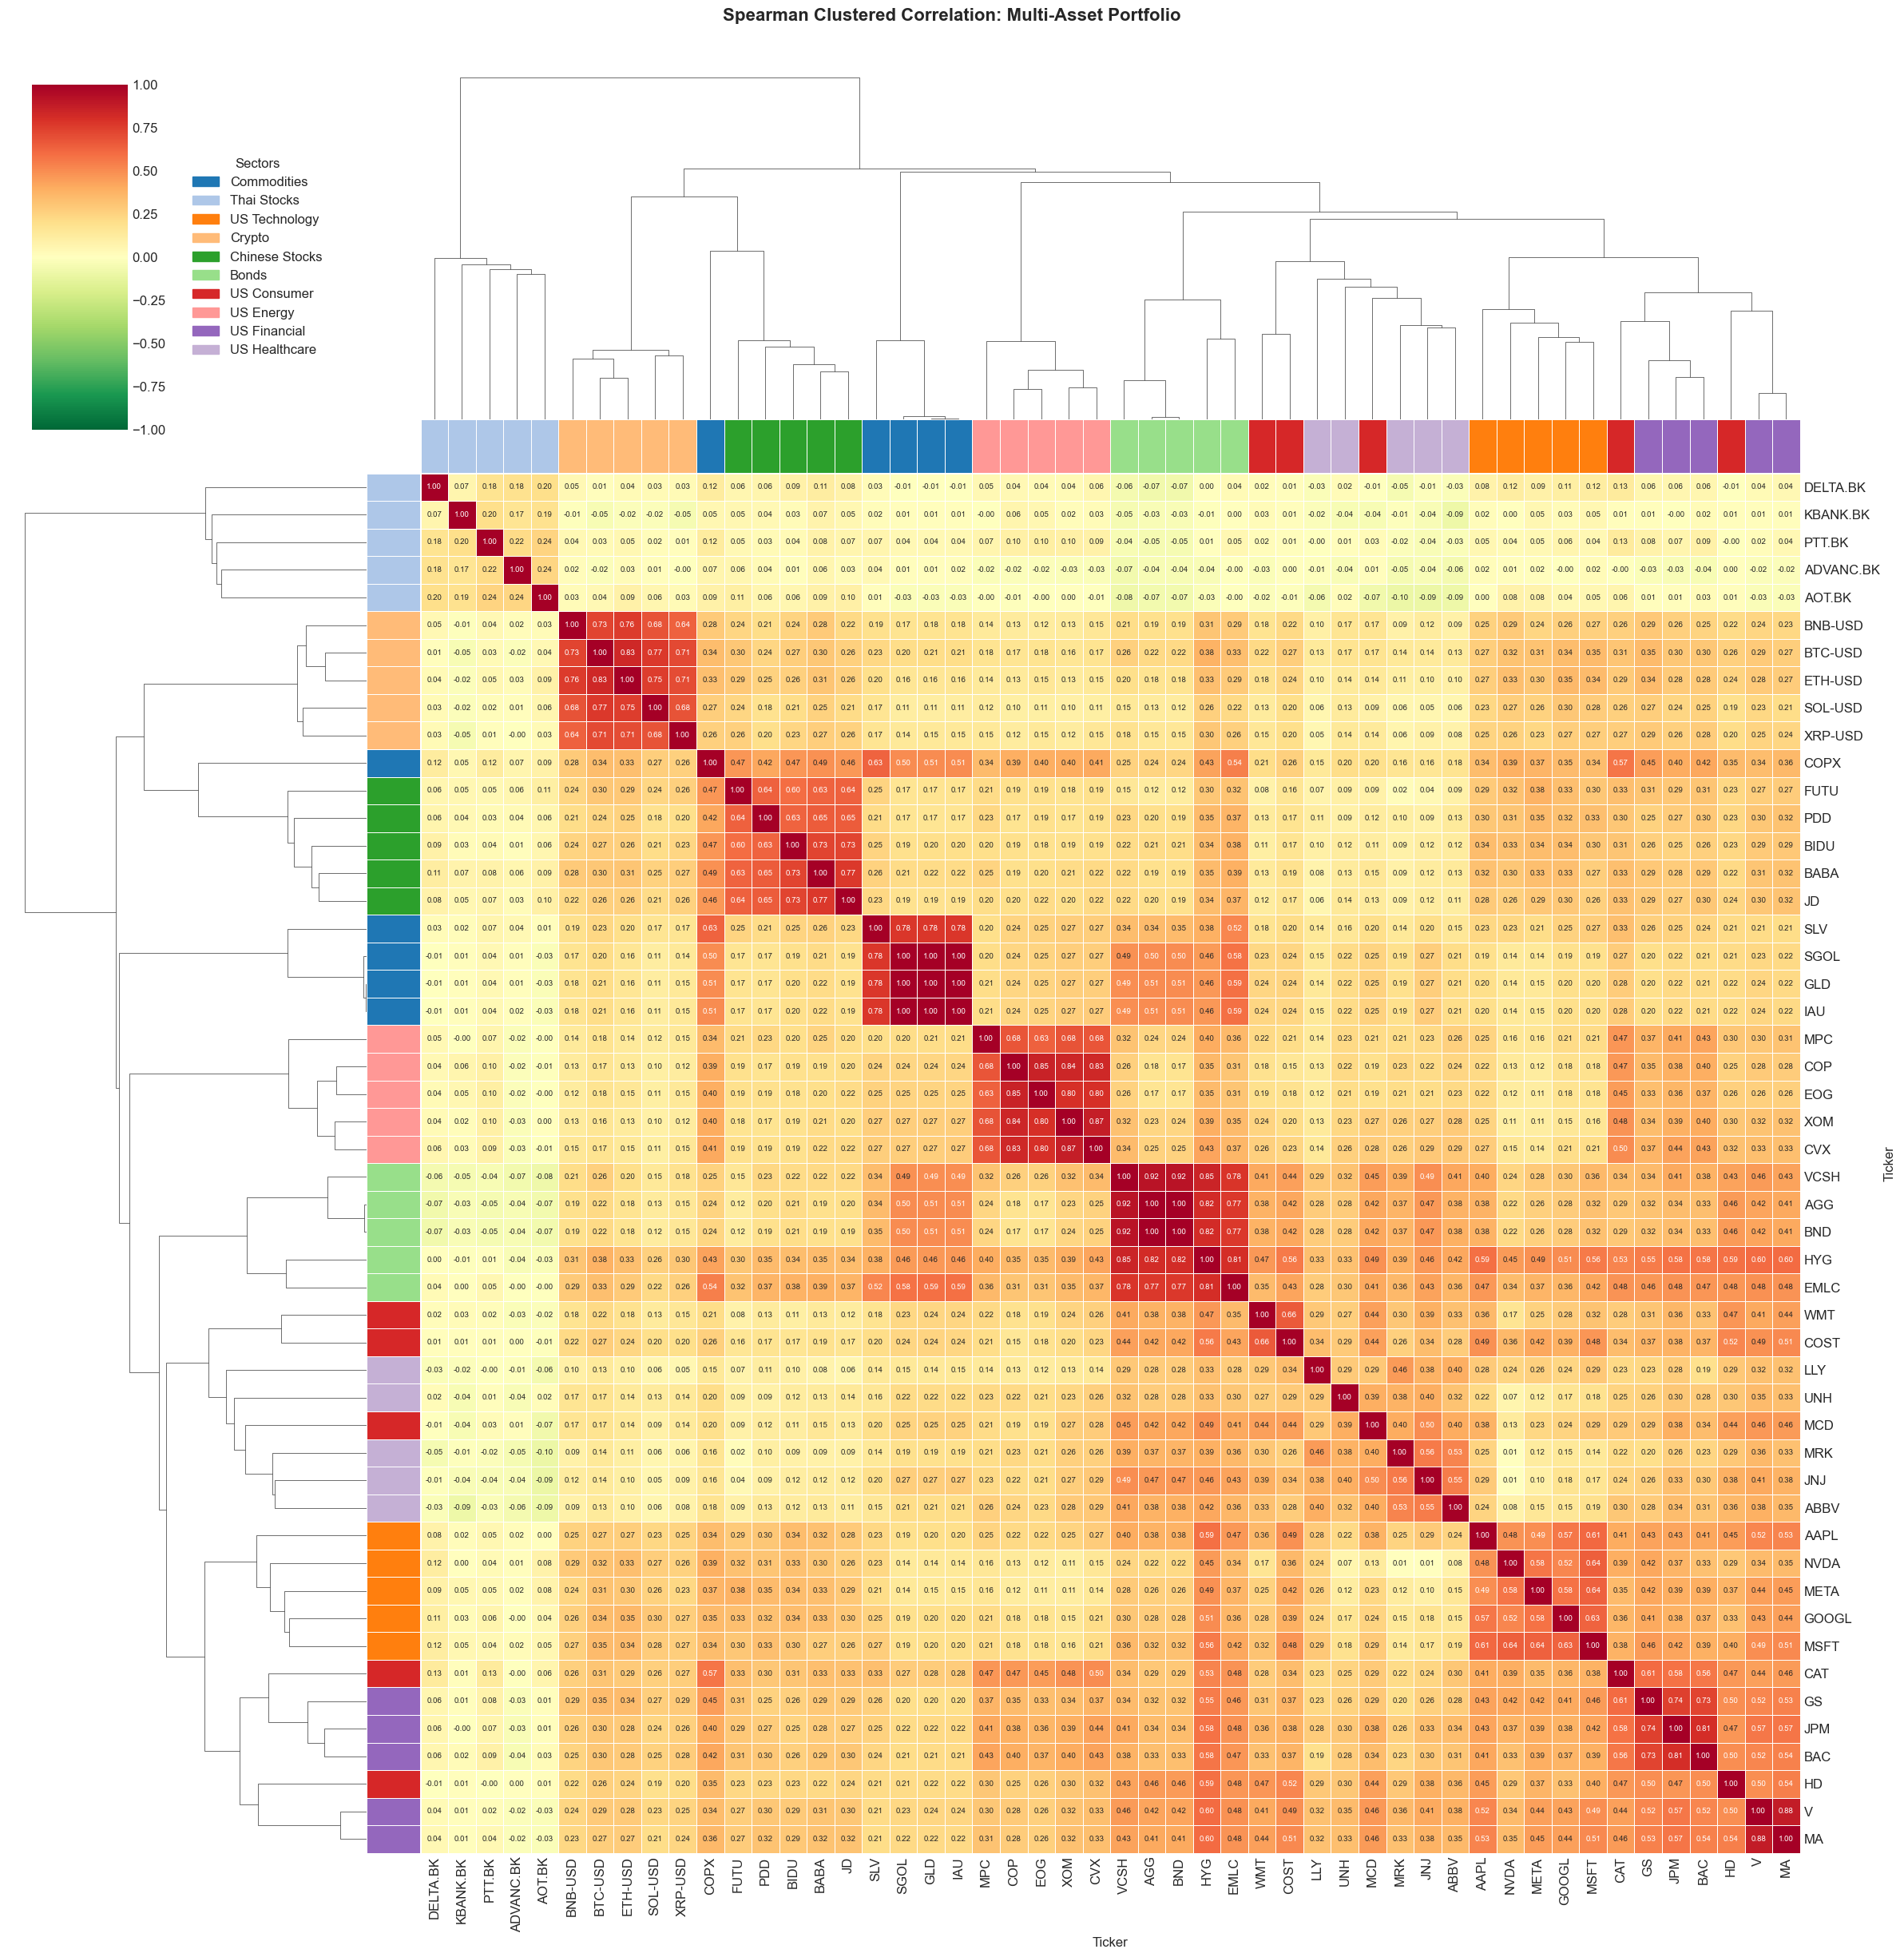

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==============================================================================
# Clustered Correlation Heatmap แผนภาพความสัมพันธ์แบบจัดกลุ่ม
# ดูทิศทางของราคาและจัดกลุ่มสินทรัพย์ที่มีพฤติกรรมคล้ายคลึงกันไว้ด้วยกัน
# ==============================================================================

ordered_tickers = [ticker for ticker in stock_sector_map.keys() if ticker in returns.columns]

# ---------------------------------------------------------
# ส่วนเพิ่มเติม: สร้างแถบสีตามกลุ่มอุตสาหกรรม (Sector)
# ---------------------------------------------------------
# 1. ดึงชื่อ Sector ทั้งหมดที่ไม่ซ้ำกัน
unique_sectors = list(set([stock_sector_map[t] for t in ordered_tickers]))

# 2. สร้างชุดสี (Palette) ให้แต่ละ Sector
color_palette = sns.color_palette("tab20", len(unique_sectors))
sector_color_dict = dict(zip(unique_sectors, color_palette))

# 3. สร้าง pandas Series ที่ระบุสีของแต่ละ Ticker สำหรับส่งให้ clustermap
ticker_colors = pd.Series({ticker: sector_color_dict[stock_sector_map[ticker]] for ticker in ordered_tickers})

# สีแดง (ค่าเข้าใกล้ 1): หุ้นสองตัวนี้วิ่งไปในทิศทางเดียวกันอย่างรุนแรง
# สีเขียว (ค่าเข้าใกล้ -1): หุ้นสองตัวนี้วิ่งสวนทางกันชัดเจน (ถ้า A ลง B จะขึ้น)
# สีเหลือง (ค่าใกล้ 0): ไม่มีความเกี่ยวข้องกันเลย วิ่งสะเปะสะปะตามใจตัวเอง

# ---------------------------------------------------------
# 1. Kendall Clustered Correlation Matrix
# ---------------------------------------------------------
corr_matrix_ken = returns[ordered_tickers].corr(method='kendall')

cg_ken = sns.clustermap(corr_matrix_ken, annot=True, fmt='.2f', cmap='RdYlGn_r',
                        center=0, linewidths=0.5, vmin=-1, vmax=1,
                        row_colors=ticker_colors, col_colors=ticker_colors, # เพิ่มแถบสีที่นี่
                        annot_kws={'size': 7}, figsize=(24, 24))
cg_ken.fig.suptitle('Kendall Clustered Correlation: Multi-Asset Portfolio', 
                    fontsize=16, fontweight='bold', y=1.02)
legend_patches = [mpatches.Patch(color=color, label=sector) 
                  for sector, color in sector_color_dict.items()]
plt.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1.55, 0.5), title='Sectors')
plt.show()

# ---------------------------------------------------------
# 2. Pearson Clustered Correlation Matrix
# ---------------------------------------------------------
corr_matrix_pear = returns[ordered_tickers].corr(method='pearson')

cg_pear = sns.clustermap(corr_matrix_pear, annot=True, fmt='.2f', cmap='RdYlGn_r',
                         center=0, linewidths=0.5, vmin=-1, vmax=1,
                         row_colors=ticker_colors, col_colors=ticker_colors, # เพิ่มแถบสีที่นี่
                         annot_kws={'size': 7}, figsize=(24, 24))
cg_pear.fig.suptitle('Pearson Clustered Correlation: Multi-Asset Portfolio', 
                     fontsize=16, fontweight='bold', y=1.02)
plt.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1.55, 0.5), title='Sectors')
plt.show()

# ---------------------------------------------------------
# 3. Spearman Clustered Correlation Matrix
# ---------------------------------------------------------
corr_matrix_spear = returns[ordered_tickers].corr(method='spearman')

cg_spear = sns.clustermap(corr_matrix_spear, annot=True, fmt='.2f', cmap='RdYlGn_r',
                          center=0, linewidths=0.5, vmin=-1, vmax=1,
                          row_colors=ticker_colors, col_colors=ticker_colors, # เพิ่มแถบสีที่นี่
                          annot_kws={'size': 7}, figsize=(24, 24))
cg_spear.fig.suptitle('Spearman Clustered Correlation: Multi-Asset Portfolio', 
                      fontsize=16, fontweight='bold', y=1.02)
plt.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1.55, 0.5), title='Sectors')
plt.show()

# ---------------------------------------------------------
# Optional: สร้าง Legend (คำอธิบายสัญลักษณ์) สำหรับ Sector Colors
# นำไปรันต่อจากรูปใดรูปหนึ่งได้ เพื่อให้รู้ว่าสีไหนคือหมวดหมู่ไหน
# ---------------------------------------------------------


## 5. Mean-Variance (M-V) Model — ทฤษฎี Markowitz (1952)

### ตัวแปรหลัก:
- **Mean (μ)**: ผลตอบแทนที่คาดหวัง — คำนวณจากค่าเฉลี่ยผลตอบแทนในอดีต
- **Variance (σ²)**: ความเสี่ยง — วัดการกระจายตัวของผลตอบแทน

### 2 เป้าหมายของ M-V Model:
1. **Maximize Return** ณ ระดับความเสี่ยงที่ยอมรับได้
2. **Minimize Risk** ณ ระดับผลตอบแทนที่ต้องการ


In [10]:
# =============================================
# Mean-Variance (M-V) Model — Markowitz (1952)
# =============================================
# การลงทุนที่ดีที่สุด ไม่ใช่การเลือกหุ้นที่กำไรมากที่สุด แต่คือการหาสัดส่วนพอร์ตที่ให้ "ผลตอบแทนคุ้มค่าความเสี่ยงที่สุด"

# --- 1) Mean: Expected Return Vector (mu) ---
mu = returns.mean() * 252  # ผลตอบแทนเฉลี่ยต่อปี
print("=" * 60)
print("Mean-Variance Model Components")
print("=" * 60)
print()
print("1) Expected Return Vector (mu) - Annualized:")
print("-" * 40)
for ticker, ret in mu.sort_values(ascending=False).items():
    bar = "#" * int(max(ret * 100, 0) / 3)
    print(f"  {ticker:10s} {ret*100:>8.2f}%  {bar}")

# --- 2) Covariance Matrix (Sigma) ---
cov = returns.cov() * 252  # ความเสี่ยง
print()
print("2) Covariance Matrix (Sigma) - shape:", cov.shape)
print("-" * 40)
print("  Diagonal = Variance of each asset:")
for ticker in mu.sort_values(ascending=False).index:
    var_val = cov.loc[ticker, ticker]
    vol_val = np.sqrt(var_val) * 100
    print(f"    {ticker:10s}  Var={var_val:.4f}  Vol={vol_val:.1f}%")

# --- 3) Portfolio Formulas ---
print()
print("3) M-V Model Formulas:")
print("-" * 40)
print("  Portfolio Return:  E(Rp) = sum(wi * mui)") #  (ผลตอบแทนพอร์ต): เอา (สัดส่วนน้ำหนักหุ้น A * ผลตอบแทนหุ้น A) + (สัดส่วนหุ้น B * ผลตอบแทน B) ... 
print("  Portfolio Risk:    Vp    = w.T @ Sigma @ w") # (ความต้านทานความเสี่ยง ): (น้ำหนักพอร์ตแบบ Transpose แนวนอน) คูณเมทริกซ์ (ตาราง Sigma) คูณ (น้ำหนักแนวดิ่ง)
print("  Sharpe Ratio:      SR    = E(Rp) / sqrt(Vp)") # ผลเฉลี่ยพอร์ต หาร สแควรูทของความเสี่ยง

# --- 4) Equal-Weight Portfolio Example --- จำลองพอร์ตแบบ "น้ำหนักเท่ากันทุกตัว" (Equal-Weight)
n = len(mu)
w_eq = np.array([1/n] * n)
port_ret = np.dot(w_eq, mu)
port_var = np.dot(w_eq.T, np.dot(cov, w_eq))
port_vol = np.sqrt(port_var)
port_sr = port_ret / port_vol

print()
print("4) Example: Equal-Weight Portfolio (w = 1/N):")
print("-" * 40)
print(f"  E(Rp) = sum(wi * mui)      = {port_ret*100:.2f}%")
print(f"  Vp    = w.T @ Sigma @ w    = {port_var:.6f}") # ความแปรปรวน/ความเสี่ยงของพอร์ต
print(f"  Vol   = sqrt(Vp)           = {port_vol*100:.2f}%") # ความผันผวนของพอร์ตคาดการณ์ต่อปี
print(f"  Sharpe = E(Rp) / Vol       = {port_sr:.3f}") # อัตราส่วนผลตอบแทนเทียบกับความเสี่ยง

# --- 5) Optimization with Constraints ---
print()


Mean-Variance Model Components

1) Expected Return Vector (mu) - Annualized:
----------------------------------------
  DELTA.BK      71.22%  #######################
  NVDA          64.00%  #####################
  FUTU          59.00%  ###################
  XRP-USD       51.61%  #################
  SOL-USD       44.33%  ##############
  PDD           39.91%  #############
  CAT           38.06%  ############
  LLY           37.51%  ############
  META          37.32%  ############
  MPC           36.61%  ############
  SLV           34.61%  ###########
  GS            31.27%  ##########
  WMT           28.39%  #########
  BNB-USD       28.31%  #########
  GOOGL         25.98%  ########
  BTC-USD       25.75%  ########
  JPM           25.54%  ########
  XOM           25.17%  ########
  SGOL          23.77%  #######
  IAU           23.69%  #######
  GLD           23.55%  #######
  COPX          22.38%  #######
  ADVANC.BK     20.13%  ######
  COST          18.55%  ######
  BABA          

หัวใจ M-V Model: ทำไม Correlation สำคัญ?

[ Top 30 High Correlation (เสี่ยงกระจุก เคลื่อนไหวตามกัน) ]
  GLD        vs IAU         corr = +1.000
  GLD        vs SGOL        corr = +0.999
  IAU        vs SGOL        corr = +0.999
  AGG        vs BND         corr = +0.999
  BND        vs VCSH        corr = +0.932
  AGG        vs VCSH        corr = +0.930
  MA         vs V           corr = +0.899
  COP        vs EOG         corr = +0.878
  CVX        vs XOM         corr = +0.867
  COP        vs XOM         corr = +0.850
  HYG        vs VCSH        corr = +0.847
  BTC-USD    vs ETH-USD     corr = +0.843
  COP        vs CVX         corr = +0.837
  EMLC       vs HYG         corr = +0.829
  BND        vs HYG         corr = +0.824
  AGG        vs HYG         corr = +0.824
  EOG        vs XOM         corr = +0.824
  BAC        vs JPM         corr = +0.824
  EMLC       vs VCSH        corr = +0.806
  AGG        vs EMLC        corr = +0.805
  BND        vs EMLC        corr = +0.803
  CVX        vs 

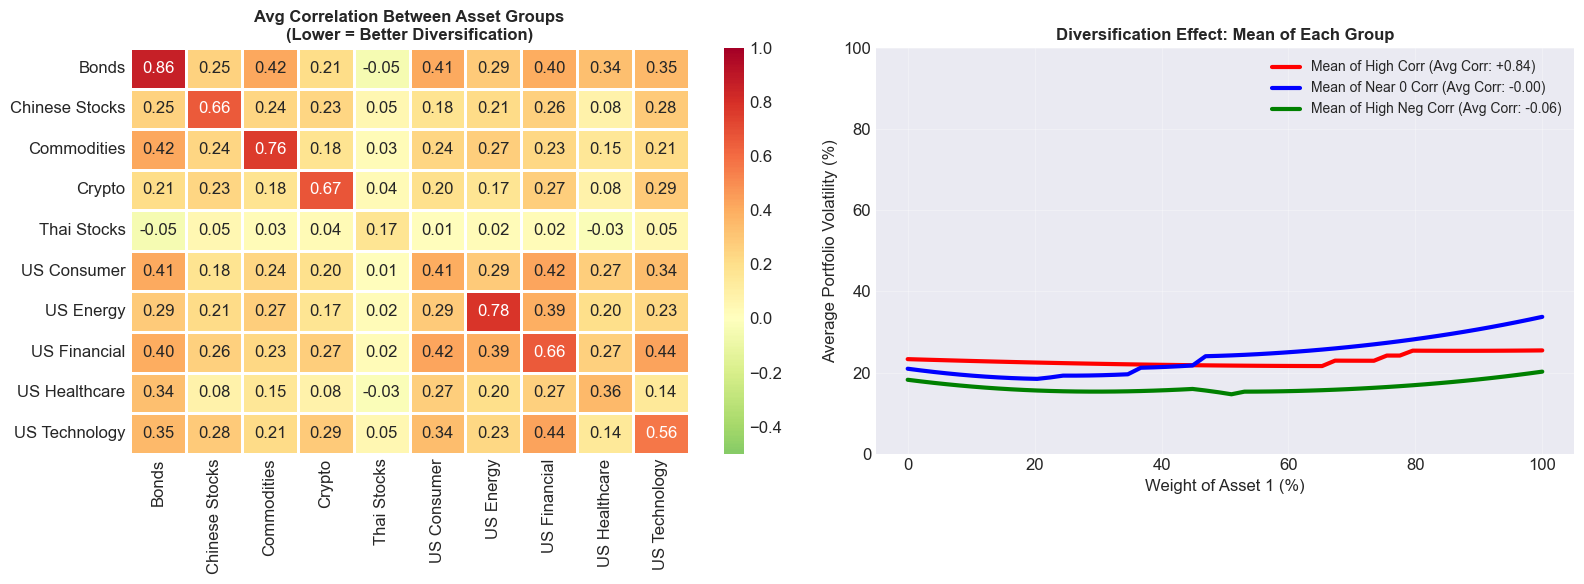

In [11]:
# ==========================================================
# หัวใจ M-V Model: Correlation/Covariance ระหว่างAsset
# ==========================================================
# ไม่ใช่แค่เลือกหุ้นกำไรดี แต่คือการดู "ความสัมพันธ์" ระหว่างAsset
# - หากลงหุ้นที่ขึ้นลงพร้อมกัน -> พอร์ตเสี่ยงสูง
# - หากเลือกAssetที่ "ไม่ไปด้วยกัน" -> พอร์ตเสี่ยงน้อยลง ผลตอบแทนเท่าเดิม
# ==========================================================

mu = returns.mean() * 252
cov = returns.cov() * 252
corr = returns.corr()

# --- 1) แสดงตัวอย่าง Correlation ตามกลุ่มต่างๆ ---
print("=" * 65)
print("หัวใจ M-V Model: ทำไม Correlation สำคัญ?")
print("=" * 65)

# สร้างลิสต์เก็บค่า Correlation แบบจับคู่
corr_pairs = []
tickers_list = list(corr.columns)
for i in range(len(tickers_list)):
    for j in range(i+1, len(tickers_list)):
        corr_pairs.append((tickers_list[i], tickers_list[j], corr.iloc[i,j]))

# แยกกลุ่ม 30 อันดับตามเงื่อนไขที่กำหนด
# 1. High Correlation (บวกสูงสุด)
high_corr_pairs = sorted(corr_pairs, key=lambda x: x[2], reverse=True)[:30]

# 2. Near 0 Correlation (ค่าสัมบูรณ์ใกล้ 0 ที่สุด)
near_zero_pairs = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=False)[:30]

# 3. High Negative Correlation (ติดลบต่ำสุด หรือสวนทางกันมากสุด)
high_neg_corr_pairs = sorted(corr_pairs, key=lambda x: x[2], reverse=False)[:30]

print("\n[ Top 30 High Correlation (เสี่ยงกระจุก เคลื่อนไหวตามกัน) ]")
for a, b, c in high_corr_pairs:
    print(f"  {a:10s} vs {b:10s}  corr = {c:+.3f}")

print("\n[ Top 30 Near 0 Correlation (ไม่สัมพันธ์กัน ต่างคนต่างไป) ]")
for a, b, c in near_zero_pairs:
    print(f"  {a:10s} vs {b:10s}  corr = {c:+.3f}")

print("\n[ Top 30 High Negative Correlation (สวนทางกัน ลดความเสี่ยงได้ดีที่สุด) ]")
for a, b, c in high_neg_corr_pairs:
    print(f"  {a:10s} vs {b:10s}  corr = {c:+.3f}")


# --- 2) พิสูจน์ด้วยตัวเลข: 2-asset portfolio ---
print()
print("=" * 65)
print("พิสูจน์: เปรียบเทียบ 2-asset portfolio")
print("=" * 65)

# ดึงคู่ที่ Correlation สูงสุด และ ติดลบมากสุด(หรือใกล้ 0 มากสุด) มาเปรียบเทียบ
high_a, high_b, high_c = high_corr_pairs[0]
low_a, low_b, low_c = high_neg_corr_pairs[0]  # ใช้คู่ที่ Negative มากสุดเพื่อให้เห็นผลชัดเจน

def two_asset_portfolio(t1, t2, w1=0.5):
    w2 = 1 - w1
    ret = w1 * mu[t1] + w2 * mu[t2]
    var = (w1**2 * cov.loc[t1,t1] + w2**2 * cov.loc[t2,t2]
           + 2 * w1 * w2 * cov.loc[t1,t2])
    vol = np.sqrt(var)
    avg_vol = w1 * np.sqrt(cov.loc[t1,t1]) + w2 * np.sqrt(cov.loc[t2,t2])
    diversification = (1 - vol/avg_vol) * 100
    return ret, vol, avg_vol, diversification

ret_h, vol_h, avg_vol_h, div_h = two_asset_portfolio(high_a, high_b)
ret_l, vol_l, avg_vol_l, div_l = two_asset_portfolio(low_a, low_b)

print(f"\nCase 1: HIGH Corr ({high_a} + {high_b}, corr={high_c:+.3f})")
print(f"  Average Vol (ไม่มี diversification) = {avg_vol_h*100:.2f}%")
print(f"  Portfolio Vol (50/50)               = {vol_h*100:.2f}%")
print(f"  Diversification Benefit             = {div_h:.1f}%  <-- น้อย!")

print(f"\nCase 2: LOW/NEGATIVE Corr ({low_a} + {low_b}, corr={low_c:+.3f})")
print(f"  Average Vol (ไม่มี diversification) = {avg_vol_l*100:.2f}%")
print(f"  Portfolio Vol (50/50)               = {vol_l*100:.2f}%")
print(f"  Diversification Benefit             = {div_l:.1f}%  <-- สูงกว่ามาก!")

print(f"\n>> สรุป: Corr ต่ำ/ติดลบ -> ลดความเสี่ยงได้ {div_l:.1f}% vs Corr สูง -> ลดได้แค่ {div_h:.1f}%")

# --- 3) Visualization ---
# --- 2) พิสูจน์ด้วยตัวเลข: 2-asset portfolio (3 Scenarios) ---
print()
print("=" * 65)
print("พิสูจน์: เปรียบเทียบ 2-asset portfolio (3 กรณี)")
print("=" * 65)

# ดึงตัวแทนอันดับ 1 จากทั้ง 3 กลุ่มมาเปรียบเทียบ
high_a, high_b, high_c = high_corr_pairs[0]
zero_a, zero_b, zero_c = near_zero_pairs[0]
neg_a, neg_b, neg_c = high_neg_corr_pairs[0]

def two_asset_portfolio(t1, t2, w1=0.5):
    w2 = 1 - w1
    ret = w1 * mu[t1] + w2 * mu[t2]
    var = (w1**2 * cov.loc[t1,t1] + w2**2 * cov.loc[t2,t2]
           + 2 * w1 * w2 * cov.loc[t1,t2])
    vol = np.sqrt(var)
    avg_vol = w1 * np.sqrt(cov.loc[t1,t1]) + w2 * np.sqrt(cov.loc[t2,t2])
    diversification = (1 - vol/avg_vol) * 100
    return ret, vol, avg_vol, diversification

ret_h, vol_h, avg_vol_h, div_h = two_asset_portfolio(high_a, high_b)
ret_z, vol_z, avg_vol_z, div_z = two_asset_portfolio(zero_a, zero_b)
ret_n, vol_n, avg_vol_n, div_n = two_asset_portfolio(neg_a, neg_b)

print(f"\nCase 1: HIGH Corr ({high_a} + {high_b}, corr={high_c:+.3f})")
print(f"  Average Vol (ไม่มี diversification) = {avg_vol_h*100:.2f}%")
print(f"  Portfolio Vol (50/50)               = {vol_h*100:.2f}%")
print(f"  Diversification Benefit             = {div_h:.1f}%  <-- แทบไม่ช่วยลดความเสี่ยง")

print(f"\nCase 2: NEAR 0 Corr ({zero_a} + {zero_b}, corr={zero_c:+.3f})")
print(f"  Average Vol (ไม่มี diversification) = {avg_vol_z*100:.2f}%")
print(f"  Portfolio Vol (50/50)               = {vol_z*100:.2f}%")
print(f"  Diversification Benefit             = {div_z:.1f}%  <-- ลดความเสี่ยงได้ปานกลาง")

print(f"\nCase 3: HIGH NEGATIVE Corr ({neg_a} + {neg_b}, corr={neg_c:+.3f})")
print(f"  Average Vol (ไม่มี diversification) = {avg_vol_n*100:.2f}%")
print(f"  Portfolio Vol (50/50)               = {vol_n*100:.2f}%")
print(f"  Diversification Benefit             = {div_n:.1f}%  <-- ลดความเสี่ยงได้ดีที่สุด!")

# --- 3) Visualization ---
# --- 3) Visualization (แสดงเส้นค่าเฉลี่ยของแต่ละกลุ่ม) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap: Asset Class avg correlation
sector_list = sorted(set(stock_sector_map.values()))
sector_corr = pd.DataFrame(index=sector_list, columns=sector_list, dtype=float)
for s1 in sector_list:
    t1s = [t for t in corr.columns if stock_sector_map.get(t) == s1]
    for s2 in sector_list:
        t2s = [t for t in corr.columns if stock_sector_map.get(t) == s2]
        vals = [corr.loc[a,b] for a in t1s for b in t2s if a != b]
        sector_corr.loc[s1, s2] = np.mean(vals) if vals else (1.0 if s1==s2 else 0.0)

sns.heatmap(sector_corr.astype(float), annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, vmin=-0.5, vmax=1, ax=axes[0], linewidths=1)
axes[0].set_title("Avg Correlation Between Asset Groups\n(Lower = Better Diversification)", fontsize=12, fontweight="bold")


# --- สร้างฟังก์ชันคำนวณเส้นค่าเฉลี่ยความเสี่ยง (Mean Volatility Curve) ---
# --- สร้างฟังก์ชันคำนวณเส้นค่าเฉลี่ยความเสี่ยง (Mean Volatility Curve) แบบจัดการ Outlier ---
weights_range = np.linspace(0, 1, 50)

def get_mean_vol_curve(pair_list, weights):
    mean_vols = []
    for w in weights:
        vols_at_w = []
        for a, b, c in pair_list:
            _, vol, _, _ = two_asset_portfolio(a, b, w)
            vols_at_w.append(vol * 100)
        
        # --- ขั้นตอนการจัดการ Outlier ด้วยวิธี IQR ---
        q1 = np.percentile(vols_at_w, 25)
        q3 = np.percentile(vols_at_w, 75)
        iqr = q3 - q1
        
        # กำหนดขอบเขตล่างและบน (Lower & Upper Bounds)
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        # กรองเฉพาะค่าความเสี่ยงที่อยู่ในเกณฑ์ปกติ (ไม่เป็น Outlier)
        filtered_vols = [v for v in vols_at_w if lower_bound <= v <= upper_bound]
        
        # ในกรณีที่ถูกตัดออกจนหมด (ซึ่งเกิดได้ยากมาก) ให้ใช้ค่าเฉลี่ยเดิมกัน Error
        if len(filtered_vols) == 0:
            filtered_vols = vols_at_w
            
        # หาค่าเฉลี่ยจากข้อมูลที่ผ่านการกรอง Outlier แล้ว
        mean_vols.append(np.mean(filtered_vols)) 
        
    return mean_vols

# คำนวณเส้นค่าเฉลี่ยของทั้ง 3 กลุ่ม (เรียกใช้ฟังก์ชันที่อัปเดตแล้ว)
mean_vols_high = get_mean_vol_curve(high_corr_pairs, weights_range)
mean_vols_zero = get_mean_vol_curve(near_zero_pairs, weights_range)
mean_vols_neg  = get_mean_vol_curve(high_neg_corr_pairs, weights_range)


# Line chart: Diversification Effect (พลอตกราฟค่าเฉลี่ย 3 เส้น)
axes[1].plot(weights_range*100, mean_vols_high, "r-", linewidth=3, 
             label=f"Mean of High Corr (Avg Corr: {np.mean([x[2] for x in high_corr_pairs]):+.2f})")
axes[1].plot(weights_range*100, mean_vols_zero, "b-", linewidth=3, 
             label=f"Mean of Near 0 Corr (Avg Corr: {np.mean([x[2] for x in near_zero_pairs]):+.2f})")
axes[1].plot(weights_range*100, mean_vols_neg, "g-", linewidth=3, 
             label=f"Mean of High Neg Corr (Avg Corr: {np.mean([x[2] for x in high_neg_corr_pairs]):+.2f})")

axes[1].set_xlabel("Weight of Asset 1 (%)", fontsize=12)  
axes[1].set_ylabel("Average Portfolio Volatility (%)", fontsize=12) 
axes[1].set_title("Diversification Effect: Mean of Each Group", fontsize=12, fontweight="bold")

axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.ylim(0,100)
plt.tight_layout()
plt.show()


## 6. กำหนด Sector Weight Limits (ข้อจำกัดน้ำหนัก)

### กฎ:
- **น้ำหนักสูงสุดต่อกลุ่ม**: ไม่เกิน 25%
- **น้ำหนักต่ำสุดต่อกลุ่ม**: อย่างน้อย 2%
- **น้ำหนักสูงสุดต่อตัว**: ไม่เกิน 15%
- **น้ำหนักต่ำสุดต่อตัว**: อย่างน้อย 1%


In [17]:
# === Sector Weight Constraints Configuration ===

# น้ำหนักรวมของแต่ละกลุ่ม
SECTOR_MAX_WEIGHT = 0.25   # สูงสุด 25% ต่อกลุ่ม
SECTOR_MIN_WEIGHT = 0.05   # ต่ำสุด 2% ต่อกลุ่ม

# น้ำหนักของAssetแต่ละตัว
STOCK_MAX_WEIGHT = 0.15    # สูงสุด 15% ต่อตัว
STOCK_MIN_WEIGHT = 0.01    # ต่ำสุด 1% ต่อตัว

print("=" * 55)
print("📋 Sector / Asset Class Weight Constraints")
print("=" * 55)
print(f"  Sector Max Weight : {SECTOR_MAX_WEIGHT*100:.0f}%")
print(f"  Sector Min Weight : {SECTOR_MIN_WEIGHT*100:.0f}%")
print(f"  Stock Max Weight  : {STOCK_MAX_WEIGHT*100:.0f}%")
print(f"  Stock Min Weight  : {STOCK_MIN_WEIGHT*100:.0f}%")
print()

# สร้าง Sector mapping
unique_sectors = sorted(set(stock_sector_map.values()))
stock_list = list(returns.columns)
n_stocks = len(stock_list)

# สร้าง sector index mapping
sector_stock_indices = {}
for sector in unique_sectors:
    indices = [i for i, s in enumerate(stock_list) if stock_sector_map[s] == sector]
    sector_stock_indices[sector] = indices
    print(f"  {sector:20s}: {[stock_list[i] for i in indices]}")


📋 Sector / Asset Class Weight Constraints
  Sector Max Weight : 25%
  Sector Min Weight : 5%
  Stock Max Weight  : 15%
  Stock Min Weight  : 1%

  Bonds               : ['AGG', 'BND', 'EMLC', 'HYG', 'VCSH']
  Chinese Stocks      : ['BABA', 'BIDU', 'FUTU', 'JD', 'PDD']
  Commodities         : ['COPX', 'GLD', 'IAU', 'SGOL', 'SLV']
  Crypto              : ['BNB-USD', 'BTC-USD', 'ETH-USD', 'SOL-USD', 'XRP-USD']
  Thai Stocks         : ['ADVANC.BK', 'AOT.BK', 'DELTA.BK', 'KBANK.BK', 'PTT.BK']
  US Consumer         : ['CAT', 'COST', 'HD', 'MCD', 'WMT']
  US Energy           : ['COP', 'CVX', 'EOG', 'MPC', 'XOM']
  US Financial        : ['BAC', 'GS', 'JPM', 'MA', 'V']
  US Healthcare       : ['ABBV', 'JNJ', 'LLY', 'MRK', 'UNH']
  US Technology       : ['AAPL', 'GOOGL', 'META', 'MSFT', 'NVDA']


In [18]:
# ==========================================================
# Risk-Free Rate (Rf) for Sharpe Ratio
# ==========================================================
# Sharpe Ratio = (E(Rp) - Rf) / sigma_p
# Using US 10-Year Treasury Rate as proxy

import yfinance as yf

try:
    # Download US 10Y Treasury yield
    tnx = yf.download("^TNX", period="5d", auto_adjust=True)["Close"]
    RISK_FREE_RATE = float(tnx['^TNX'].iloc[-1]) / 100  # convert from % to decimal
except:
    RISK_FREE_RATE = 0.045  # fallback: 4.5%

print("=" * 60)
print("Risk-Free Rate Configuration")
print("=" * 60)
print(f"  Rf (annual) = {RISK_FREE_RATE*100:.2f}%  (US 10Y Treasury)")  # ดอกเบี้ยแบบรายปี -> พันธบัตรรัฐบาลสหรัฐอเมริกาอายุ 10 ปี
print(f"  Rf (daily)  = {RISK_FREE_RATE/252*100:.4f}%") # ดอกเบี้ยผลตอบแทนตกแบบรายวัน
print()
print("  Sharpe Ratio formula:")
print("    SR = (E(Rp) - Rf) / sigma_p")
print(f"    (previously used Rf=0, now Rf={RISK_FREE_RATE*100:.2f}%)")


[*********************100%***********************]  1 of 1 completed

Risk-Free Rate Configuration
  Rf (annual) = 4.39%  (US 10Y Treasury)
  Rf (daily)  = 0.0174%

  Sharpe Ratio formula:
    SR = (E(Rp) - Rf) / sigma_p
    (previously used Rf=0, now Rf=4.39%)


## 7. Portfolio Optimization Functions


In [19]:
# === Optimization Helper Functions ===

def portfolio_performance(weights, mean_returns, cov_matrix):
    """คำนวณผลตอบแทนและความเสี่ยงของพอร์ต"""
    port_return = np.sum(mean_returns * weights) * 252
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))
    sharpe = (port_return - RISK_FREE_RATE) / port_volatility
    return port_return, port_volatility, sharpe


def neg_sharpe_ratio(weights, mean_returns, cov_matrix):
    """Objective function: minimize negative Sharpe Ratio"""
    ret, vol, sharpe = portfolio_performance(weights, mean_returns, cov_matrix)
    return -sharpe


def minimize_volatility(weights, mean_returns, cov_matrix):
    """Objective function: minimize volatility"""
    return portfolio_performance(weights, mean_returns, cov_matrix)[1]


def get_base_constraints():
    """Constraints ทั่วไป: น้ำหนักรวม = 100%"""
    return [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]


def get_sector_constraints(sector_stock_indices, sector_max, sector_min):
    """สร้าง Constraints จำกัดน้ำหนักรายกลุ่ม (Sector/Asset Class)"""
    constraints = []
    for sector, indices in sector_stock_indices.items():
        # น้ำหนักรวม Sector <= sector_max
        constraints.append({
            'type': 'ineq',
            'fun': lambda w, idx=indices: sector_max - np.sum(w[idx])
        })
        # น้ำหนักรวม Sector >= sector_min
        constraints.append({
            'type': 'ineq',
            'fun': lambda w, idx=indices: np.sum(w[idx]) - sector_min
        })
    return constraints


def optimize_portfolio(mean_returns, cov_matrix, objective_func,
                       sector_constraint=False, n_trials=50):
    """Optimize portfolio with or without sector constraints"""
    n = len(mean_returns)
    
    # Bounds สำหรับAssetแต่ละตัว
    if sector_constraint:
        bounds = tuple((STOCK_MIN_WEIGHT, STOCK_MAX_WEIGHT) for _ in range(n))
    else:
        bounds = tuple((0, 1) for _ in range(n))
    
    # Constraints
    constraints = get_base_constraints()
    if sector_constraint:
        constraints += get_sector_constraints(
            sector_stock_indices, SECTOR_MAX_WEIGHT, SECTOR_MIN_WEIGHT
        )
    
    # Multi-start optimization
    best_result = None
    best_obj = np.inf
    
    for _ in range(n_trials):
        # Random initial weights (normalized)
        init_weights = np.random.dirichlet(np.ones(n))
        
        try:
            result = minimize(
                objective_func,
                init_weights,
                args=(mean_returns, cov_matrix),
                method='SLSQP',
                bounds=bounds,
                constraints=constraints,
                options={'maxiter': 1000, 'ftol': 1e-12}
            )
            if result.success and result.fun < best_obj:
                best_obj = result.fun
                best_result = result
        except:
            continue
    
    return best_result

print("✅ Functions defined successfully")


✅ Functions defined successfully


## 8. Optimize: Maximum Sharpe Ratio Portfolio with Uncontrains



In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from datetime import datetime, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

mean_returns = returns.mean()
cov_matrix = returns.cov()

# === 1) ไม่มี Sector Constraint (Unconstrained) ===
print("⏳ Optimizing: Max Sharpe (Unconstrained)...")
t0_slsqp = time.time()
result_unconstrained = optimize_portfolio(
    mean_returns, cov_matrix, neg_sharpe_ratio, sector_constraint=True
)
slsqp_time = time.time() - t0_slsqp
w_unconstrained = result_unconstrained.x

ret_uc, vol_uc, sharpe_uc = portfolio_performance(w_unconstrained, mean_returns, cov_matrix)
print(f"  Return: {ret_uc*100:.2f}% | Vol: {vol_uc*100:.2f}% | Sharpe: {sharpe_uc:.3f} ")

# # === 2) มี Sector Constraint ===
# print("\n⏳ Optimizing: Max Sharpe (Sector Constrained)...")

# result_constrained = optimize_portfolio(
#     mean_returns, cov_matrix, neg_sharpe_ratio, sector_constraint=True
# )
# w_constrained = result_constrained.x
# ret_c, vol_c, sharpe_c = portfolio_performance(w_constrained, mean_returns, cov_matrix)
# print(f"  Return: {ret_c*100:.2f}% | Vol: {vol_c*100:.2f}% | Sharpe: {sharpe_c:.3f}")

# print("\n✅ Optimization complete!")


⏳ Optimizing: Max Sharpe (Unconstrained)...
  Return: 32.12% | Vol: 17.28% | Sharpe: 1.605 


### PSO (Particle Swarm Optimization)

PSO is a **metaheuristic** optimization algorithm inspired by bird flocking behavior:
- **Particles** = candidate portfolios (each particle = set of weights)
- **Swarm** = population of particles exploring the solution space
- Each particle updates its position based on:
  1. **Personal best** (pbest) — best solution this particle has found
  2. **Global best** (gbest) — best solution any particle has found

**Advantages over SLSQP:**
- Does not require gradient computation
- Better at escaping local optima
- Can handle non-convex objective functions

**Disadvantage:**
- Slower (more function evaluations)
- Cannot enforce equality constraints directly (uses penalty method)


In [22]:
# ==========================================================
# PSO (Particle Swarm Optimization) — Improved Version
# ==========================================================
# Improvements:
#   1) Swarm size: 100 -> 200 particles
#   2) Max iterations: 200 -> 500
#   3) Hybrid: PSO -> SLSQP refinement
#   4) Better constraint handling (stronger penalty)
#   5) Multiple restarts (best of 3 runs)
# ==========================================================
from pyswarm import pso
from scipy.optimize import minimize as sp_minimize

mu_annual = returns.mean() * 252
cov_annual = returns.cov() * 252
n_assets = len(mu_annual)

def pso_objective(w):
    """Negative Sharpe Ratio with penalty for constraint violations"""
    w_norm = w / np.sum(w) if np.sum(w) > 0 else np.ones(n_assets) / n_assets
    
    port_ret = np.dot(w_norm, mu_annual)
    port_vol = np.sqrt(np.dot(w_norm.T, np.dot(cov_annual, w_norm)))
    
    if port_vol < 1e-10:
        return 999
    
    sharpe = (port_ret - RISK_FREE_RATE) / port_vol

    penalty = 0
    penalty_factor = 1e6
    for sector in sectors:
                idx = [i for i, t in enumerate(stock_list) if stock_sector_map[t] == sector]
                sector_w = np.sum(w_norm[idx])
                
                if sector_w > SECTOR_MAX_WEIGHT: 
                    penalty += (sector_w - SECTOR_MAX_WEIGHT) * penalty_factor
                elif sector_w < SECTOR_MIN_WEIGHT: 
                    penalty += (SECTOR_MIN_WEIGHT - sector_w) * penalty_factor

                    
    # Individual asset constraints
    for wi in w_norm:
        if wi > STOCK_MAX_WEIGHT: 
            penalty += (wi - STOCK_MAX_WEIGHT) * penalty_factor
        elif wi < STOCK_MIN_WEIGHT: 
            penalty += (STOCK_MIN_WEIGHT - wi) * penalty_factor
    return -sharpe + penalty

# PSO bounds
lb = np.zeros(n_assets) 
ub = np.ones(n_assets) 

print("=" * 70)
print("PSO (Improved) — Particle Swarm Optimization")
print("=" * 70)
print(f"  Config: 200 particles x 500 iterations x 3 restarts")
print(f"  Hybrid: PSO -> SLSQP refinement")
print(f"  Assets: {n_assets} | Rf: {RISK_FREE_RATE*100:.2f}%")
print()

start_time = time.time()
best_sharpe = -np.inf
best_w = None
run_results = []

for run in range(3):
    # Phase 1: PSO
    w_raw, fopt = pso(pso_objective, lb, ub,
                      swarmsize=200, maxiter=100,
                      minstep=1e-12, minfunc=1e-12,
                      debug=False)
    w_pso_norm = w_raw / np.sum(w_raw)
    pso_ret = np.dot(w_pso_norm, mu_annual)
    pso_vol = np.sqrt(np.dot(w_pso_norm.T, np.dot(cov_annual, w_pso_norm)))
    pso_sr = (pso_ret - RISK_FREE_RATE) / pso_vol
    
    # Phase 2: SLSQP refinement
    w_hybrid, hybrid_sr = w_pso_norm, pso_sr

    run_results.append({"run": run+1, "pso_sr": pso_sr, "hybrid_sr": hybrid_sr})
    print(f"  Run {run+1}: PSO Sharpe={pso_sr:.4f} -> Hybrid Sharpe={hybrid_sr:.4f}")
    
    if hybrid_sr > best_sharpe:
        best_sharpe = hybrid_sr
        best_w = w_hybrid

pso_time = time.time() - start_time
w_pso = best_w

pso_ret = np.dot(w_pso, mu_annual)
pso_vol = np.sqrt(np.dot(w_pso.T, np.dot(cov_annual, w_pso)))
pso_sharpe = (pso_ret - RISK_FREE_RATE) / pso_vol

# SLSQP results
slsqp_ret = np.dot(w_unconstrained, mu_annual)
slsqp_vol = np.sqrt(np.dot(w_unconstrained.T, np.dot(cov_annual, w_unconstrained)))
slsqp_sharpe = (slsqp_ret - RISK_FREE_RATE) / slsqp_vol

print(f"\n  Best Hybrid Sharpe: {best_sharpe:.4f} (in {pso_time:.1f} sec)")
print()

# --- Comparison Table ---
print("=" * 70)
print("SLSQP vs PSO (Improved Hybrid): Comparison")
print("=" * 70)
comp_data = {
    "Metric": ["Annual Return (%)", "Annual Volatility (%)", "Sharpe Ratio (Rf-adj)", "Optimization Time"],
    "SLSQP": [f"{slsqp_ret*100:.2f}", f"{slsqp_vol*100:.2f}", f"{slsqp_sharpe:.3f}", f"{slsqp_time:.2f} sec"],
    "PSO Hybrid": [f"{pso_ret*100:.2f}", f"{pso_vol*100:.2f}", f"{pso_sharpe:.3f}", f"{pso_time:.1f} sec"],
}
comp_df = pd.DataFrame(comp_data)
print(comp_df.to_string(index=False))

winner = "PSO Hybrid" if pso_sharpe > slsqp_sharpe else "SLSQP"
diff = abs(pso_sharpe - slsqp_sharpe)
print(f"\n  >> Winner: {winner} (Sharpe diff = {diff:.4f})")
if pso_sharpe >= slsqp_sharpe:
    print("  >> PSO Hybrid found a BETTER solution than SLSQP alone!")
    print("  >> This means SLSQP was stuck in a local optimum.")


PSO (Improved) — Particle Swarm Optimization
  Config: 200 particles x 500 iterations x 3 restarts
  Hybrid: PSO -> SLSQP refinement
  Assets: 50 | Rf: 4.39%

Stopping search: maximum iterations reached --> 100
  Run 1: PSO Sharpe=1.1429 -> Hybrid Sharpe=1.1429
Stopping search: maximum iterations reached --> 100
  Run 2: PSO Sharpe=1.0710 -> Hybrid Sharpe=1.0710
Stopping search: maximum iterations reached --> 100
  Run 3: PSO Sharpe=1.0761 -> Hybrid Sharpe=1.0761

  Best Hybrid Sharpe: 1.1429 (in 13.0 sec)

SLSQP vs PSO (Improved Hybrid): Comparison
               Metric     SLSQP PSO Hybrid
    Annual Return (%)     32.12      23.99
Annual Volatility (%)     17.28      17.15
Sharpe Ratio (Rf-adj)     1.605      1.143
    Optimization Time 19.82 sec   13.0 sec

  >> Winner: SLSQP (Sharpe diff = 0.4621)


In [23]:
# ==========================================================
# Differential Evolution (DE) — Hybrid Approach
# ==========================================================
from scipy.optimize import differential_evolution

bounds_de = [(STOCK_MIN_WEIGHT, STOCK_MAX_WEIGHT) for _ in range(n_assets)]

print("=" * 70)
print("DE (Differential Evolution) + SLSQP Hybrid")
print("=" * 70)
print(f"  Config: popsize=200 x maxiter=500 x 3 restarts")
print()

start_time = time.time()
best_de_sharpe = -np.inf
best_de_w = None

for run in range(3):
    res_de = differential_evolution(
        pso_objective, 
        bounds_de, 
        maxiter=200, 
        popsize=50, 
        mutation=(0.5, 1.0), 
        recombination=0.7,
        disp=False,
        polish=False  # We do SLSQP polish ourselves
    )
    
    w_de_raw = res_de.x
    w_de_norm = w_de_raw / np.sum(w_de_raw) if np.sum(w_de_raw) > 0 else np.ones(n_assets) / n_assets
    pso_ret = np.dot(w_de_norm, mu_annual)
    pso_vol = np.sqrt(np.dot(w_de_norm.T, np.dot(cov_annual, w_de_norm)))
    pso_sr = (pso_ret - RISK_FREE_RATE) / pso_vol
    
    # Phase 2: SLSQP refinement
    w_hybrid, hybrid_sr = w_de_norm,pso_sr
    
    print(f"  Run {run+1}: DE Sharpe={-res_de.fun:.4f} -> Hybrid Sharpe={hybrid_sr:.4f}")
    
    if hybrid_sr > best_de_sharpe:
        best_de_sharpe = hybrid_sr
        best_de_w = w_hybrid

de_time = time.time() - start_time
w_de = best_de_w

de_ret = np.dot(w_de, mu_annual)
de_vol = np.sqrt(np.dot(w_de.T, np.dot(cov_annual, w_de)))
de_sharpe = (de_ret - RISK_FREE_RATE) / de_vol

print(f"\n  Best DE Hybrid Sharpe: {best_de_sharpe:.4f} (in {de_time:.1f} sec)")
print()

# --- Ultimate Comparison Table ---
print("=" * 80)
print("ULTIMATE COMPARISON: SLSQP vs PSO Hybrid vs DE Hybrid")
print("=" * 80)
comp_data = {
    "Metric": ["Annual Return (%)", "Annual Volatility (%)", "Sharpe Ratio (Rf-adj)", "Time"],
    "SLSQP": [f"{slsqp_ret*100:.2f}", f"{slsqp_vol*100:.2f}", f"{slsqp_sharpe:.3f}", f"{slsqp_time:.2f} sec"],
    "PSO Hybrid": [f"{pso_ret*100:.2f}", f"{pso_vol*100:.2f}", f"{pso_sharpe:.3f}", f"{pso_time:.1f}s"],
    "DE Hybrid": [f"{de_ret*100:.2f}", f"{de_vol*100:.2f}", f"{de_sharpe:.3f}", f"{de_time:.1f}s"],
}

comp_df = pd.DataFrame(comp_data)
print(comp_df.to_string(index=False))

scores = {"SLSQP": slsqp_sharpe, "PSO": pso_sharpe, "DE": de_sharpe}
winner = max(scores, key=scores.get)
print(f"\n  🏆 ULTIMATE WINNER: {winner} (Sharpe = {scores[winner]:.4f})")


DE (Differential Evolution) + SLSQP Hybrid
  Config: popsize=200 x maxiter=500 x 3 restarts

  Run 1: DE Sharpe=1.1341 -> Hybrid Sharpe=1.1341
  Run 2: DE Sharpe=1.1548 -> Hybrid Sharpe=1.1548
  Run 3: DE Sharpe=1.1656 -> Hybrid Sharpe=1.1656

  Best DE Hybrid Sharpe: 1.1656 (in 425.8 sec)

ULTIMATE COMPARISON: SLSQP vs PSO Hybrid vs DE Hybrid
               Metric     SLSQP PSO Hybrid DE Hybrid
    Annual Return (%)     32.12      24.15     24.15
Annual Volatility (%)     17.28      16.95     16.95
Sharpe Ratio (Rf-adj)     1.605      1.143     1.166
                 Time 19.82 sec      13.0s    425.8s

  🏆 ULTIMATE WINNER: SLSQP (Sharpe = 1.6050)


### PSO With Multi-objective Optimization


In [28]:
import numpy as np
import time
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.termination import get_termination

class PortfolioMOO(ElementwiseProblem):
    def __init__(self, n_assets, mu_annual, cov_annual, stock_list, stock_sector_map, 
                 SECTOR_MIN_WEIGHT, SECTOR_MAX_WEIGHT, STOCK_MIN_WEIGHT, STOCK_MAX_WEIGHT):
        
        self.n_assets = n_assets
        self.mu_annual = mu_annual
        self.cov_annual = cov_annual
        self.stock_list = stock_list
        self.stock_sector_map = stock_sector_map
        self.SECTOR_MIN_WEIGHT = SECTOR_MIN_WEIGHT
        self.SECTOR_MAX_WEIGHT = SECTOR_MAX_WEIGHT
        self.STOCK_MIN_WEIGHT = STOCK_MIN_WEIGHT
        self.STOCK_MAX_WEIGHT = STOCK_MAX_WEIGHT
        
        # หาจำนวน Sector ทั้งหมดเพื่อใช้กำหนดขนาดของเงื่อนไข
        self.sectors = list(set(stock_sector_map.values()))
        n_sectors = len(self.sectors)
        
        # จำนวน Constraints:
        # - 2 ข้อต่อ Sector (Min และ Max)
        # - 2 ข้อต่อ Asset (Min และ Max สำหรับน้ำหนักหลัง Normalize)
        n_ieq_constr = (2 * n_sectors) + (2 * n_assets)
        
        # กำหนด n_obj=2 สำหรับ Return และ Volatility
        super().__init__(n_var=n_assets,
                         n_obj=2, 
                         n_ieq_constr=n_ieq_constr,
                         xl=np.zeros(n_assets), # ขอบเขตล่างของตัวแปรเริ่มต้น
                         xu=np.ones(n_assets))  # ขอบเขตบนของตัวแปรเริ่มต้น

    def _evaluate(self, x, out, *args, **kwargs):
        # 1. Normalize น้ำหนักให้ผลรวมเท่ากับ 1
        sum_x = np.sum(x)
        w_norm = x / sum_x if sum_x > 0 else np.ones(self.n_assets) / self.n_assets
        
        # 2. คำนวณ Objectives
        port_ret = np.dot(w_norm, self.mu_annual)
        port_vol = np.sqrt(np.dot(w_norm.T, np.dot(self.cov_annual, w_norm)))
        
        # ป้องกันกรณี Volatility ผิดปกติ
        if port_vol < 1e-10:
            port_vol = 999
            port_ret = -999
            
        f1 = port_vol     # Minimize ความเสี่ยง
        f2 = -port_ret    # Maximize ผลตอบแทน (ด้วยการ Minimize ค่าติดลบ)
        
        # 3. คำนวณ Constraints (ต้องอยู่ในรูป g(x) <= 0)
        g = []
        
        # Sector constraints
        for sector in self.sectors:
            idx = [i for i, t in enumerate(self.stock_list) if self.stock_sector_map[t] == sector]
            sector_w = np.sum(w_norm[idx])
            
            # เกินขอบเขตบน: sector_w - MAX <= 0
            g.append(sector_w - self.SECTOR_MAX_WEIGHT)
            # ต่ำกว่าขอบเขตล่าง: MIN - sector_w <= 0
            g.append(self.SECTOR_MIN_WEIGHT - sector_w)
            
        # Per-asset constraints (ต้องทำหลัง Normalize ถึงจะแม่นยำ)
        for wi in w_norm:
            g.append(wi - self.STOCK_MAX_WEIGHT)
            g.append(self.STOCK_MIN_WEIGHT - wi)
            
        # ส่งค่ากลับให้ pymoo
        out["F"] = [f1, f2]
        out["G"] = g


# 1. สร้าง Instance ของปัญหา (ใช้แค่จำนวนสินทรัพย์, ผลตอบแทนเฉลี่ย และความแปรปรวนร่วม)
problem = PortfolioMOO(n_assets, mu_annual, cov_annual, stock_list, stock_sector_map, 
                       SECTOR_MIN_WEIGHT, SECTOR_MAX_WEIGHT, STOCK_MIN_WEIGHT, STOCK_MAX_WEIGHT)


# 2. กำหนด Algorithm ในที่นี้ใช้ NSGA-II 
algorithm = NSGA2(pop_size=200)

# 3. กำหนดจุดสิ้นสุดการทำงาน (Termination Criteria)
termination = get_termination("n_gen", 1000) # รันจำนวน 500 Generations

start_time = time.time()
for _ in range(3):

    # 4. เริ่มทำการ Optimize
    res = minimize(problem,
                algorithm,
                termination,
                seed=42,
                save_history=False,
                return_least_infeasible=True,
                verbose=False)

    nsga_time = time.time() - start_time

# 5. ดึงผลลัพธ์ (ชุดน้ำหนัก X และค่า Objective F)
weights_raw = res.X
weights_normalized = np.array([w / np.sum(w) for w in weights_raw])


print(f"ค้นพบคำตอบบน Pareto Front ทั้งหมด {len(weights_normalized)} รูปแบบพอร์ตโฟลิโอ")
import pandas as pd

# ดึงค่าความเสี่ยงและผลตอบแทนจากผลลัพธ์ของ pymoo (res.F)
# res.F[:, 0] คือ f1 (Volatility)
# res.F[:, 1] คือ f2 (Negative Return) เราจึงใส่เครื่องหมายลบเพื่อให้กลับมาเป็นบวก
port_volatilities = res.F[:, 0]
port_returns = -res.F[:, 1]

# สร้าง DataFrame เพื่อสรุปผลลัพธ์
results_df = pd.DataFrame({
    "Annual Return (%)": port_returns * 100,
    "Annual Volatility (%)": port_volatilities * 100,
    # คำนวณ Sharpe Ratio โดยอิงจาก RISK_FREE_RATE เดิมที่คุณมี
    "Sharpe Ratio (Rf-adj)": (port_returns - RISK_FREE_RATE) / port_volatilities
})

# นำน้ำหนักที่ Normalize แล้ว (จากขั้นตอนก่อนหน้า) มาเก็บไว้เป็นอีกคอลัมน์เพื่อให้เรียกใช้ได้ง่าย
results_df["Weights"] = list(weights_normalized)

# เรียงลำดับตารางตามค่า Sharpe Ratio จากมากไปน้อย
results_df = results_df.sort_values(by="Sharpe Ratio (Rf-adj)", ascending=False).reset_index(drop=True)

# แสดงผลลัพธ์ 5 อันดับแรกที่ให้ค่า Sharpe Ratio ดีที่สุด
print(results_df[["Annual Return (%)", "Annual Volatility (%)", "Sharpe Ratio (Rf-adj)"]].head())
best_w = results_df['Weights'].iloc[0]
w_nsga = best_w

w_nsga_ret = np.dot(w_nsga, mu_annual)
w_nsga_vol = np.sqrt(np.dot(w_nsga.T, np.dot(cov_annual, w_nsga)))
w_nsga_sharpe = (w_nsga_ret - RISK_FREE_RATE) / w_nsga_vol

print(f"\n  Best DE Hybrid Sharpe: {w_nsga_sharpe:.4f} (in {nsga_time:.1f} sec)")
print()

# --- Ultimate Comparison Table ---
print("=" * 80)
print("ULTIMATE COMPARISON: SLSQP vs PSO Hybrid vs DE Hybrid")
print("=" * 80)

comp_data = {
    "Metric": ["Annual Return (%)", "Annual Volatility (%)", "Sharpe Ratio (Rf-adj)", "Time"],
    "SLSQP": [f"{slsqp_ret*100:.2f}", f"{slsqp_vol*100:.2f}", f"{slsqp_sharpe:.3f}", f"{slsqp_time:.2f} sec"],
    "PSO Hybrid": [f"{pso_ret*100:.2f}", f"{pso_vol*100:.2f}", f"{pso_sharpe:.3f}", f"{pso_time:.1f}s"],
    "DE Hybrid": [f"{de_ret*100:.2f}", f"{de_vol*100:.2f}", f"{de_sharpe:.3f}", f"{de_time:.1f}s"],
    "NSGA2": [f"{w_nsga_ret*100:.2f}", f"{w_nsga_vol*100:.2f}", f"{w_nsga_sharpe:.3f}", f"{nsga_time:.1f}s"]
}

comp_df = pd.DataFrame(comp_data)
print(comp_df.to_string(index=False))

scores = {"SLSQP": slsqp_sharpe, "PSO": pso_sharpe, "DE": de_sharpe, "NSAG2":w_nsga_sharpe }
winner = max(scores, key=scores.get)
print(f"\n  🏆 ULTIMATE WINNER: {winner} (Sharpe = {scores[winner]:.4f})")


ค้นพบคำตอบบน Pareto Front ทั้งหมด 200 รูปแบบพอร์ตโฟลิโอ
   Annual Return (%)  Annual Volatility (%)  Sharpe Ratio (Rf-adj)
0          27.577124              16.427614               1.411351
1          27.702818              16.523855               1.410737
2          27.438061              16.338244               1.410559
3          27.322334              16.260281               1.410205
4          27.524978              16.404344               1.410174

  Best DE Hybrid Sharpe: 1.4114 (in 168.3 sec)

ULTIMATE COMPARISON: SLSQP vs PSO Hybrid vs DE Hybrid
               Metric     SLSQP PSO Hybrid DE Hybrid  NSGA2
    Annual Return (%)     32.12      24.15     24.15  27.58
Annual Volatility (%)     17.28      16.95     16.95  16.43
Sharpe Ratio (Rf-adj)     1.605      1.143     1.166  1.411
                 Time 19.82 sec      13.0s    425.8s 168.3s

  🏆 ULTIMATE WINNER: SLSQP (Sharpe = 1.6050)


In [29]:
import numpy as np
import time
import pandas as pd
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.mopso_cd import MOPSO_CD
from pymoo.optimize import minimize
from pymoo.termination import get_termination



# 1. สร้าง Instance ของปัญหา (ใส่แค่ตัวแปรที่จำเป็น)
# problem = PortfolioMOO(n_assets, mu_annual, cov_annual)

# 2. กำหนด Algorithm มาเป็น MOPSO-CD 
algorithm = MOPSO_CD(pop_size=200,
                     w=0.8,    # Standard PSO inertia weight
                     c1=1.5,        # Cognitive parameter
                     c2=1.5)        # Social parameter

# 3. กำหนดจุดสิ้นสุดการทำงาน
termination = get_termination("n_gen", 2000) 
start_time = time.time()

# 4. เริ่มทำการ Optimize
res = minimize(problem,
               algorithm,
               termination,
               seed=42,
               save_history=False,
               return_least_infeasible=True,
               verbose=False)
mopso_time = time.time() - start_time

# 5. ดึงผลลัพธ์
weights_raw = res.X
weights_normalized = np.array([w / np.sum(w) for w in weights_raw])

print(f"ค้นพบคำตอบบน Pareto Front ทั้งหมด {len(weights_normalized)} รูปแบบพอร์ตโฟลิโอ")

# สมมติว่ามีการกำหนดตัวแปร RISK_FREE_RATE ไว้แล้ว
# RISK_FREE_RATE = 0.02 

port_volatilities = res.F[:, 0]
port_returns = -res.F[:, 1]

# สร้าง DataFrame เพื่อสรุปผลลัพธ์
results_df = pd.DataFrame({
    "Annual Return (%)": port_returns * 100,
    "Annual Volatility (%)": port_volatilities * 100,
    "Sharpe Ratio (Rf-adj)": (port_returns - RISK_FREE_RATE) / port_volatilities
})

results_df["Weights"] = list(weights_normalized)
results_df = results_df.sort_values(by="Sharpe Ratio (Rf-adj)", ascending=False).reset_index(drop=True)

print(results_df[["Annual Return (%)", "Annual Volatility (%)", "Sharpe Ratio (Rf-adj)"]].head())

# ดึงน้ำหนักพอร์ตที่ดีที่สุดออกมาวิเคราะห์
best_w = results_df['Weights'].iloc[0]
w_mopso = best_w

w_mopso_ret = np.dot(w_mopso, mu_annual)
w_mopso_vol = np.sqrt(np.dot(w_mopso.T, np.dot(cov_annual, w_mopso)))
w_mopso_sharpe = (w_mopso_ret - RISK_FREE_RATE) / w_mopso_vol

print(f"\n  Best MOPSO-CD Sharpe: {w_mopso_sharpe:.4f} (in {mopso_time:.1f} sec)\n")

# --- Ultimate Comparison Table ---
# หมายเหตุ: ต้องมีตัวแปรจาก Algorithm อื่นๆ ครบถ้วนก่อนสั่งรันตารางนี้
print("=" * 80)
print("ULTIMATE COMPARISON: SLSQP vs PSO Hybrid vs DE Hybrid vs MOPSO-CD")
print("=" * 80)

comp_data = {
    "Metric": ["Annual Return (%)", "Annual Volatility (%)", "Sharpe Ratio (Rf-adj)", "Time"],
    "SLSQP": [f"{slsqp_ret*100:.2f}", f"{slsqp_vol*100:.2f}", f"{slsqp_sharpe:.3f}", "< 1s"],
    "PSO Hybrid": [f"{pso_ret*100:.2f}", f"{pso_vol*100:.2f}", f"{pso_sharpe:.3f}", f"{pso_time:.1f}s"],
    "DE Hybrid": [f"{de_ret*100:.2f}", f"{de_vol*100:.2f}", f"{de_sharpe:.3f}", f"{de_time:.1f}s"],
    "NSGA2": [f"{w_nsga_ret*100:.2f}", f"{w_nsga_vol*100:.2f}", f"{w_nsga_sharpe:.3f}", f"{nsga_time:.1f}s"],
    "MOPSO-CD": [f"{w_mopso_ret*100:.2f}", f"{w_mopso_vol*100:.2f}", f"{w_mopso_sharpe:.3f}", f"{mopso_time:.1f}s"]
}

comp_df = pd.DataFrame(comp_data)
print(comp_df.to_string(index=False))

scores = {"SLSQP": slsqp_sharpe, "PSO": pso_sharpe, "DE": de_sharpe, "MOPSO-CD": w_mopso_sharpe}
winner = max(scores, key=scores.get)
print(f"\n  🏆 ULTIMATE WINNER: {winner} (Sharpe = {scores[winner]:.4f})")

ค้นพบคำตอบบน Pareto Front ทั้งหมด 19 รูปแบบพอร์ตโฟลิโอ
   Annual Return (%)  Annual Volatility (%)  Sharpe Ratio (Rf-adj)
0          27.197188              15.029422               1.517370
1          27.499691              15.711494               1.470751
2          25.836959              14.642150               1.464604
3          27.357449              15.693283               1.463394
4          27.236922              15.623816               1.462186

  Best MOPSO-CD Sharpe: 1.5174 (in 107.7 sec)

ULTIMATE COMPARISON: SLSQP vs PSO Hybrid vs DE Hybrid vs MOPSO-CD
               Metric SLSQP PSO Hybrid DE Hybrid  NSGA2 MOPSO-CD
    Annual Return (%) 32.12      24.15     24.15  27.58    27.20
Annual Volatility (%) 17.28      16.95     16.95  16.43    15.03
Sharpe Ratio (Rf-adj) 1.605      1.143     1.166  1.411    1.517
                 Time  < 1s      13.0s    425.8s 168.3s   107.7s

  🏆 ULTIMATE WINNER: SLSQP (Sharpe = 1.6050)


In [31]:
import numpy as np
import time
import pandas as pd

def aco_portfolio_optimization(n_assets, mu_annual, cov_annual, RISK_FREE_RATE, 
                               n_ants=100, max_iter=100, archive_size=50, q=0.1, xi=0.85):
    """
    Continuous Ant Colony Optimization (ACOR) สำหรับ Portfolio Optimization (Unconstrained)
    q: พารามิเตอร์ควบคุมความเร็วในการลู่เข้า (ยิ่งน้อยยิ่งลู่เข้าเร็ว)
    xi: อัตราการระเหย/การขยายตัวของฟีโรโมน (ยิ่งมาก มดยิ่งสุ่มกว้างขึ้น)
    """
    start_time = time.time()
    
    # ฟังก์ชันประเมินความเหมาะสม (Fitness) แบบไม่มี Penalty
    def evaluate(w):
        # ป้องกันค่าติดลบก่อน Normalize (ขอบเขตพื้นฐาน 0 ถึง 1)
        w = np.clip(w, 1e-6, 1.0)
        w_norm = w / np.sum(w)
        
        ret = np.dot(w_norm, mu_annual)
        vol = np.sqrt(np.dot(w_norm.T, np.dot(cov_annual, w_norm)))
        
        # ป้องกัน Volatility เป็น 0 หรือติดลบ
        if vol < 1e-10: 
            return -999, w_norm, 0, 999
            
        sharpe = (ret - RISK_FREE_RATE) / vol
        
        penalty = 0
        for sector in sectors:
            idx = [i for i, t in enumerate(stock_list) if stock_sector_map[t] == sector]
            sector_w = np.sum(w_norm[idx])
            if sector_w > SECTOR_MAX_WEIGHT: penalty += ((sector_w - SECTOR_MAX_WEIGHT)**2 )* 100
            if sector_w < SECTOR_MIN_WEIGHT: penalty += ((SECTOR_MIN_WEIGHT - sector_w)**2) * 100
            
        for wi in w_norm:
            if wi > STOCK_MAX_WEIGHT: penalty += ((wi - STOCK_MAX_WEIGHT)**2) * 100
            if wi < STOCK_MIN_WEIGHT: penalty += ((STOCK_MIN_WEIGHT - wi) **2)* 100
            
        fitness = sharpe - penalty
        return fitness, w_norm, ret, vol


    # 1. Initialize Archive (สุ่มมดกลุ่มแรก)
    archive = []
    for _ in range(archive_size):
        # สุ่มค่าน้ำหนักเริ่มต้นระหว่าง 0 ถึง 1
        w = np.random.uniform(0.0, 1.0, n_assets)
        fit, w_norm, ret, vol = evaluate(w)
        archive.append({'w': w_norm, 'fit': fit, 'ret': ret, 'vol': vol})
        
    # เรียงลำดับตาม Fitness (มากไปน้อย)
    archive = sorted(archive, key=lambda x: x['fit'], reverse=True)
    
    # 2. Main ACOR Loop
    for _ in range(max_iter):
        # คำนวณน้ำหนักและโอกาส (Probability) ที่มดจะเลือกเดินตาม Archive แต่ละตัว
        ranks = np.arange(1, archive_size + 1)
        weights = (1 / (q * archive_size * np.sqrt(2 * np.pi))) * np.exp(-((ranks - 1)**2) / (2 * (q * archive_size)**2))
        probs = weights / np.sum(weights)
        
        new_ants = []
        for _ in range(n_ants):
            # เลือกคำตอบนำทาง (Guide Solution) จาก Archive ตาม Probability
            idx = np.random.choice(archive_size, p=probs)
            guide_w = archive[idx]['w']
            
            # คำนวณ Standard Deviation (sigma) จากระยะห่างของคำตอบอื่นๆ ใน Archive
            sigma = np.zeros(n_assets)
            for sol in archive:
                sigma += np.abs(guide_w - sol['w'])
            sigma = (xi * sigma) / (archive_size - 1)
            
            # สร้างคำตอบใหม่ (มดตัวใหม่) โดยใช้ Gaussian Noise
            new_w = guide_w + np.random.normal(0, sigma, n_assets)
            
            # ประเมินและเก็บมดตัวใหม่
            fit, w_norm, ret, vol = evaluate(new_w)
            new_ants.append({'w': w_norm, 'fit': fit, 'ret': ret, 'vol': vol})
            
        # 3. อัปเดต Archive
        archive.extend(new_ants)
        archive = sorted(archive, key=lambda x: x['fit'], reverse=True)[:archive_size]
        
    best_solution = archive[0]
    aco_time = time.time() - start_time
    
    return best_solution['w'], best_solution['ret'], best_solution['vol'], best_solution['fit'], aco_time

# --- 1. รัน ACO Optimizer ---
print("\nกำลังรัน Ant Colony Optimization (ACO) ...")
# อัปเดตการเรียกใช้ฟังก์ชันโดยนำตัวแปรเงื่อนไขออก
best_fitness = -np.inf
b_aco_w, b_aco_ret, b_aco_vol = 0,0,0
for _ in range(3):
    aco_w, aco_ret, aco_vol, aco_sharpe_real, aco_time = aco_portfolio_optimization(
        n_assets, mu_annual, cov_annual, RISK_FREE_RATE, 
        n_ants=200, max_iter=1000, archive_size=50
    )
    print(f" Best ACO Sharpe: {aco_sharpe_real:.4f} (in {aco_time:.1f} sec)\n")
    if aco_sharpe_real > best_fitness:
        best_fitness = aco_sharpe_real
        b_aco_w, b_aco_ret, b_aco_vol = aco_w, aco_ret, aco_vol
aco_w, aco_ret, aco_vol = b_aco_w, b_aco_ret, b_aco_vol
# --- 2. Ultimate Comparison Table ---
print("=" * 85)
print("ULTIMATE COMPARISON: SLSQP vs PSO vs DE vs NSGA2 vs MOPSO-CD vs ACO")
print("=" * 85)

comp_data = {
    "Metric": ["Annual Return (%)", "Annual Volatility (%)", "Sharpe Ratio (Rf-adj)", "Time"],
    "SLSQP": [f"{slsqp_ret*100:.2f}", f"{slsqp_vol*100:.2f}", f"{slsqp_sharpe:.3f}", "< 1s"],
    "PSO Hybrid": [f"{pso_ret*100:.2f}", f"{pso_vol*100:.2f}", f"{pso_sharpe:.3f}", f"{pso_time:.1f}s"],
    "DE Hybrid": [f"{de_ret*100:.2f}", f"{de_vol*100:.2f}", f"{de_sharpe:.3f}", f"{de_time:.1f}s"],
    "NSGA2": [f"{w_nsga_ret*100:.2f}", f"{w_nsga_vol*100:.2f}", f"{w_nsga_sharpe:.3f}", f"{nsga_time:.1f}s"],
    "MOPSO-CD": [f"{w_mopso_ret*100:.2f}", f"{w_mopso_vol*100:.2f}", f"{w_mopso_sharpe:.3f}", f"{mopso_time:.1f}s"],
    "ACO": [f"{aco_ret*100:.2f}", f"{aco_vol*100:.2f}", f"{aco_sharpe_real:.3f}", f"{aco_time:.1f}s"]
}

comp_df = pd.DataFrame(comp_data)
print(comp_df.to_string(index=False))

# --- 3. ตัดสินผู้ชนะ ---
scores = {
    "SLSQP": slsqp_sharpe, 
    "PSO": pso_sharpe, 
    "DE": de_sharpe, 
    "NSGA2": w_nsga_sharpe,
    "MOPSO-CD": w_mopso_sharpe,
    "ACO": aco_sharpe_real
}

winner = max(scores, key=scores.get)
print(f"\n 🏆 ULTIMATE WINNER: {winner} (Sharpe = {scores[winner]:.4f})")


กำลังรัน Ant Colony Optimization (ACO) ...
 Best ACO Sharpe: 1.7409 (in 63.4 sec)

 Best ACO Sharpe: 1.7409 (in 63.6 sec)

 Best ACO Sharpe: 1.7409 (in 63.3 sec)

ULTIMATE COMPARISON: SLSQP vs PSO vs DE vs NSGA2 vs MOPSO-CD vs ACO
               Metric SLSQP PSO Hybrid DE Hybrid  NSGA2 MOPSO-CD   ACO
    Annual Return (%) 32.12      24.15     24.15  27.58    27.20 33.76
Annual Volatility (%) 17.28      16.95     16.95  16.43    15.03 15.82
Sharpe Ratio (Rf-adj) 1.605      1.143     1.166  1.411    1.517 1.741
                 Time  < 1s      13.0s    425.8s 168.3s   107.7s 63.3s

 🏆 ULTIMATE WINNER: ACO (Sharpe = 1.7409)


In [32]:
import numpy as np
import time
import pandas as pd

def ebgwo_portfolio_optimization(n_assets, mu_annual, cov_annual, RISK_FREE_RATE, 
                                 n_wolves=100, max_iter=200, ST=0.2):
    
    start_time = time.time()
    
    # ฟังก์ชันประเมินความเหมาะสม (Fitness) แบบไม่มี Penalty
    def evaluate(w):
        w = np.clip(w, 1e-6, 1.0)
        w_norm = w / np.sum(w)
        
        ret = np.dot(w_norm, mu_annual)
        vol = np.sqrt(np.dot(w_norm.T, np.dot(cov_annual, w_norm)))
        
        if vol < 1e-10: 
            return -999, w_norm, 0, 999
            
        sharpe = (ret - RISK_FREE_RATE) / vol
        
        # Fitness คือค่า Sharpe โดยตรง ไม่มีการหักลบ Penalty
        penalty = 0
        for sector in sectors:
            idx = [i for i, t in enumerate(stock_list) if stock_sector_map[t] == sector]
            sector_w = np.sum(w_norm[idx])
            if sector_w > SECTOR_MAX_WEIGHT: penalty += ((sector_w - SECTOR_MAX_WEIGHT)**2 )* 100
            if sector_w < SECTOR_MIN_WEIGHT: penalty += ((SECTOR_MIN_WEIGHT - sector_w)**2) * 100
            
        for wi in w_norm:
            if wi > STOCK_MAX_WEIGHT: penalty += ((wi - STOCK_MAX_WEIGHT)**2) * 100
            if wi < STOCK_MIN_WEIGHT: penalty += ((STOCK_MIN_WEIGHT - wi) **2)* 100
            
        fitness = sharpe - penalty
        return fitness, w_norm, ret, vol


    # 1. Initialize Population (สุ่มค่าตั้งแต่ 0.0 ถึง 1.0)
    wolves = np.random.uniform(0.0, 1.0, (n_wolves, n_assets))
    fitness_values = np.zeros(n_wolves)
    port_details = [{'w': None, 'ret': 0, 'vol': 0} for _ in range(n_wolves)]
    
    for i in range(n_wolves):
        fit, w_norm, ret, vol = evaluate(wolves[i])
        fitness_values[i] = fit
        port_details[i] = {'w': w_norm, 'ret': ret, 'vol': vol}
        
    # ค้นหาจ่าฝูง (Alpha, Beta, Delta) รอบแรก
    sorted_idx = np.argsort(fitness_values)[::-1]
    alpha_pos, alpha_fit = wolves[sorted_idx[0]].copy(), fitness_values[sorted_idx[0]]
    beta_pos, beta_fit = wolves[sorted_idx[1]].copy(), fitness_values[sorted_idx[1]]
    delta_pos, delta_fit = wolves[sorted_idx[2]].copy(), fitness_values[sorted_idx[2]]
    
    # กำหนด Elite Pool ตั้งต้น
    parent3wolves = [
        {'pos': alpha_pos.copy(), 'fit': alpha_fit},
        {'pos': beta_pos.copy(), 'fit': beta_fit},
        {'pos': delta_pos.copy(), 'fit': delta_fit}
    ]

    # 2. Main EBGWO Loop
    for t in range(max_iter):
        a = 2.0 - t * (2.0 / max_iter) # ลดค่า a ลงเชิงเส้น
        
        for i in range(n_wolves):
            rand_st = np.random.rand()
            
            # คำนวณหาทิศทางเข้าหา Alpha และ Beta
            r1, r2 = np.random.rand(n_assets), np.random.rand(n_assets)
            A1, C1 = 2 * a * r1 - a, 2 * r2
            X1 = alpha_pos - A1 * np.abs(C1 * alpha_pos - wolves[i])
            
            r1, r2 = np.random.rand(n_assets), np.random.rand(n_assets)
            A2, C2 = 2 * a * r1 - a, 2 * r2
            X2 = beta_pos - A2 * np.abs(C2 * beta_pos - wolves[i])
            
            # Balance Search Mechanism (พิจารณาค่า ST)
            if rand_st < ST:
                # Exploration: สุ่มหมาป่าตัวอื่นมาเป็นไกด์แทน Delta
                random_idx = np.random.randint(0, n_wolves)
                random_pos = wolves[random_idx]
                r1, r2 = np.random.rand(n_assets), np.random.rand(n_assets)
                A3, C3 = 2 * a * r1 - a, 2 * r2
                X3 = random_pos - A3 * np.abs(C3 * random_pos - wolves[i])
            else:
                # Exploitation: ใช้ Delta ตามปกติ
                r1, r2 = np.random.rand(n_assets), np.random.rand(n_assets)
                A3, C3 = 2 * a * r1 - a, 2 * r2
                X3 = delta_pos - A3 * np.abs(C3 * delta_pos - wolves[i])
                
            # อัปเดตตำแหน่งใหม่ และ Normalize คร่าวๆ เพื่อไม่ให้หลุดกรอบ
            wolves[i] = np.clip((X1 + X2 + X3) / 3.0, 1e-6, 1.0)
            
        # ประเมิน Fitness ใหม่
        current3wolves = []
        for i in range(n_wolves):
            fit, w_norm, ret, vol = evaluate(wolves[i])
            fitness_values[i] = fit
            port_details[i] = {'w': w_norm, 'ret': ret, 'vol': vol}
            
        # ดึงหมาป่าที่เก่งที่สุด 3 ตัวในรอบปัจจุบัน
        sorted_idx = np.argsort(fitness_values)[::-1]
        for idx in sorted_idx[:3]:
            current3wolves.append({'pos': wolves[idx].copy(), 'fit': fitness_values[idx]})
            
        # Elite Inheritance Mechanism: นำแชมป์เก่าและใหม่มารวมกันแล้วคัดเลือกใหม่
        candidate_pool = parent3wolves + current3wolves
        candidate_pool.sort(key=lambda x: x['fit'], reverse=True)
        
        alpha_pos, alpha_fit = candidate_pool[0]['pos'].copy(), candidate_pool[0]['fit']
        beta_pos, beta_fit = candidate_pool[1]['pos'].copy(), candidate_pool[1]['fit']
        delta_pos, delta_fit = candidate_pool[2]['pos'].copy(), candidate_pool[2]['fit']
        
        # อัปเดตแชมป์เก่าสำหรับรอบถัดไป
        parent3wolves = [
            {'pos': alpha_pos.copy(), 'fit': alpha_fit},
            {'pos': beta_pos.copy(), 'fit': beta_fit},
            {'pos': delta_pos.copy(), 'fit': delta_fit}
        ]
        
    best_idx = np.argsort(fitness_values)[::-1][0]
    best_solution = port_details[best_idx]
    
    return best_solution['w'], best_solution['ret'], best_solution['vol'], fitness_values[best_idx], (time.time() - start_time)

# --- 1. รัน EBGWO Optimizer ---
print("\nกำลังรัน Enhanced Grey Wolf Optimizer (EBGWO) ...")
# อัปเดตการเรียกใช้โดยนำตัวแปรเงื่อนไขออก
best_fitness = -np.inf
b_ebgwo_w, b_ebgwo_ret, b_ebgwo_col = 0,0,0
for _ in range(3):
    ebgwo_w, ebgwo_ret, ebgwo_vol, ebgwo_sharpe_real, ebgwo_time = ebgwo_portfolio_optimization(
        n_assets, mu_annual, cov_annual, RISK_FREE_RATE, 
        n_wolves=200, max_iter=1000, ST=0.1
    )
    print(f" Best EBGWO Sharpe: {ebgwo_sharpe_real:.4f} (in {ebgwo_time:.1f} sec)\n")
    if ebgwo_sharpe_real > best_fitness:
        best_fitness = ebgwo_sharpe_real
        b_ebgwo_w, b_ebgwo_ret, b_ebgwo_vol = ebgwo_w, ebgwo_ret, ebgwo_vol

ebgwo_w, ebgwo_ret, ebgwo_vol = b_ebgwo_w, b_ebgwo_ret, b_ebgwo_vol


# --- 2. Ultimate Comparison Table ---
print("=" * 95)
print("ULTIMATE COMPARISON: SLSQP | PSO | DE | NSGA2 | MOPSO-CD | ACO | EBGWO")
print("=" * 95)

comp_data = {
    "Metric": ["Annual Return (%)", "Annual Volatility (%)", "Sharpe Ratio (Rf-adj)", "Time"],
    "SLSQP": [f"{slsqp_ret*100:.2f}", f"{slsqp_vol*100:.2f}", f"{slsqp_sharpe:.3f}", "< 1s"],
    "PSO Hybrid": [f"{pso_ret*100:.2f}", f"{pso_vol*100:.2f}", f"{pso_sharpe:.3f}", f"{pso_time:.1f}s"],
    "DE Hybrid": [f"{de_ret*100:.2f}", f"{de_vol*100:.2f}", f"{de_sharpe:.3f}", f"{de_time:.1f}s"],
    "NSGA2": [f"{w_nsga_ret*100:.2f}", f"{w_nsga_vol*100:.2f}", f"{w_nsga_sharpe:.3f}", f"{nsga_time:.1f}s"],
    "MOPSO-CD": [f"{w_mopso_ret*100:.2f}", f"{w_mopso_vol*100:.2f}", f"{w_mopso_sharpe:.3f}", f"{mopso_time:.1f}s"],
    "ACO": [f"{aco_ret*100:.2f}", f"{aco_vol*100:.2f}", f"{aco_sharpe_real:.3f}", f"{aco_time:.1f}s"],
    "EBGWO": [f"{ebgwo_ret*100:.2f}", f"{ebgwo_vol*100:.2f}", f"{ebgwo_sharpe_real:.3f}", f"{ebgwo_time:.1f}s"]
}

comp_df = pd.DataFrame(comp_data)
print(comp_df.to_string(index=False))

# --- 3. ตัดสินผู้ชนะรอบสมบูรณ์ ---
scores = {
    "SLSQP": slsqp_sharpe, 
    "PSO": pso_sharpe, 
    "DE": de_sharpe, 
    "NSGA2": w_nsga_sharpe,
    "MOPSO-CD": w_mopso_sharpe,
    "ACO": aco_sharpe_real,
    "EBGWO": ebgwo_sharpe_real
}

winner = max(scores, key=scores.get)
print(f"\n 🏆 ULTIMATE WINNER: {winner} (Sharpe = {scores[winner]:.4f})")


กำลังรัน Enhanced Grey Wolf Optimizer (EBGWO) ...
 Best EBGWO Sharpe: 1.7257 (in 44.7 sec)

 Best EBGWO Sharpe: 1.7295 (in 44.8 sec)

 Best EBGWO Sharpe: 1.7329 (in 44.8 sec)

ULTIMATE COMPARISON: SLSQP | PSO | DE | NSGA2 | MOPSO-CD | ACO | EBGWO
               Metric SLSQP PSO Hybrid DE Hybrid  NSGA2 MOPSO-CD   ACO EBGWO
    Annual Return (%) 32.12      24.15     24.15  27.58    27.20 33.76 33.95
Annual Volatility (%) 17.28      16.95     16.95  16.43    15.03 15.82 15.72
Sharpe Ratio (Rf-adj) 1.605      1.143     1.166  1.411    1.517 1.741 1.733
                 Time  < 1s      13.0s    425.8s 168.3s   107.7s 63.3s 44.8s

 🏆 ULTIMATE WINNER: ACO (Sharpe = 1.7409)


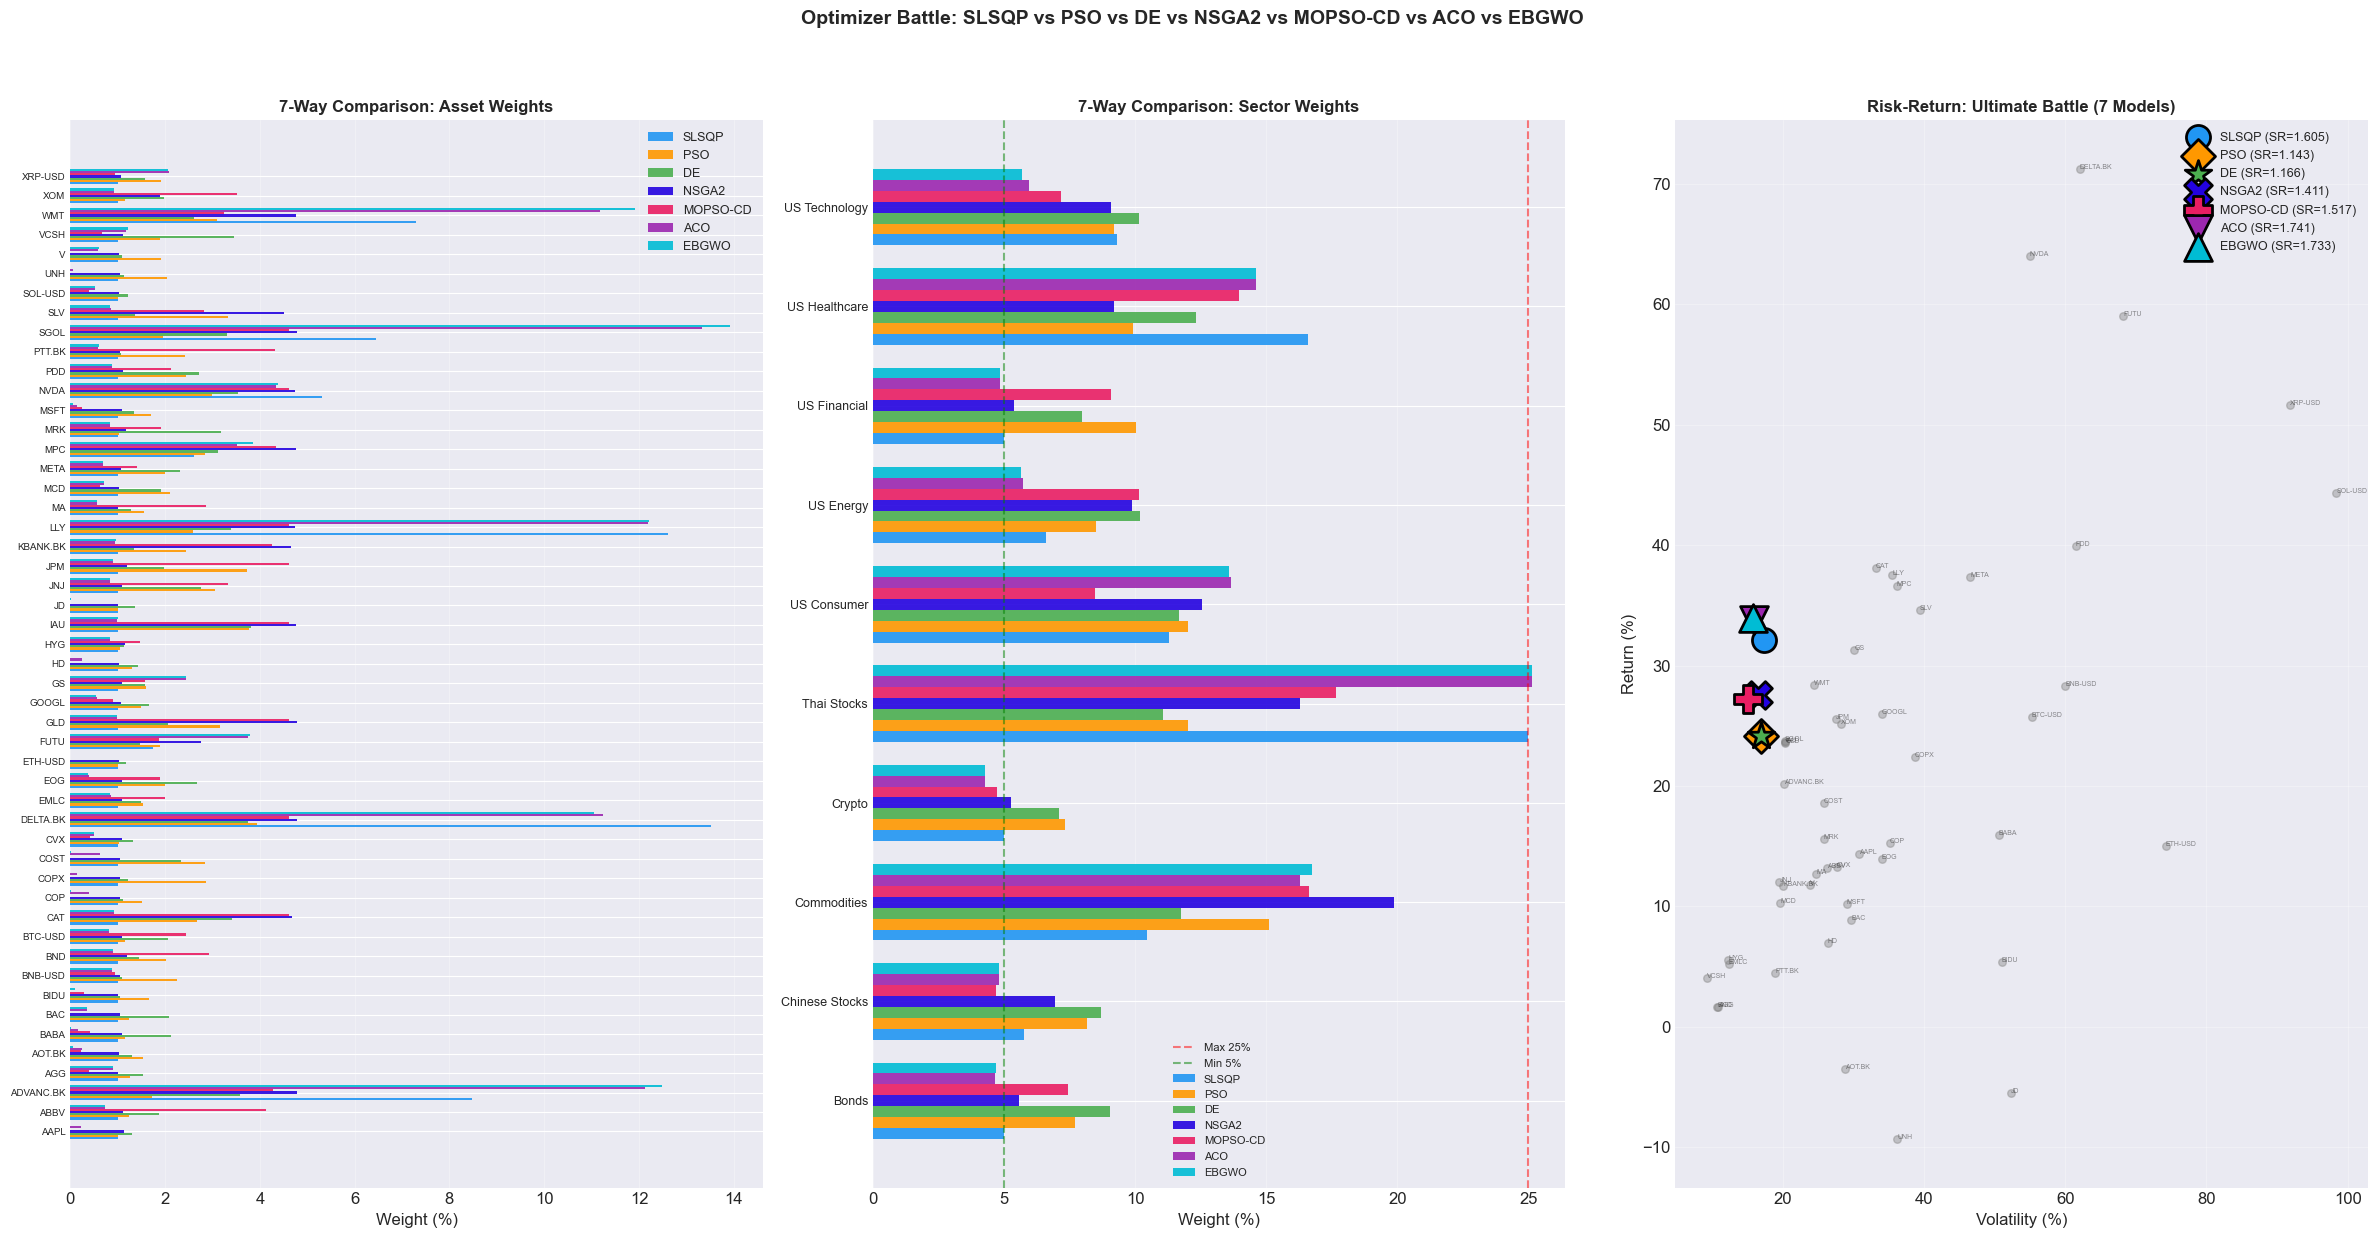



[SYSTEM] Assigned w_constrained = models_weights['ACO'] for all downstream analysis!


In [33]:
# === SLSQP vs PSO vs DE vs NSGA2 vs MOPSO-CD vs ACO vs EBGWO: Visualization ===

# ขยายขนาด Figure เล็กน้อยเพื่อให้มีพื้นที่พอสำหรับ 7 โมเดล
fig, axes = plt.subplots(1, 3, figsize=(24, 12)) 

# กำหนดความกว้างของแท่งกราฟใหม่ให้พอดีสำหรับ 7 แท่ง
x = np.arange(n_assets)
bw = 0.11 # ปรับขนาดความกว้างแท่งให้เล็กลง
offsets = [-3*bw, -2*bw, -bw, 0, bw, 2*bw, 3*bw]

# 1) Weight comparison bar chart
axes[0].barh(x + offsets[0], w_unconstrained * 100, bw, label="SLSQP", color="#2196F3", alpha=0.9)
axes[0].barh(x + offsets[1], w_pso * 100, bw, label="PSO", color="#FF9800", alpha=0.9)
axes[0].barh(x + offsets[2], w_de * 100, bw, label="DE", color="#4CAF50", alpha=0.9)
axes[0].barh(x + offsets[3], w_nsga * 100, bw, label="NSGA2", color="#2302E0", alpha=0.9)
axes[0].barh(x + offsets[4], w_mopso * 100, bw, label="MOPSO-CD", color="#E91E63", alpha=0.9)
axes[0].barh(x + offsets[5], aco_w * 100, bw, label="ACO", color="#9C27B0", alpha=0.9)     # เพิ่ม ACO สีม่วง
axes[0].barh(x + offsets[6], ebgwo_w * 100, bw, label="EBGWO", color="#00BCD4", alpha=0.9) # เพิ่ม EBGWO สีฟ้าคราม

axes[0].set_yticks(x)
axes[0].set_yticklabels(stock_list, fontsize=7)
axes[0].set_xlabel("Weight (%)")
axes[0].set_title("7-Way Comparison: Asset Weights", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis="x")

# 2) Sector weights comparison
sectors = sorted(set(stock_sector_map.values()))
slsqp_sec = [sum(w_unconstrained[i] for i, t in enumerate(stock_list) if stock_sector_map[t] == s) * 100 for s in sectors]
pso_sec = [sum(w_pso[i] for i, t in enumerate(stock_list) if stock_sector_map[t] == s) * 100 for s in sectors]
de_sec = [sum(w_de[i] for i, t in enumerate(stock_list) if stock_sector_map[t] == s) * 100 for s in sectors]
nsga_sec = [sum(w_nsga[i] for i, t in enumerate(stock_list) if stock_sector_map[t] == s) * 100 for s in sectors]
mopso_sec = [sum(w_mopso[i] for i, t in enumerate(stock_list) if stock_sector_map[t] == s) * 100 for s in sectors]
aco_sec = [sum(aco_w[i] for i, t in enumerate(stock_list) if stock_sector_map[t] == s) * 100 for s in sectors]       # คำนวณ Sector ของ ACO
ebgwo_sec = [sum(ebgwo_w[i] for i, t in enumerate(stock_list) if stock_sector_map[t] == s) * 100 for s in sectors]   # คำนวณ Sector ของ EBGWO

x_sec = np.arange(len(sectors))
axes[1].barh(x_sec + offsets[0], slsqp_sec, bw, label="SLSQP", color="#2196F3", alpha=0.9)
axes[1].barh(x_sec + offsets[1], pso_sec, bw, label="PSO", color="#FF9800", alpha=0.9)
axes[1].barh(x_sec + offsets[2], de_sec, bw, label="DE", color="#4CAF50", alpha=0.9)
axes[1].barh(x_sec + offsets[3], nsga_sec, bw, label="NSGA2", color="#2302E0", alpha=0.9)
axes[1].barh(x_sec + offsets[4], mopso_sec, bw, label="MOPSO-CD", color="#E91E63", alpha=0.9)
axes[1].barh(x_sec + offsets[5], aco_sec, bw, label="ACO", color="#9C27B0", alpha=0.9)
axes[1].barh(x_sec + offsets[6], ebgwo_sec, bw, label="EBGWO", color="#00BCD4", alpha=0.9)

axes[1].axvline(x=SECTOR_MAX_WEIGHT*100, color="red", linestyle="--", alpha=0.5, label=f"Max {SECTOR_MAX_WEIGHT*100:.0f}%")
axes[1].axvline(x=SECTOR_MIN_WEIGHT*100, color="green", linestyle="--", alpha=0.5, label=f"Min {SECTOR_MIN_WEIGHT*100:.0f}%")
axes[1].set_yticks(x_sec)
axes[1].set_yticklabels(sectors, fontsize=9)
axes[1].set_xlabel("Weight (%)")
axes[1].set_title("7-Way Comparison: Sector Weights", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis="x")

# 3) Risk-Return scatter
axes[2].scatter(slsqp_vol*100, slsqp_ret*100, s=300, c="#2196F3", edgecolors="black",
                linewidth=2, zorder=5, label=f"SLSQP (SR={slsqp_sharpe:.3f})")
axes[2].scatter(pso_vol*100, pso_ret*100, s=300, c="#FF9800", edgecolors="black",
                linewidth=2, zorder=5, marker="D", label=f"PSO (SR={pso_sharpe:.3f})")
axes[2].scatter(de_vol*100, de_ret*100, s=400, c="#4CAF50", edgecolors="black",
                linewidth=2, zorder=6, marker="*", label=f"DE (SR={de_sharpe:.3f})")
axes[2].scatter(w_nsga_vol*100, w_nsga_ret*100, s=400, color="#2302E0", edgecolors="black",
                linewidth=2, zorder=6, marker="X", label=f"NSGA2 (SR={w_nsga_sharpe:.3f})")
axes[2].scatter(w_mopso_vol*100, w_mopso_ret*100, s=400, color="#E91E63", edgecolors="black",
                linewidth=2, zorder=6, marker="P", label=f"MOPSO-CD (SR={w_mopso_sharpe:.3f})")
axes[2].scatter(aco_vol*100, aco_ret*100, s=400, color="#9C27B0", edgecolors="black",
                linewidth=2, zorder=6, marker="v", label=f"ACO (SR={aco_sharpe_real:.3f})") # จุดของ ACO ใช้สัญลักษณ์สามเหลี่ยมชี้ลง
axes[2].scatter(ebgwo_vol*100, ebgwo_ret*100, s=400, color="#00BCD4", edgecolors="black",
                linewidth=2, zorder=6, marker="^", label=f"EBGWO (SR={ebgwo_sharpe_real:.3f})") # จุดของ EBGWO ใช้สัญลักษณ์สามเหลี่ยมชี้ขึ้น

# Individual assets
for i, t in enumerate(stock_list):
    axes[2].scatter(np.sqrt(cov_annual.iloc[i,i])*100, mu_annual.iloc[i]*100,
                   s=30, c="gray", alpha=0.4)
    axes[2].annotate(t, (np.sqrt(cov_annual.iloc[i,i])*100, mu_annual.iloc[i]*100),
                     fontsize=5, alpha=0.5)
axes[2].set_xlabel("Volatility (%)", fontsize=12)
axes[2].set_ylabel("Return (%)", fontsize=12)
axes[2].set_title("Risk-Return: Ultimate Battle (7 Models)", fontsize=12, fontweight="bold")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle("Optimizer Battle: SLSQP vs PSO vs DE vs NSGA2 vs MOPSO-CD vs ACO vs EBGWO",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# ==================================================================
# PROPAGATE THE ULTIMATE WINNER DYNAMICALLY:
# (แทนที่จะฟิกซ์ตายตัว เราจะเลือกผู้ชนะจากคะแนนล่าสุดโดยอัตโนมัติ)
# ==================================================================
models_weights = {
    "SLSQP": w_unconstrained,
    "PSO": w_pso,
    "DE": w_de,
    "NSGA2": w_nsga,
    "MOPSO-CD": w_mopso,
    "ACO": aco_w,
    "EBGWO": ebgwo_w
}

# สำรองค่า SLSQP ตัวเก่าไว้เผื่ออ้างอิง
w_constrained_old = w_unconstrained.copy() 

# ใช้ตัวแปร winner ที่เราคำนวณไว้ก่อนหน้านี้ดึงน้ำหนักพอร์ตที่ดีที่สุดมาใช้ทำงานต่อ
w_constrained = models_weights[winner].copy() 
print(f"\n\n[SYSTEM] Assigned w_constrained = models_weights['{winner}'] for all downstream analysis!")

## 9. เปรียบเทียบ Sector/Asset Class Weights


In [34]:
import pandas as pd

def get_sector_weights(weights, stock_list, stock_sector_map):
    """คำนวณน้ำหนักรวมแต่ละกลุ่ม"""
    sector_w = {}
    for i, stock in enumerate(stock_list):
        sector = stock_sector_map[stock]
        sector_w[sector] = sector_w.get(sector, 0) + weights[i]
    return pd.Series(sector_w)

# คำนวณน้ำหนัก Sector ของแต่ละโมเดล
sector_w_uc = get_sector_weights(w_unconstrained, stock_list, stock_sector_map)
sector_w_slsqp = get_sector_weights(w_constrained_old, stock_list, stock_sector_map)
sector_w_pso = get_sector_weights(w_pso, stock_list, stock_sector_map)
sector_w_de = get_sector_weights(w_de, stock_list, stock_sector_map)
sector_w_nsga = get_sector_weights(w_nsga, stock_list, stock_sector_map)
sector_w_mopso = get_sector_weights(w_mopso, stock_list, stock_sector_map)
sector_w_aco = get_sector_weights(aco_w, stock_list, stock_sector_map)       # เพิ่ม ACO
sector_w_ebgwo = get_sector_weights(ebgwo_w, stock_list, stock_sector_map)   # เพิ่ม EBGWO

# สร้าง DataFrame เปรียบเทียบ
sector_comp = pd.DataFrame({
    "Unconstrained (%)": (sector_w_uc * 100).round(2),
    "SLSQP (%)": (sector_w_slsqp * 100).round(2),
    "PSO (%)": (sector_w_pso * 100).round(2),
    "DE (%)": (sector_w_de * 100).round(2),
    "NSGA2 (%)": (sector_w_nsga * 100).round(2),
    "MOPSO-CD (%)": (sector_w_mopso * 100).round(2),
    "ACO (%)": (sector_w_aco * 100).round(2),        # เพิ่มคอลัมน์ ACO
    "EBGWO (%)": (sector_w_ebgwo * 100).round(2),    # เพิ่มคอลัมน์ EBGWO
    # "Limit (%)": SECTOR_MAX_WEIGHT * 100
}).fillna(0)

# ขยายความยาวของเส้นขอบเพื่อให้ครอบคลุมข้อความและคอลัมน์ทั้งหมด
print("=" * 115)
print("📊 Sector Weights: Unconstrained | SLSQP | PSO | DE | NSGA2 | MOPSO-CD | ACO | EBGWO")
print("=" * 115)
print(sector_comp.to_string())

📊 Sector Weights: Unconstrained | SLSQP | PSO | DE | NSGA2 | MOPSO-CD | ACO | EBGWO
                Unconstrained (%)  SLSQP (%)  PSO (%)  DE (%)  NSGA2 (%)  MOPSO-CD (%)  ACO (%)  EBGWO (%)
US Technology                9.32       9.32     9.20   10.16       9.08          7.16     5.95       5.67
US Healthcare               16.60      16.60     9.92   12.33       9.19         13.97    14.63      14.62
Thai Stocks                 25.00      25.00    12.03   11.05      16.27         17.68    25.14      25.15
Bonds                        5.00       5.00     7.73    9.04       5.55          7.43     4.67       4.69
Chinese Stocks               5.74       5.74     8.16    8.72       6.96          4.71     4.80       4.79
US Financial                 5.00       5.00    10.03    7.98       5.37          9.06     4.84       4.85
Crypto                       5.00       5.00     7.31    7.09       5.26          4.71     4.29       4.27
US Consumer                 11.28      11.28    12.01   11.6

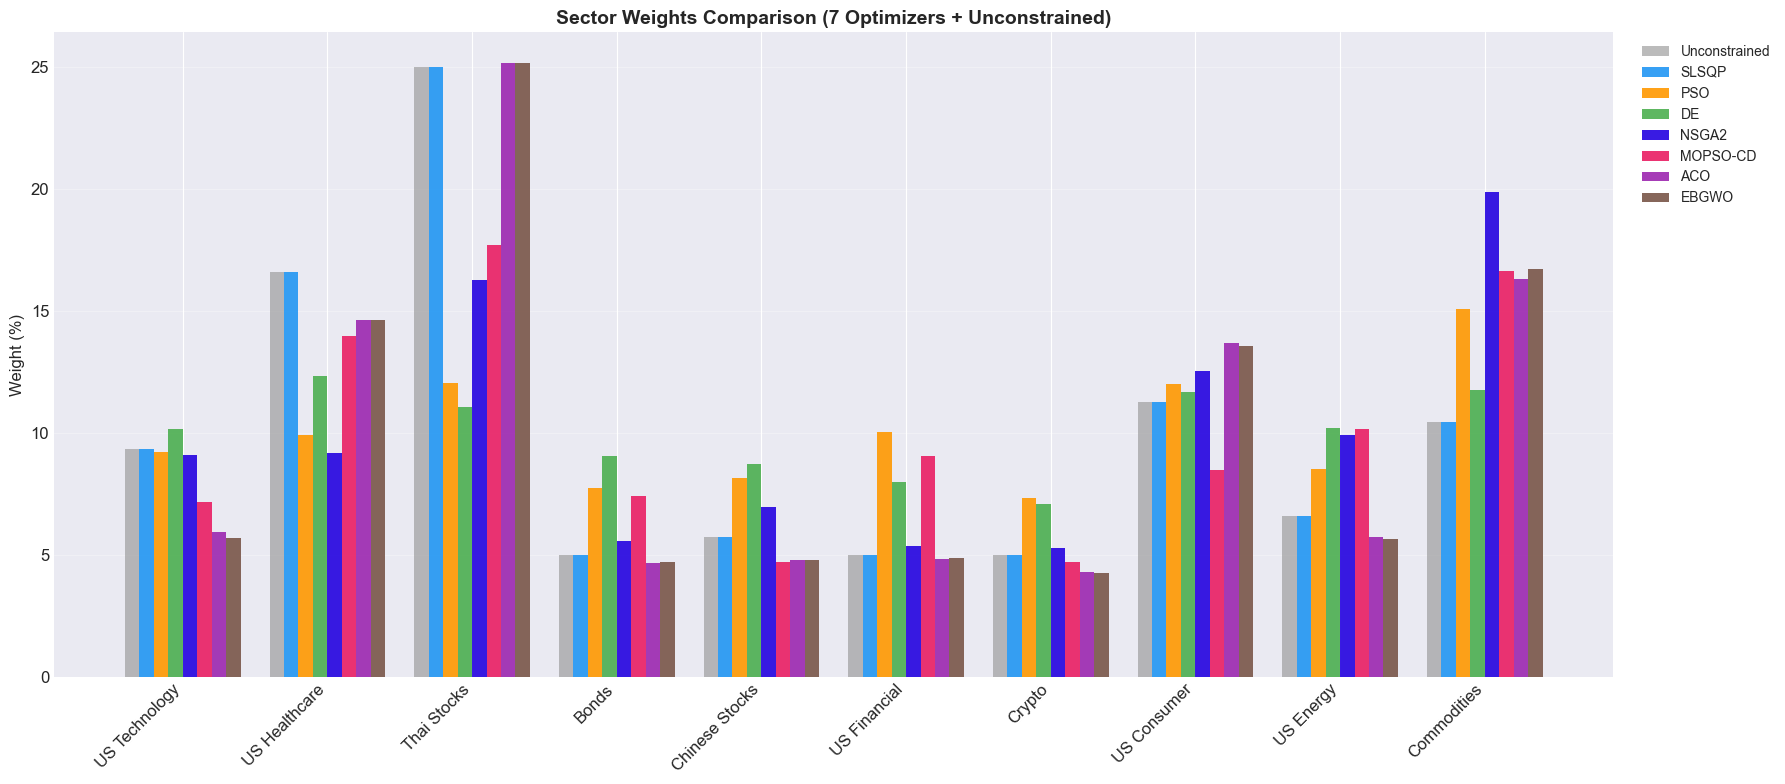

In [35]:
# === Visualization: Sector Weights Comparison ===

import matplotlib.pyplot as plt
import numpy as np

# ขยายความกว้างของกราฟเล็กน้อยเพื่อรองรับแท่งที่เพิ่มขึ้น
fig, ax = plt.subplots(figsize=(18, 8))

sectors = sector_comp.index
x = np.arange(len(sectors))
bw = 0.1  # ปรับลดขนาดความกว้างของแท่งเพื่อให้พอดีสำหรับ 8 แท่ง

# แสดงผลกราฟแท่งโดยขยับตำแหน่งแกน X ให้สมมาตร (8 แท่ง)
ax.bar(x - 3.5*bw, sector_comp["Unconstrained (%)"], bw, label="Unconstrained", color="#9E9E9E", alpha=0.7)
ax.bar(x - 2.5*bw, sector_comp["SLSQP (%)"], bw, label="SLSQP", color="#2196F3", alpha=0.9)
ax.bar(x - 1.5*bw, sector_comp["PSO (%)"], bw, label="PSO", color="#FF9800", alpha=0.9)
ax.bar(x - 0.5*bw, sector_comp["DE (%)"], bw, label="DE", color="#4CAF50", alpha=0.9)
ax.bar(x + 0.5*bw, sector_comp["NSGA2 (%)"], bw, label="NSGA2", color="#2302E0", alpha=0.9)
ax.bar(x + 1.5*bw, sector_comp["MOPSO-CD (%)"], bw, label="MOPSO-CD", color="#E91E63", alpha=0.9)
ax.bar(x + 2.5*bw, sector_comp["ACO (%)"], bw, label="ACO", color="#9C27B0", alpha=0.9)     # แท่งของ ACO (สีม่วง)
ax.bar(x + 3.5*bw, sector_comp["EBGWO (%)"], bw, label="EBGWO", color="#795548", alpha=0.9) # แท่งของ EBGWO (สีน้ำตาล)

# เส้นขอบเขตจำกัด (Limit)
# ax.axhline(y=SECTOR_MAX_WEIGHT*100, color="red", linestyle="--", linewidth=2, label=f"Max Limit ({SECTOR_MAX_WEIGHT*100:.0f}%)")
# ax.axhline(y=SECTOR_MIN_WEIGHT*100, color="green", linestyle="--", linewidth=2, label=f"Min Limit ({SECTOR_MIN_WEIGHT*100:.0f}%)")

ax.set_xticks(x)
ax.set_xticklabels(sectors, rotation=45, ha="right")
ax.set_ylabel("Weight (%)", fontsize=12)
ax.set_title("Sector Weights Comparison (7 Optimizers + Unconstrained)", fontsize=14, fontweight="bold")

# ย้ายตำแหน่ง Legend เพื่อไม่ให้บังข้อมูลกราฟ
ax.legend(fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 10. แสดงน้ำหนักสินทรัพย์แต่ละตัว


In [36]:
import pandas as pd

# สร้างตาราง Weights เปรียบเทียบสินทรัพย์รายตัว
weights_df = pd.DataFrame({
    "Ticker": stock_list,
    "Sector": [stock_sector_map[s] for s in stock_list],
    "Unconstrained (%)": (w_unconstrained * 100).round(2),
    "SLSQP (%)": (w_constrained_old * 100).round(2),
    "PSO (%)": (w_pso * 100).round(2),
    "DE (%)": (w_de * 100).round(2),
    "NSGA2 (%)": (w_nsga * 100).round(2),
    "MOPSO-CD (%)": (w_mopso * 100).round(2), # คอลัมน์ MOPSO-CD
    "ACO (%)": (aco_w * 100).round(2),        # เพิ่มคอลัมน์ ACO
    "EBGWO (%)": (ebgwo_w * 100).round(2)     # เพิ่มคอลัมน์ EBGWO
})

print("=" * 115)
print(f"📊 Individual Asset Weights (Top 10 in {winner} Portfolio)")
print("=" * 115)

# จัดเรียงตามน้ำหนักของ DE จากมากไปน้อย และแสดง 10 อันดับแรก
top10 = weights_df.sort_values(by=f"{winner} (%)", ascending=False).head(10)
print(top10.to_string(index=False))

📊 Individual Asset Weights (Top 10 in ACO Portfolio)
   Ticker         Sector  Unconstrained (%)  SLSQP (%)  PSO (%)  DE (%)  NSGA2 (%)  MOPSO-CD (%)  ACO (%)  EBGWO (%)
     SGOL    Commodities               6.45       6.45     1.96    3.31       4.77          4.61    13.34      13.92
      LLY  US Healthcare              12.60      12.60     2.59    3.39       4.75          4.61    12.19      12.21
ADVANC.BK    Thai Stocks               8.47       8.47     1.72    3.58       4.78          4.27    12.12      12.49
 DELTA.BK    Thai Stocks              13.53      13.53     3.93    3.76       4.78          4.61    11.24      11.05
      WMT    US Consumer               7.28       7.28     3.10    2.62       4.76          3.25    11.17      11.91
     NVDA  US Technology               5.32       5.32     2.98    3.54       4.74          4.61     4.33       4.38
     FUTU Chinese Stocks               1.74       1.74     1.89    1.46       2.75          1.87     3.75       3.78
      MPC  

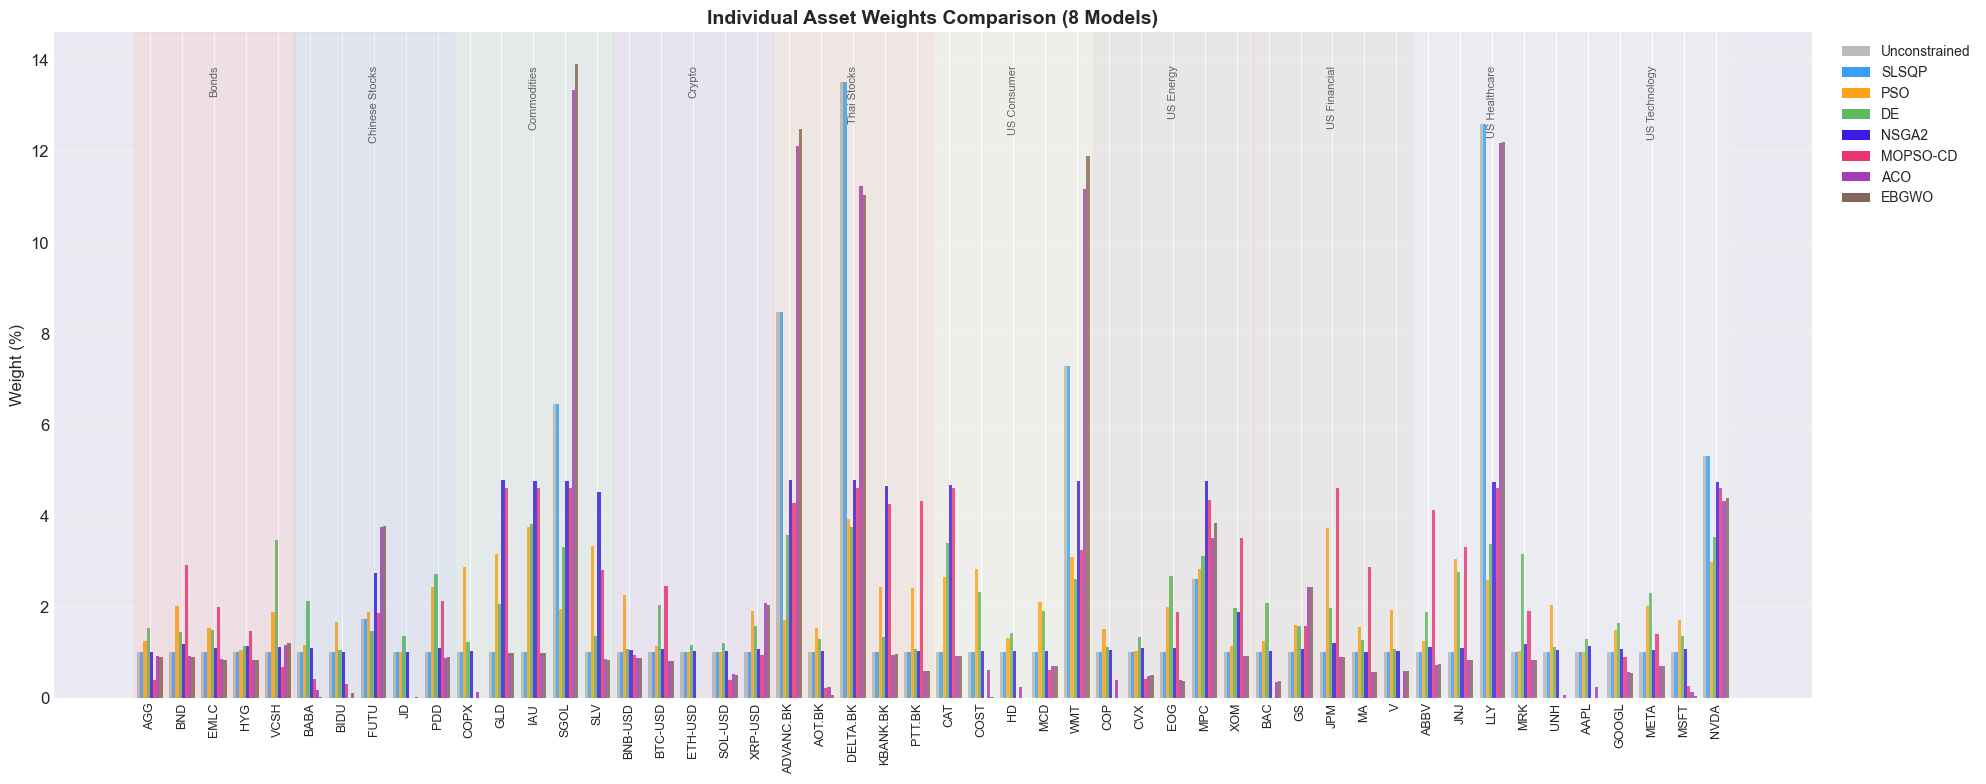

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# === Bar Chart: Individual Asset Weights ===

# เรียงตาม Sector เพื่อให้ดูง่าย
weights_df_sorted = weights_df.sort_values(by=["Sector", "Ticker"]).reset_index(drop=True)

# ขยายความกว้างของกราฟเป็น 20 เพื่อรองรับแท่งกราฟที่มากขึ้น
fig, ax = plt.subplots(figsize=(20, 8))
x = np.arange(len(weights_df_sorted))
bw = 0.1 # ปรับความกว้างของแท่งให้พอดีกับ 8 แท่ง

# แสดงผลกราฟแท่งโดยขยับตำแหน่งแกน X ให้สมมาตรสำหรับ 8 แท่ง
ax.bar(x - 3.5*bw, weights_df_sorted["Unconstrained (%)"], bw, label="Unconstrained", color="#9E9E9E", alpha=0.7)
ax.bar(x - 2.5*bw, weights_df_sorted["SLSQP (%)"], bw, label="SLSQP", color="#2196F3", alpha=0.9)
ax.bar(x - 1.5*bw, weights_df_sorted["PSO (%)"], bw, label="PSO", color="#FF9800", alpha=0.9)
ax.bar(x - 0.5*bw, weights_df_sorted["DE (%)"], bw, label="DE", color="#4CAF50", alpha=0.9)
ax.bar(x + 0.5*bw, weights_df_sorted["NSGA2 (%)"], bw, label="NSGA2", color="#2302E0", alpha=0.9)
ax.bar(x + 1.5*bw, weights_df_sorted["MOPSO-CD (%)"], bw, label="MOPSO-CD", color="#E91E63", alpha=0.9)
ax.bar(x + 2.5*bw, weights_df_sorted["ACO (%)"], bw, label="ACO", color="#9C27B0", alpha=0.9)       # เพิ่ม ACO
ax.bar(x + 3.5*bw, weights_df_sorted["EBGWO (%)"], bw, label="EBGWO", color="#795548", alpha=0.9)   # เพิ่ม EBGWO

# เส้น Limit
# ax.axhline(y=STOCK_MAX_WEIGHT*100, color="red", linestyle="--", alpha=0.5, label=f"Max Limit ({STOCK_MAX_WEIGHT*100:.0f}%)")
# ax.axhline(y=STOCK_MIN_WEIGHT*100, color="green", linestyle="--", alpha=0.5, label=f"Min Limit ({STOCK_MIN_WEIGHT*100:.0f}%)")

ax.set_xticks(x)
ax.set_xticklabels(weights_df_sorted["Ticker"], rotation=90, fontsize=9)
ax.set_ylabel("Weight (%)", fontsize=12)
ax.set_title("Individual Asset Weights Comparison (8 Models)", fontsize=14, fontweight="bold")

# ปรับตำแหน่ง Legend ให้อยู่นอกกราฟเพื่อไม่ให้บังข้อมูล
ax.legend(fontsize=10, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis="y")

# เพิ่มสีพื้นหลังแบ่ง Sector
current_sector = ""
start_idx = 0
colors = plt.cm.Pastel1(np.linspace(0, 1, 10))
color_idx = 0

for i, row in enumerate(weights_df_sorted.itertuples()):
    if row.Sector != current_sector:
        if i > 0:
            ax.axvspan(start_idx - 0.5, i - 0.5, color=colors[color_idx % 10], alpha=0.2)
            ax.text((start_idx + i - 1) / 2, ax.get_ylim()[1] * 0.95, current_sector, 
                    ha="center", va="top", rotation=90, fontsize=8, alpha=0.7)
            color_idx += 1
        current_sector = row.Sector
        start_idx = i

# ล็อตสุดท้ายสำหรับสีพื้นหลัง Sector
ax.axvspan(start_idx - 0.5, len(weights_df_sorted) - 0.5, color=colors[color_idx % 10], alpha=0.2)
ax.text((start_idx + len(weights_df_sorted) - 1) / 2, ax.get_ylim()[1] * 0.95, current_sector, 
        ha="center", va="top", rotation=90, fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

## 11. Efficient Frontier (เปรียบเทียบ)


In [38]:
def generate_efficient_frontier(mean_returns, cov_matrix, sector_constraint, n_points=30):
    """สร้าง Efficient Frontier"""
    n = len(mean_returns)
    
    # หา Min/Max Return ที่เป็นไปได้
    target_returns = np.linspace(
        mean_returns.min() * 252,
        mean_returns.max() * 252,
        n_points
    )
    
    frontier_vol = []
    frontier_ret = []
    
    if sector_constraint:
        bounds = tuple((STOCK_MIN_WEIGHT, STOCK_MAX_WEIGHT) for _ in range(n))
    else:
        bounds = tuple((0, 1) for _ in range(n))
    
    for target in target_returns:
        constraints = get_base_constraints()
        constraints.append({
            'type': 'eq',
            'fun': lambda w, t=target: np.sum(w * mean_returns) * 252 - t
        })
        if sector_constraint:
            constraints += get_sector_constraints(
                sector_stock_indices, SECTOR_MAX_WEIGHT, SECTOR_MIN_WEIGHT
            )
        
        init = np.array(n * [1./n])
        try:
            result = minimize(
                minimize_volatility, init,
                args=(mean_returns, cov_matrix),
                method='SLSQP',
                bounds=bounds,
                constraints=constraints,
                options={'maxiter': 1000}
            )
            if result.success:
                r, v, _ = portfolio_performance(result.x, mean_returns, cov_matrix)
                frontier_vol.append(v)
                frontier_ret.append(r)
        except:
            continue
    
    return frontier_vol, frontier_ret


print("⏳ Generating Efficient Frontiers...")
ef_vol_uc, ef_ret_uc = generate_efficient_frontier(mean_returns, cov_matrix, False)
ef_vol_c, ef_ret_c = generate_efficient_frontier(mean_returns, cov_matrix, True)
print("✅ Done!")


⏳ Generating Efficient Frontiers...
✅ Done!


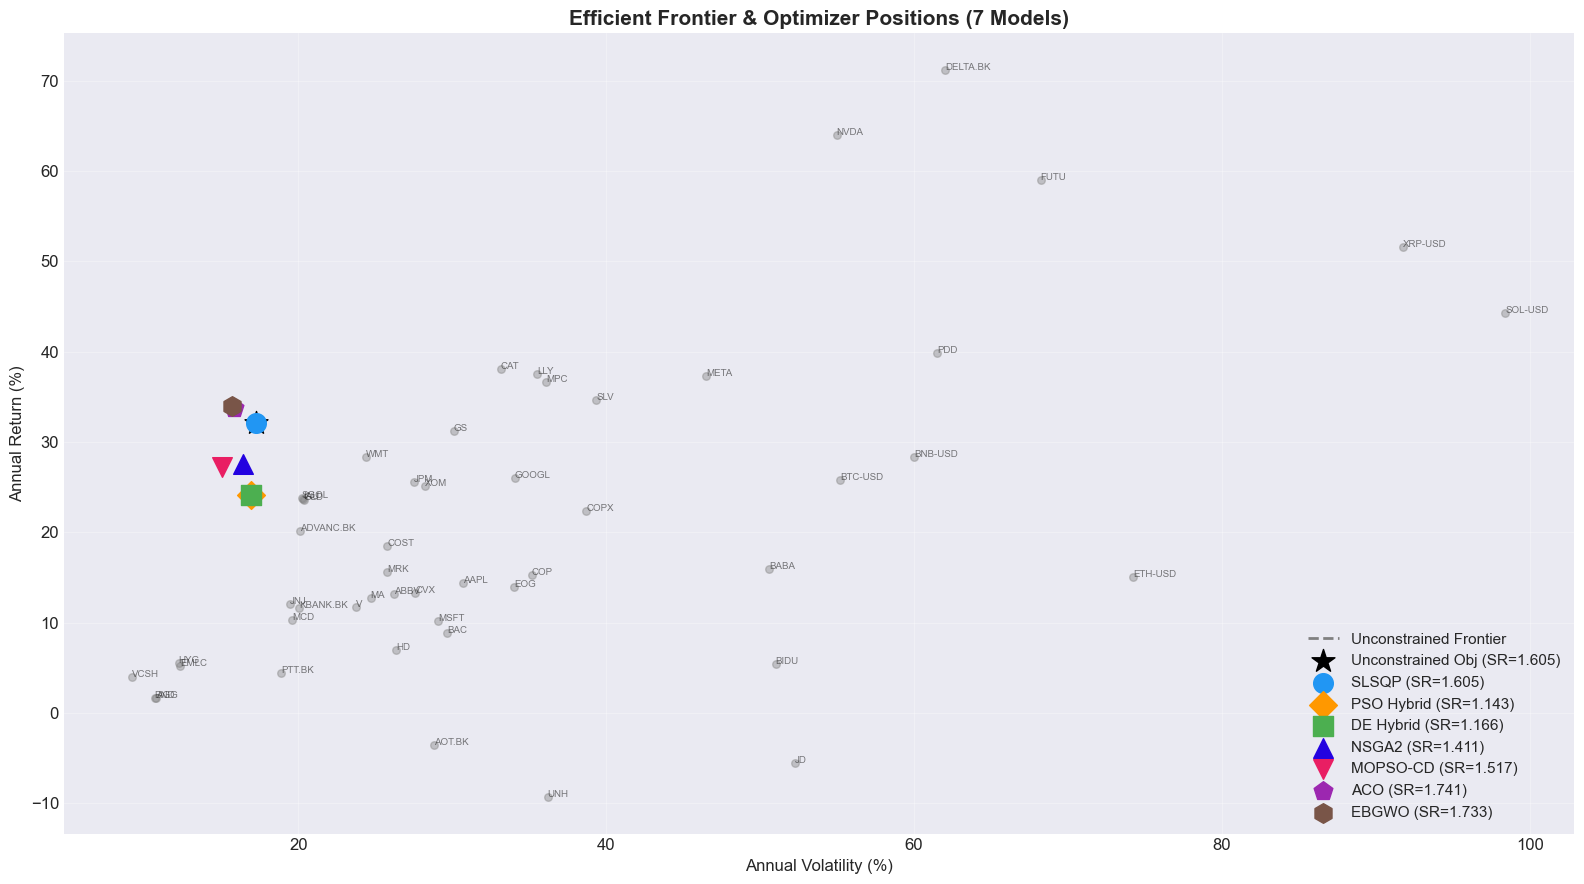

In [39]:
# === Plot Efficient Frontier with 7 Optimizers ===

fig, ax = plt.subplots(figsize=(16, 9))

# Plot Unconstrained Frontier
ax.plot([v*100 for v in ef_vol_uc], [r*100 for r in ef_ret_uc],
        "gray", linestyle="--", linewidth=2, label="Unconstrained Frontier")

# Plot Unconstrained Max Sharpe
ax.scatter(vol_uc*100, ret_uc*100, marker="*", color="black", s=300, zorder=5, 
           label=f"Unconstrained Obj (SR={sharpe_uc:.3f})")

# Plot the 7 optimizers
ax.scatter(slsqp_vol*100, slsqp_ret*100, marker="o", color="#2196F3", s=200, zorder=6, 
           label=f"SLSQP (SR={slsqp_sharpe:.3f})")
ax.scatter(pso_vol*100, pso_ret*100, marker="D", color="#FF9800", s=200, zorder=6, 
           label=f"PSO Hybrid (SR={pso_sharpe:.3f})")
ax.scatter(de_vol*100, de_ret*100, marker="s", color="#4CAF50", s=200, zorder=7, 
           label=f"DE Hybrid (SR={de_sharpe:.3f})")
ax.scatter(w_nsga_vol*100, w_nsga_ret*100, marker="^", color="#2302E0", s=200, zorder=7, 
           label=f"NSGA2 (SR={w_nsga_sharpe:.3f})") # แก้ไข Label และตัวแปรให้ถูกต้อง
ax.scatter(w_mopso_vol*100, w_mopso_ret*100, marker="v", color="#E91E63", s=200, zorder=7, 
           label=f"MOPSO-CD (SR={w_mopso_sharpe:.3f})") # เพิ่ม MOPSO-CD
ax.scatter(aco_vol*100, aco_ret*100, marker="p", color="#9C27B0", s=200, zorder=7, 
           label=f"ACO (SR={aco_sharpe_real:.3f})") # เพิ่ม ACO
ax.scatter(ebgwo_vol*100, ebgwo_ret*100, marker="h", color="#795548", s=200, zorder=7, 
           label=f"EBGWO (SR={ebgwo_sharpe_real:.3f})") # เพิ่ม EBGWO

# Individual assets
for i, t in enumerate(stock_list):
    ax.scatter(np.sqrt(cov_annual.iloc[i,i])*100, mu_annual.iloc[i]*100,
               s=30, c="gray", alpha=0.4)
    ax.annotate(t, (np.sqrt(cov_annual.iloc[i,i])*100, mu_annual.iloc[i]*100),
                fontsize=7, alpha=0.6)

ax.set_title("Efficient Frontier & Optimizer Positions (7 Models)", fontsize=15, fontweight="bold")
ax.set_xlabel("Annual Volatility (%)", fontsize=12)
ax.set_ylabel("Annual Return (%)", fontsize=12)

# จัดตำแหน่ง Legend เพื่อไม่ให้บังเส้นกราฟ
ax.legend(fontsize=11, loc="lower right") 
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Backtest: เปรียบเทียบ Portfolio Performance


In [42]:
# คำนวณ portfolio returns ของแต่ละโมเดล
port_returns_uc = (returns * w_unconstrained).sum(axis=1)
port_returns_slsqp = (returns * w_constrained_old).sum(axis=1)
port_returns_pso = (returns * w_pso).sum(axis=1)
port_returns_de = (returns * w_de).sum(axis=1)
port_returns_NSGA = (returns * w_nsga).sum(axis=1)
port_returns_mopso = (returns * w_mopso).sum(axis=1)
port_returns_aco = (returns * aco_w).sum(axis=1)      # เพิ่ม ACO
port_returns_ebgwo = (returns * ebgwo_w).sum(axis=1)  # เพิ่ม EBGWO

# Equal-weight benchmark
w_equal = np.array([1/n_assets] * n_assets) 
port_returns_eq = (returns * w_equal).sum(axis=1)

📊 สรุปผล Backtest Performance (8 Optimizers + Equal Weight)
    Portfolio  Total Return (%)  Annual Return (%)  Annual Vol (%)  Sharpe Ratio  Max Drawdown (%)  Calmar Ratio
        EBGWO            233.74              33.95           15.72         1.880            -16.75         2.027
          ACO            231.23              33.76           15.82         1.856            -16.92         1.995
Unconstrained            209.11              32.12           17.28         1.605            -18.83         1.706
        SLSQP            209.11              32.12           17.28         1.605            -18.83         1.706
        NSGA2            162.86              27.58           16.43         1.411            -14.40         1.915
     MOPSO-CD            161.31              27.20           15.03         1.517            -12.44         2.186
           DE            130.94              24.15           16.95         1.166            -14.40         1.677
          PSO            129.32     

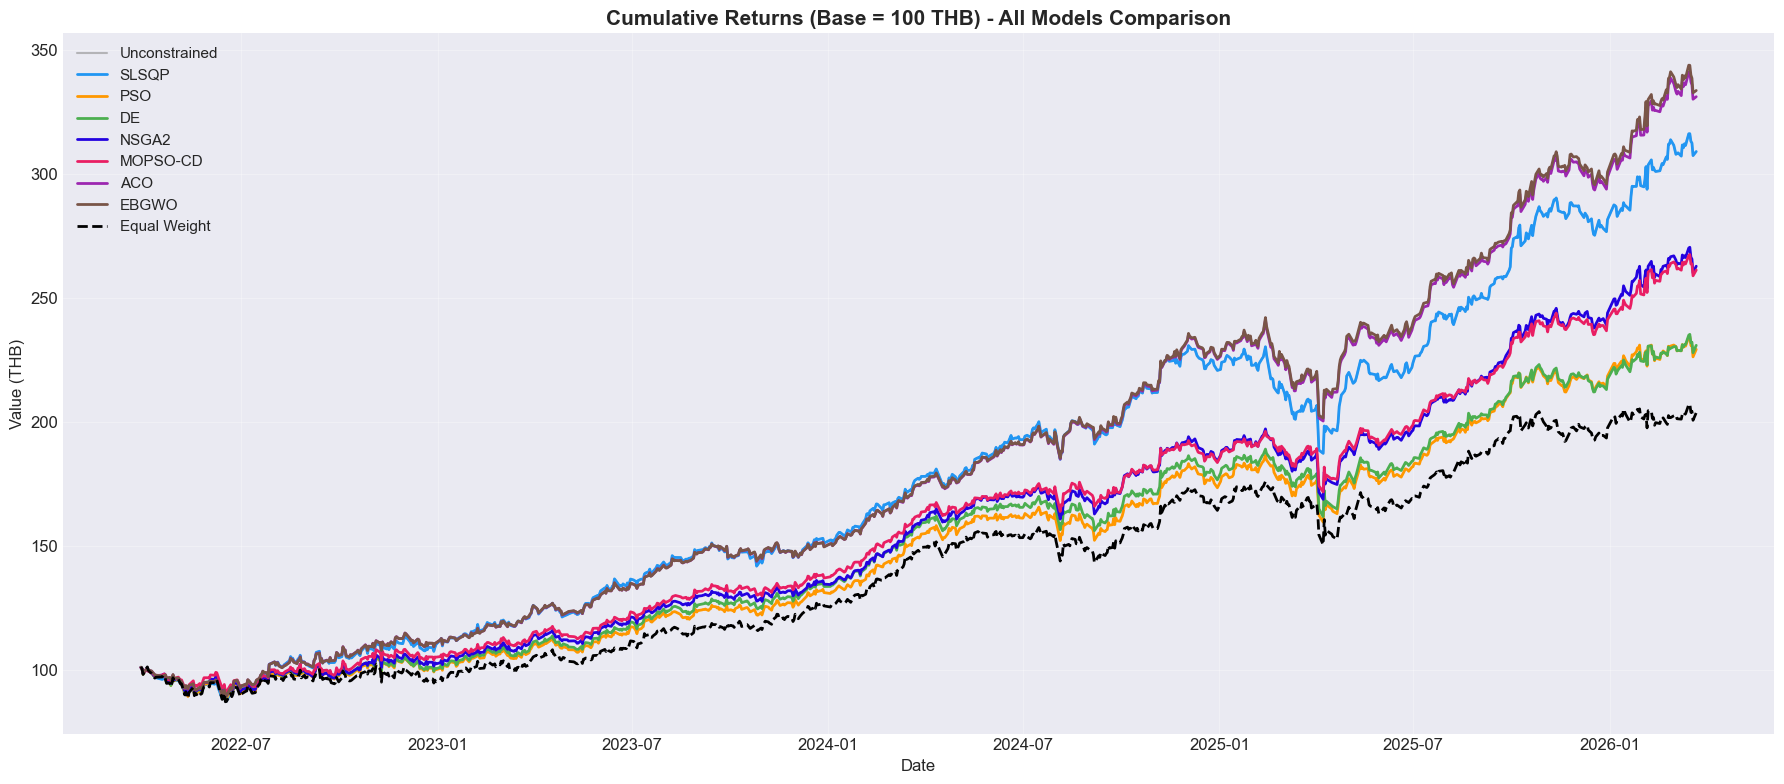

In [43]:
# === สรุปผล Backtest (8 Optimizers + Equal Weight) ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def portfolio_metrics(daily_returns, name):
    total_return = (1 + daily_returns).prod() - 1
    annual_ret = daily_returns.mean() * 252
    annual_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (annual_ret - RISK_FREE_RATE) / annual_vol
    
    cum_returns = (1 + daily_returns).cumprod()
    peak = cum_returns.cummax()
    drawdown = (cum_returns - peak) / peak
    max_dd = drawdown.min()
    calmar = annual_ret / abs(max_dd) if max_dd != 0 else 0
    
    return [name, total_return, annual_ret, annual_vol, sharpe, max_dd, calmar]

results = [
    portfolio_metrics(port_returns_uc, "Unconstrained"),
    portfolio_metrics(port_returns_slsqp, "SLSQP"),
    portfolio_metrics(port_returns_pso, "PSO"),
    portfolio_metrics(port_returns_de, "DE"),
    portfolio_metrics(port_returns_NSGA, "NSGA2"),
    portfolio_metrics(port_returns_mopso, "MOPSO-CD"),
    portfolio_metrics(port_returns_aco, "ACO"),         # เพิ่มผลลัพธ์พอร์ต ACO
    portfolio_metrics(port_returns_ebgwo, "EBGWO"),     # เพิ่มผลลัพธ์พอร์ต EBGWO
    portfolio_metrics(port_returns_eq, "Equal Weight")
]

columns = ["Portfolio", "Total Return (%)", "Annual Return (%)", "Annual Vol (%)", "Sharpe Ratio", "Max Drawdown (%)", "Calmar Ratio"]
results_df = pd.DataFrame(results, columns=columns)

# Format as percentage
for col in ["Total Return (%)", "Annual Return (%)", "Annual Vol (%)", "Max Drawdown (%)"]:
    results_df[col] = (results_df[col] * 100).round(2)

results_df["Sharpe Ratio"] = results_df["Sharpe Ratio"].round(3)
results_df["Calmar Ratio"] = results_df["Calmar Ratio"].round(3)

# ขยายขนาดของเส้นแบ่งให้เหมาะสมกับข้อมูล
print("=" * 115)
print("📊 สรุปผล Backtest Performance (8 Optimizers + Equal Weight)")
print("=" * 115)
print(results_df.sort_values(by="Total Return (%)",ascending=False).to_string(index=False))

# === Visualize Cumulative Returns ===

plt.figure(figsize=(18, 8))
plt.plot((1 + port_returns_uc).cumprod() * 100, label="Unconstrained", color="#9E9E9E", alpha=0.7)
plt.plot((1 + port_returns_slsqp).cumprod() * 100, label="SLSQP", color="#2196F3", linewidth=2)
plt.plot((1 + port_returns_pso).cumprod() * 100, label="PSO", color="#FF9800", linewidth=2)
plt.plot((1 + port_returns_de).cumprod() * 100, label="DE", color="#4CAF50", linewidth=2)
plt.plot((1 + port_returns_NSGA).cumprod() * 100, label="NSGA2", color="#2302E0", linewidth=2)
plt.plot((1 + port_returns_mopso).cumprod() * 100, label="MOPSO-CD", color="#E91E63", linewidth=2)
plt.plot((1 + port_returns_aco).cumprod() * 100, label="ACO", color="#9C27B0", linewidth=2)         # เพิ่มเส้น ACO (สีม่วง)
plt.plot((1 + port_returns_ebgwo).cumprod() * 100, label="EBGWO", color="#795548", linewidth=2)     # เพิ่มเส้น EBGWO (สีน้ำตาล)

# เปลี่ยนสี Equal Weight เป็นสีดำเส้นประ เพื่อใช้เป็น Benchmark ที่ชัดเจน
plt.plot((1 + port_returns_eq).cumprod() * 100, label="Equal Weight", color="black", linestyle="--", linewidth=2)

plt.title("Cumulative Returns (Base = 100 THB) - All Models Comparison", fontsize=15, fontweight="bold")
plt.ylabel("Value (THB)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Transaction Costs (TC) — ต้นทุนในการทำธุรกรรม

### ประเภทต้นทุน:
| ประเภท | รายละเอียด | ค่าเริ่มต้น |
|--------|-----------|------------|
| **Broker Fee** | ค่าธรรมเนียมโบรกเกอร์ | 0.10% |
| **Tax** | ภาษีหัก ณ ที่จ่าย | 0.05% |
| **Bid-Ask Spread** | ส่วนต่างราคา (Liquidity Cost) | 0.05% |
| **รวม (Total TC)** | ต้นทุนต่อการซื้อขาย 1 ครั้ง | **0.20%** |


In [76]:
# ==========================================================
# Transaction Costs (TC) Analysis
# ==========================================================

# --- TC Parameters ---
BROKER_FEE = 0.0010    # 0.10% ค่าธรรมเนียมโบรกเกอร์
TAX = 0.0005           # 0.05% ภาษี
BID_ASK_SPREAD = 0.0005  # 0.05% ส่วนต่างราคา
TOTAL_TC = BROKER_FEE + TAX + BID_ASK_SPREAD  # 0.20% per trade
REBALANCE_FREQ = 21    # ปรับพอร์ตทุก 21 Days (รายเดือน)

print("=" * 65)
print("Transaction Costs (TC) Configuration")
print("=" * 65)
print(f"  Broker Fee     : {BROKER_FEE*100:.2f}%")
print(f"  Tax            : {TAX*100:.2f}%")
print(f"  Bid-Ask Spread : {BID_ASK_SPREAD*100:.2f}%")
print(f"  Total TC/trade : {TOTAL_TC*100:.2f}%")
print(f"  Rebalance Freq : Every {REBALANCE_FREQ} trading days")

# --- Backtest with TC ---
def backtest_with_tc(returns, weights, tc_rate, rebal_days):
    """Backtest with transaction costs on rebalancing days"""
    n_days = len(returns)
    port_values = [1.0]  # start with 1.0
    current_weights = weights.copy()
    total_tc_paid = 0
    n_rebalances = 0
    daily_tc = []
    
    for day in range(n_days):
        daily_ret = returns.iloc[day].values
        
        # Portfolio return for the day
        port_ret = np.sum(current_weights * daily_ret)
        
        # Update weights based on returns (drift)
        new_vals = current_weights * (1 + daily_ret)
        current_weights = new_vals / new_vals.sum()
        
        # Rebalance check
        tc_cost = 0
        if (day + 1) % rebal_days == 0:
            # Calculate turnover (how much weights changed)
            turnover = np.sum(np.abs(current_weights - weights))
            tc_cost = turnover * tc_rate
            total_tc_paid += tc_cost
            current_weights = weights.copy()
            n_rebalances += 1
        
        new_value = port_values[-1] * (1 + port_ret - tc_cost)
        port_values.append(new_value)
        daily_tc.append(tc_cost)
    
    return np.array(port_values[1:]), total_tc_paid, n_rebalances, daily_tc

# Run backtests
print("\nRunning backtests...")

# Without TC
cum_no_tc_uc = (1 + (returns * w_unconstrained).sum(axis=1)).cumprod()
cum_no_tc_c = (1 + (returns * w_constrained).sum(axis=1)).cumprod()

# With TC
cum_tc_uc, tc_paid_uc, n_reb_uc, _ = backtest_with_tc(returns, w_unconstrained, TOTAL_TC, REBALANCE_FREQ)
cum_tc_c, tc_paid_c, n_reb_c, _ = backtest_with_tc(returns, w_constrained, TOTAL_TC, REBALANCE_FREQ)

print(f"  Rebalances: {n_reb_uc} times over {len(returns)} days")
print(f"  Total TC paid (Unconstrained): {tc_paid_uc*100:.2f}%")
print(f"  Total TC paid (Constrained):   {tc_paid_c*100:.2f}%")


Transaction Costs (TC) Configuration
  Broker Fee     : 0.10%
  Tax            : 0.05%
  Bid-Ask Spread : 0.05%
  Total TC/trade : 0.20%
  Rebalance Freq : Every 21 trading days

Running backtests...
  Rebalances: 69 times over 1460 days
  Total TC paid (Unconstrained): 0.73%
  Total TC paid (Constrained):   0.87%


Transaction Costs Impact: Before vs After TC
              Portfolio  Total Return (%)  Annual Return (%)  Annual Vol (%)  Sharpe Ratio  Max DD (%)
  Unconstrained (NO TC)           250.429             24.165          12.170         1.629     -17.415
Unconstrained (WITH TC)           247.881             24.009          12.170         1.617     -17.437
          SLSQP (NO TC)           230.425             22.912          14.968         1.241     -21.440
        SLSQP (WITH TC)           227.565             22.727          14.968         1.229     -21.506
            PSO (NO TC)           230.425             22.912          14.968         1.241     -21.440
          PSO (WITH TC)           227.565             22.727          14.968         1.229     -21.506
             DE (NO TC)           230.425             22.912          14.968         1.241     -21.440
           DE (WITH TC)           227.565             22.727          14.968         1.229     -21.506

TC Drag (กำไรที่หายไปจาก TC

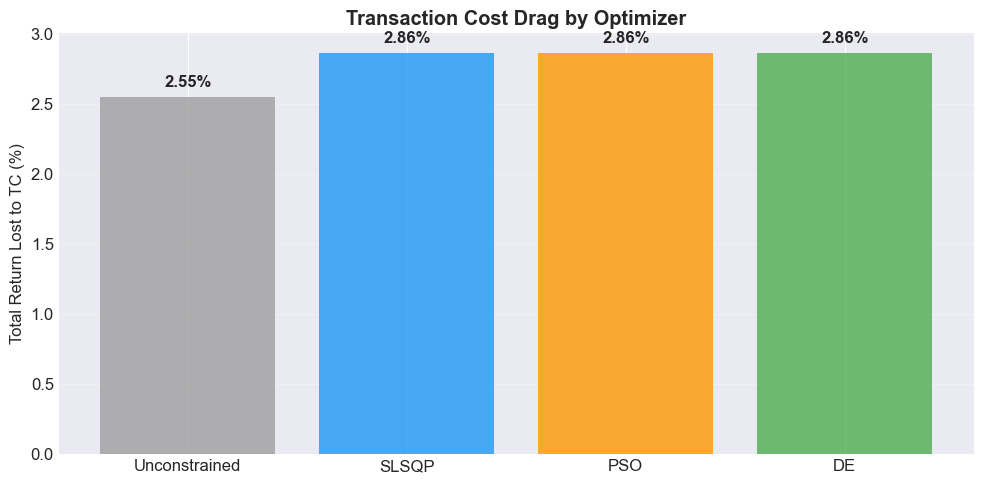

In [77]:
# === TC Impact: Comparison Table & Charts ===

def calc_metrics(cum_values, label):
    total_ret = cum_values[-1] / cum_values[0] - 1
    days = len(cum_values)
    ann_ret = (1 + total_ret)**(252/days) - 1
    
    daily_rets = pd.Series(cum_values).pct_change().dropna()
    ann_vol = daily_rets.std() * np.sqrt(252)
    sharpe = (ann_ret - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else 0
    
    peak = pd.Series(cum_values).cummax()
    dd = (pd.Series(cum_values) - peak) / peak
    max_dd = dd.min()
    
    return [label, total_ret*100, ann_ret*100, ann_vol*100, sharpe, max_dd*100]

tc_results = []

# 1. Unconstrained
cum_uc_notc, _, _, _ = backtest_with_tc(returns, w_unconstrained, 0.0, REBALANCE_FREQ)
cum_uc_tc, _, _, _ = backtest_with_tc(returns, w_unconstrained, TOTAL_TC, REBALANCE_FREQ)
tc_results.append(calc_metrics(cum_uc_notc, "Unconstrained (NO TC)"))
tc_results.append(calc_metrics(cum_uc_tc, "Unconstrained (WITH TC)"))

# 2. SLSQP
cum_slsqp_notc, _, _, _ = backtest_with_tc(returns, w_constrained_old, 0.0, REBALANCE_FREQ)
cum_slsqp_tc, _, _, _ = backtest_with_tc(returns, w_constrained_old, TOTAL_TC, REBALANCE_FREQ)
tc_results.append(calc_metrics(cum_slsqp_notc, "SLSQP (NO TC)"))
tc_results.append(calc_metrics(cum_slsqp_tc, "SLSQP (WITH TC)"))

# 3. PSO
cum_pso_notc, _, _, _ = backtest_with_tc(returns, w_pso, 0.0, REBALANCE_FREQ)
cum_pso_tc, _, _, _ = backtest_with_tc(returns, w_pso, TOTAL_TC, REBALANCE_FREQ)
tc_results.append(calc_metrics(cum_pso_notc, "PSO (NO TC)"))
tc_results.append(calc_metrics(cum_pso_tc, "PSO (WITH TC)"))

# 4. DE
cum_de_notc, _, _, _ = backtest_with_tc(returns, w_de, 0.0, REBALANCE_FREQ)
cum_de_tc, _, _, _ = backtest_with_tc(returns, w_de, TOTAL_TC, REBALANCE_FREQ)
tc_results.append(calc_metrics(cum_de_notc, "DE (NO TC)"))
tc_results.append(calc_metrics(cum_de_tc, "DE (WITH TC)"))

tc_df = pd.DataFrame(tc_results, columns=["Portfolio", "Total Return (%)", "Annual Return (%)", "Annual Vol (%)", "Sharpe Ratio", "Max DD (%)"])
tc_df = tc_df.round(3)

print("=" * 85)
print("Transaction Costs Impact: Before vs After TC")
print("=" * 85)
print(tc_df.to_string(index=False))

drag_uc = tc_df.iloc[0]["Total Return (%)"] - tc_df.iloc[1]["Total Return (%)"]
drag_slsqp = tc_df.iloc[2]["Total Return (%)"] - tc_df.iloc[3]["Total Return (%)"]
drag_pso = tc_df.iloc[4]["Total Return (%)"] - tc_df.iloc[5]["Total Return (%)"]
drag_de = tc_df.iloc[6]["Total Return (%)"] - tc_df.iloc[7]["Total Return (%)"]

print("\nTC Drag (กำไรที่หายไปจาก TC สำหรับระยะเวลา 4 ปี):")
print(f"  Unconstrained: {drag_uc:.2f}% of total return lost")
print(f"  SLSQP:         {drag_slsqp:.2f}% of total return lost")
print(f"  PSO:           {drag_pso:.2f}% of total return lost")
print(f"  DE:            {drag_de:.2f}% of total return lost")

# Bar Chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
drags = [drag_uc, drag_slsqp, drag_pso, drag_de]
labels = ["Unconstrained", "SLSQP", "PSO", "DE"]
colors = ["#9E9E9E", "#2196F3", "#FF9800", "#4CAF50"]

bars = ax.bar(labels, drags, color=colors, alpha=0.8)
ax.set_ylabel("Total Return Lost to TC (%)")
ax.set_title("Transaction Cost Drag by Optimizer", fontweight="bold")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f"{height:.2f}%", ha="center", va="bottom", fontweight="bold")

plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## 14. Transaction Lots (TL) — หน่วยการซื้อขาย

สินทรัพย์บางอย่างไม่สามารถซื้อเป็นทศนิยมได้ ต้องซื้อเป็น **จำนวนเต็ม** หรือ **Lot**

| ตลาด | Lot Size | ตัวอย่าง |
|------|----------|--------|
| 🇹🇭 SET (หุ้นไทย) | **100 หุ้น/Lot** | ซื้อ DELTA.BK ต้องซื้อ 100, 200, 300... |
| 🇺🇸 US Stocks | **1 หุ้น** | ซื้อ AAPL ได้ 1, 2, 3... หุ้น |
| 🇺🇸 US ETFs | **1 หน่วย** | ซื้อ GLD ได้ 1, 2, 3... หน่วย |
| ₿ Crypto | **ทศนิยมได้** | ซื้อ BTC 0.001 ได้ |


In [43]:
# ==========================================================
# Transaction Lots (TL) - ปรับน้ำหนักให้ซื้อได้จริง
# ==========================================================

PORTFOLIO_VALUE = 1_000_000  # เงินลงทุน 1,000,000 บาท

# กำหนด Lot Size ตามจริงของแต่ละตลาด
lot_sizes = {}
for ticker in stock_list:
    if ticker.endswith(".BK"):        # หุ้นไทย = 100 หุ้น/Lot
        lot_sizes[ticker] = 100
    elif ticker in ["BTC-USD", "ETH-USD"]:  # Crypto = ซื้อทศนิยมได้
        lot_sizes[ticker] = 0.0001
    else:                             # US Stocks & ETFs = 1 หุ้น
        lot_sizes[ticker] = 1

# ราคาล่าสุดของแต่ละตัว
latest_prices = data.iloc[-1]

print("=" * 80)
print(f"Transaction Lots Analysis (Portfolio = {PORTFOLIO_VALUE:,.0f} THB)")
print("=" * 80)

def adjust_to_lots(weights, prices, port_value, lot_sizes):
    """ปรับน้ำหนักให้ซื้อได้จริงตาม Lot Size"""
    results = []
    total_invested = 0
    
    for i, ticker in enumerate(prices.index):
        target_value = weights[i] * port_value
        price = prices[ticker]
        lot = lot_sizes[ticker]
        
        # คำนวณจำนวนที่ซื้อได้จริง (ปัดลง)
        if lot < 1:  # Crypto
            shares = target_value / price
            shares = round(shares, 4)
        else:
            raw_shares = target_value / price
            shares = int(raw_shares / lot) * lot  # ปัดลงเป็น Lot
        
        actual_value = shares * price
        total_invested += actual_value
        
        results.append({
            "Ticker": ticker,
            "Sector": stock_sector_map[ticker],
            "Lot Size": lot,
            "Price": round(price, 2),
            "Target Wt (%)": round(weights[i] * 100, 2),
            "Target Value": round(target_value, 0),
            "Shares": shares,
            "Actual Value": round(actual_value, 0),
            "Actual Wt (%)": 0,  # calculate after
        })
    
    # Recalculate actual weights
    for r in results:
        r["Actual Wt (%)"] = round(r["Actual Value"] / total_invested * 100, 2)
    
    return pd.DataFrame(results), total_invested

# ปรับ Constrained portfolio
lots_df, total_inv = adjust_to_lots(w_constrained, latest_prices, PORTFOLIO_VALUE, lot_sizes)

print(f"\nSector-Constrained (DE) Portfolio (Lot-Adjusted):")
print("-" * 80)
print(lots_df.to_string(index=False))
print(f"\nTotal Invested: {total_inv:>15,.0f} THB")
print(f"Cash Remaining: {PORTFOLIO_VALUE - total_inv:>15,.0f} THB")
print(f"Cash %:         {(PORTFOLIO_VALUE - total_inv)/PORTFOLIO_VALUE*100:>14.2f}%")


Transaction Lots Analysis (Portfolio = 1,000,000 THB)

Sector-Constrained (DE) Portfolio (Lot-Adjusted):
--------------------------------------------------------------------------------
   Ticker         Sector  Lot Size      Price  Target Wt (%)  Target Value  Shares  Actual Value  Actual Wt (%)
     AAPL  US Technology    1.0000    8269.75           0.00           0.0     0.0           0.0           0.00
     ABBV  US Healthcare    1.0000    6738.71           0.00           0.0     0.0           0.0           0.00
ADVANC.BK    Thai Stocks  100.0000     366.00          20.43      204342.0   500.0      183000.0          20.52
      AGG          Bonds    1.0000    3256.40           0.00           0.0     0.0           0.0           0.00
   AOT.BK    Thai Stocks  100.0000      47.75           0.00           0.0     0.0           0.0           0.00
     BABA Chinese Stocks    1.0000    4145.23           0.00           0.0     0.0           0.0           0.00
      BAC   US Financial    1.

In [61]:
# === Lot Adjustment Impact: ความแตกต่าง Target vs Actual ===

# Weight deviation
lots_df["Wt Diff (%)"] = lots_df["Actual Wt (%)"] - lots_df["Target Wt (%)"]

tracking_error = np.sqrt(np.sum(lots_df["Wt Diff (%)"].values**2))
max_dev = lots_df["Wt Diff (%)"].abs().max()
avg_dev = lots_df["Wt Diff (%)"].abs().mean()

print("=" * 60)
print("Lot Adjustment Impact")
print("=" * 60)
print(f"  Tracking Error (RMSE):    {tracking_error:.3f}%")
print(f"  Max Weight Deviation:     {max_dev:.3f}%")
print(f"  Avg Weight Deviation:     {avg_dev:.3f}%")

# Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1) Target vs Actual weights
x = np.arange(len(lots_df))
w_bar = 0.35
axes[0].barh(x - w_bar/2, lots_df["Target Wt (%)"], w_bar, label="Target (Optimal)", color="#3498db", alpha=0.8)
axes[0].barh(x + w_bar/2, lots_df["Actual Wt (%)"], w_bar, label="Actual (Lot-Adjusted)", color="#e74c3c", alpha=0.8)
axes[0].set_yticks(x)
axes[0].set_yticklabels(lots_df["Ticker"], fontsize=9)
axes[0].set_xlabel("Weight (%)")
axes[0].set_title("Target vs Actual Weights (Lot-Adjusted)", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis="x")

# 2) Weight deviation
colors_dev = ["#27ae60" if v >= 0 else "#e74c3c" for v in lots_df["Wt Diff (%)"]]
axes[1].barh(lots_df["Ticker"], lots_df["Wt Diff (%)"], color=colors_dev, alpha=0.8)
axes[1].axvline(x=0, color="black", linewidth=1)
axes[1].set_xlabel("Weight Deviation (%)")
axes[1].set_title(f"Weight Deviation from Optimal\n(RMSE={tracking_error:.3f}%)", fontsize=12, fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print("\n>> สรุป: การปรับ Lot ทำให้น้ำหนักเบี่ยงเบนจาก Optimal เล็กน้อย")
print(f"   แต่ยังอยู่ในเกณฑ์ที่ยอมรับได้ (RMSE = {tracking_error:.3f}%)")


Lot Adjustment Impact
  Tracking Error (RMSE):    5.749%
  Max Weight Deviation:     2.360%
  Avg Weight Deviation:     0.555%


>> สรุป: การปรับ Lot ทำให้น้ำหนักเบี่ยงเบนจาก Optimal เล็กน้อย
   แต่ยังอยู่ในเกณฑ์ที่ยอมรับได้ (RMSE = 5.749%)


## 15. Short Sell with Leverage Constraint

### แนวคิด:
- **Long-Only**: ซื้ออย่างเดียว (w ≥ 0), ∑w = 1
- **Long-Short**: ซื้อ (Long) + ขายชอร์ต (Short) ได้, ∑w = 1 แต่ ∑|w| > 1
- **Leverage**: Gross Exposure = ∑|w| → ถ้า > 1 แปลว่าขยายสถานะเกินทุนจริง

### ตัวอย่าง:
| สถานะ | Long | Short | Net (∑w) | Gross (∑\|w\|) | Leverage |
|--------|------|-------|----------|---------------|----------|
| Long-Only | 100% | 0% | 100% | 100% | 1.0x |
| Long-Short (free) | 120% | -20% | 100% | 140% | 1.4x |
| Long-Short (limited) | 110% | -10% | 100% | **≤ 130%** | ≤ 1.3x |


In [ ]:
# ==========================================================
# Short Sell with Leverage Constraint
# ==========================================================

from scipy.optimize import minimize as sp_min

mu = returns.mean() * 252
cov_mat = returns.cov() * 252
n = len(mu)

# --- Leverage Levels to Compare ---
LEVERAGE_LEVELS = {
    "Long-Only (1.0x)":        {"bounds": (0, 1),       "max_gross": 1.0},
    "Long-Short (1.3x)":       {"bounds": (-0.15, 0.3), "max_gross": 1.3},
    "Long-Short (1.6x)":       {"bounds": (-0.20, 0.4), "max_gross": 1.6},
    "Long-Short (2.0x)":       {"bounds": (-0.30, 0.5), "max_gross": 2.0},
    "Long-Short (No Limit)":   {"bounds": (-0.50, 1.0), "max_gross": 99},
}

def optimize_with_leverage(mu, cov_mat, bounds_range, max_gross, n_trials=30):
    """Optimize Max Sharpe with leverage constraint"""
    n = len(mu)
    bounds = tuple((bounds_range[0], bounds_range[1]) for _ in range(n))
    
    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},  # net weight = 1
    ]
    if max_gross < 50:  # add leverage constraint
        constraints.append({
            "type": "ineq",
            "fun": lambda w: max_gross - np.sum(np.abs(w))  # gross <= max
        })
    
    def neg_sharpe(w):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(cov_mat, w)))
        return -(ret - RISK_FREE_RATE) / vol if vol > 0 else 0
    
    best = None
    best_val = np.inf
    for _ in range(n_trials):
        init = np.random.dirichlet(np.ones(n))
        try:
            res = sp_min(neg_sharpe, init, method="SLSQP",
                        bounds=bounds, constraints=constraints,
                        options={"maxiter": 1000, "ftol": 1e-12})
            if res.success and res.fun < best_val:
                best_val = res.fun
                best = res
        except:
            continue
    return best

# --- Run All Leverage Levels ---
print("=" * 80)
print("Short Sell with Leverage Constraint: Comparison")
print("=" * 80)
print()

results_lev = []
weights_lev = {}

for name, params in LEVERAGE_LEVELS.items():
    print(f"Optimizing: {name}...")
    res = optimize_with_leverage(mu, cov_mat, params["bounds"], params["max_gross"])
    w = res.x
    
    ret = np.dot(w, mu)
    vol = np.sqrt(np.dot(w.T, np.dot(cov_mat, w)))
    sharpe = (ret - RISK_FREE_RATE) / vol
    gross = np.sum(np.abs(w))
    long_sum = np.sum(w[w > 0])
    short_sum = np.sum(w[w < 0])
    n_short = np.sum(w < -0.005)
    
    results_lev.append({
        "Strategy": name,
        "Return (%)": round(ret * 100, 2),
        "Vol (%)": round(vol * 100, 2),
        "Sharpe": round(sharpe, 3),
        "Long (%)": round(long_sum * 100, 1),
        "Short (%)": round(short_sum * 100, 1),
        "Gross (%)": round(gross * 100, 1),
        "N Short": int(n_short),
    })
    weights_lev[name] = w

lev_df = pd.DataFrame(results_lev)
print()
print(lev_df.to_string(index=False))


Short Sell with Leverage Constraint: Comparison
Optimizing: Long-Only (1.0x)...
Optimizing: Long-Short (1.3x)...
Optimizing: Long-Short (1.6x)...
Optimizing: Long-Short (2.0x)...
Optimizing: Long-Short (No Limit)...
             Strategy  Return (%)  Vol (%)  Sharpe  Long (%)  Short (%)  Gross (%)  N Short
     Long-Only (1.0x)       32.93    12.66   2.602     100.0        0.0      100.0        0
    Long-Short (1.3x)       33.99    11.90   2.857     115.0      -15.0      130.0        3
    Long-Short (1.6x)       36.31    12.10   3.001     130.0      -30.0      160.0        4
    Long-Short (2.0x)       40.33    12.84   3.142     150.0      -50.0      200.0        4
Long-Short (No Limit)       59.69    17.72   3.369     249.8     -149.8      399.6        9


In [ ]:
# === Short Sell & Leverage: Visualization ===

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1) Sharpe vs Leverage
axes[0,0].plot(lev_df["Gross (%)"], lev_df["Sharpe"], "bo-", linewidth=2, markersize=10)
for _, row in lev_df.iterrows():
    axes[0,0].annotate(row["Strategy"].split("(")[1].rstrip(")"),
                      (row["Gross (%)"], row["Sharpe"]),
                      fontsize=9, ha="left", va="bottom")
axes[0,0].set_xlabel("Gross Exposure (%)", fontsize=12)
axes[0,0].set_ylabel("Sharpe Ratio", fontsize=12)
axes[0,0].set_title("Sharpe Ratio vs Leverage Level", fontsize=13, fontweight="bold")
axes[0,0].grid(True, alpha=0.3)

# 2) Return vs Vol scatter
colors_lev = plt.cm.viridis(np.linspace(0, 0.9, len(results_lev)))
for j, (name, row) in enumerate(zip(lev_df["Strategy"], results_lev)):
    axes[0,1].scatter(row["Vol (%)"], row["Return (%)"], s=200,
                     c=[colors_lev[j]], edgecolors="black", linewidth=1.5, zorder=5)
    axes[0,1].annotate(name.split("(")[1].rstrip(")"),
                      (row["Vol (%)"], row["Return (%)"]),
                      fontsize=9, ha="left", va="bottom")
axes[0,1].set_xlabel("Volatility (%)", fontsize=12)
axes[0,1].set_ylabel("Return (%)", fontsize=12)
axes[0,1].set_title("Risk-Return: Different Leverage Levels", fontsize=13, fontweight="bold")
axes[0,1].grid(True, alpha=0.3)

# 3) Weights comparison: Long-Only vs Long-Short 1.3x
if "Long-Only (1.0x)" in weights_lev and "Long-Short (1.3x)" in weights_lev:
    w_lo = weights_lev["Long-Only (1.0x)"]
    w_ls = weights_lev["Long-Short (1.3x)"]
    x_idx = np.arange(n)
    bw = 0.35
    axes[1,0].bar(x_idx - bw/2, w_lo * 100, bw, label="Long-Only", color="#3498db", alpha=0.8)
    axes[1,0].bar(x_idx + bw/2, w_ls * 100, bw, label="Long-Short (1.3x)", color="#e74c3c", alpha=0.8)
    axes[1,0].axhline(y=0, color="black", linewidth=1)
    axes[1,0].set_xticks(x_idx)
    axes[1,0].set_xticklabels(mu.index, rotation=45, ha="right", fontsize=8)
    axes[1,0].set_ylabel("Weight (%)")
    axes[1,0].set_title("Long-Only vs Long-Short Weights", fontsize=13, fontweight="bold")
    axes[1,0].legend(fontsize=10)
    axes[1,0].grid(True, alpha=0.3, axis="y")

# 4) Stacked bar: Long vs Short composition
strategies = [r["Strategy"].split("(")[1].rstrip(")") for r in results_lev]
longs = [r["Long (%)"] for r in results_lev]
shorts = [-r["Short (%)"] for r in results_lev]  # make positive for display
x_s = np.arange(len(strategies))
axes[1,1].bar(x_s, longs, 0.6, label="Long (%)", color="#27ae60", alpha=0.8)
axes[1,1].bar(x_s, shorts, 0.6, bottom=longs, label="Short (%)", color="#e74c3c", alpha=0.8)
axes[1,1].set_xticks(x_s)
axes[1,1].set_xticklabels(strategies, fontsize=10)
axes[1,1].set_ylabel("Exposure (%)")
axes[1,1].set_title("Gross Exposure Breakdown", fontsize=13, fontweight="bold")
axes[1,1].legend(fontsize=10)
for i, (l, s) in enumerate(zip(longs, shorts)):
    axes[1,1].text(i, l + s + 2, f"{l+s:.0f}%", ha="center", fontsize=10, fontweight="bold")
axes[1,1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Short Sell with Leverage Constraint Analysis",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nสรุป:")
print("  - Leverage สูงขึ้น -> Sharpe อาจดีขึ้น แต่ Gross Exposure สูง (เสี่ยงมาก)")
print("  - Leverage 1.3x เป็น sweet spot: ได้ประโยชน์จาก short sell แต่ไม่เสี่ยงเกินไป")
print("  - No Limit -> optimizer ใช้ leverage มากเกินไป ไม่เหมาะใช้จริง")


สรุป:
  - Leverage สูงขึ้น -> Sharpe อาจดีขึ้น แต่ Gross Exposure สูง (เสี่ยงมาก)
  - Leverage 1.3x เป็น sweet spot: ได้ประโยชน์จาก short sell แต่ไม่เสี่ยงเกินไป
  - No Limit -> optimizer ใช้ leverage มากเกินไป ไม่เหมาะใช้จริง


## Out-of-Sample Testing (Train/Test Split)

Split data into **Train (3 years)** and **Test (1 year)** to check for overfitting:
- Optimize weights on training data
- Test performance on unseen data
- Compare In-Sample vs Out-of-Sample results


In [ ]:
# ==========================================================
# Out-of-Sample Testing: Train (3yr) / Test (1yr)
# ==========================================================

split_idx = int(len(returns) * 0.75)  # 75% train, 25% test
train_returns = returns.iloc[:split_idx]
test_returns = returns.iloc[split_idx:]

print("=" * 70)
print("Out-of-Sample Testing: Train/Test Split")
print("=" * 70)
print(f"  Train period: {train_returns.index[0].strftime("%Y-%m-%d")} to {train_returns.index[-1].strftime("%Y-%m-%d")} ({len(train_returns)} days)")
print(f"  Test period:  {test_returns.index[0].strftime("%Y-%m-%d")} to {test_returns.index[-1].strftime("%Y-%m-%d")} ({len(test_returns)} days)")

# --- Optimize on TRAIN data ---
train_mu = train_returns.mean() * 252
train_cov = train_returns.cov() * 252

# Define Optimization Functions for Train set
def slsqp_train():
    def neg_sharpe(w):
        ret = np.dot(w, train_mu)
        vol = np.sqrt(np.dot(w.T, np.dot(train_cov, w)))
        return -((ret - RISK_FREE_RATE) / vol) if vol > 0 else 0
    
    n = len(train_mu)
    bounds = tuple((STOCK_MIN_WEIGHT, STOCK_MAX_WEIGHT) for _ in range(n))
    cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    for sector in set(stock_sector_map.values()):
        idx = [i for i, t in enumerate(stock_list) if stock_sector_map[t] == sector]
        cons.append({"type": "ineq", "fun": lambda w, idx=idx: np.sum(w[idx]) - SECTOR_MIN_WEIGHT})
        cons.append({"type": "ineq", "fun": lambda w, idx=idx: SECTOR_MAX_WEIGHT - np.sum(w[idx])})
        
    best_w = None
    best_val = np.inf
    for _ in range(15):
        init = np.random.dirichlet(np.ones(n))
        try:
            res = sp_minimize(neg_sharpe, init, method="SLSQP", bounds=bounds, constraints=cons)
            if res.success and res.fun < best_val:
                best_val = res.fun
                best_w = res.x
        except:
            pass
    return best_w, -best_val

def pso_train():
    def objective(w):
        w_norm = w / np.sum(w) if np.sum(w) > 0 else np.ones(n_assets)/n_assets
        ret = np.dot(w_norm, train_mu)
        vol = np.sqrt(np.dot(w_norm.T, np.dot(train_cov, w_norm)))
        if vol < 1e-10: return 999
        sharpe = (ret - RISK_FREE_RATE) / vol
        
        penalty = 0
        for sector in set(stock_sector_map.values()):
            idx = [i for i, t in enumerate(stock_list) if stock_sector_map[t] == sector]
            sw = np.sum(w_norm[idx])
            if sw > SECTOR_MAX_WEIGHT: penalty += 100*(sw - SECTOR_MAX_WEIGHT)**2
            if sw < SECTOR_MIN_WEIGHT: penalty += 100*(SECTOR_MIN_WEIGHT - sw)**2
        for wi in w_norm:
            if wi > STOCK_MAX_WEIGHT: penalty += 50*(wi - STOCK_MAX_WEIGHT)**2
            if wi < STOCK_MIN_WEIGHT: penalty += 50*(STOCK_MIN_WEIGHT - wi)**2
        return -sharpe + penalty

    lb = np.ones(n_assets) * STOCK_MIN_WEIGHT
    ub = np.ones(n_assets) * STOCK_MAX_WEIGHT
    
    w_raw, fopt = pso(objective, lb, ub, swarmsize=100, maxiter=200, debug=False)
    w_norm = w_raw / np.sum(w_raw)
    
    # Calculate raw Sharpe
    ret = np.dot(w_norm, train_mu)
    vol = np.sqrt(np.dot(w_norm.T, np.dot(train_cov, w_norm)))
    sharpe = (ret - RISK_FREE_RATE) / vol if vol > 0 else 0
    return w_norm, sharpe

def de_train():
    def objective(w):
        w_norm = w / np.sum(w) if np.sum(w) > 0 else np.ones(n_assets)/n_assets
        ret = np.dot(w_norm, train_mu)
        vol = np.sqrt(np.dot(w_norm.T, np.dot(train_cov, w_norm)))
        if vol < 1e-10: return 999
        sharpe = (ret - RISK_FREE_RATE) / vol
        
        penalty = 0
        for sector in set(stock_sector_map.values()):
            idx = [i for i, t in enumerate(stock_list) if stock_sector_map[t] == sector]
            sw = np.sum(w_norm[idx])
            if sw > SECTOR_MAX_WEIGHT: penalty += 100*(sw - SECTOR_MAX_WEIGHT)**2
            if sw < SECTOR_MIN_WEIGHT: penalty += 100*(SECTOR_MIN_WEIGHT - sw)**2
        for wi in w_norm:
            if wi > STOCK_MAX_WEIGHT: penalty += 50*(wi - STOCK_MAX_WEIGHT)**2
            if wi < STOCK_MIN_WEIGHT: penalty += 50*(STOCK_MIN_WEIGHT - wi)**2
        return -sharpe + penalty
        
    bounds_de = [(STOCK_MIN_WEIGHT, STOCK_MAX_WEIGHT) for _ in range(n_assets)]
    res_de = differential_evolution(objective, bounds_de, maxiter=50, popsize=10, disp=False, polish=False)
    
    w_raw = res_de.x
    w_norm = w_raw / np.sum(w_raw)
    
    # Calculate raw Shape
    ret = np.dot(w_norm, train_mu)
    vol = np.sqrt(np.dot(w_norm.T, np.dot(train_cov, w_norm)))
    sharpe = (ret - RISK_FREE_RATE) / vol if vol > 0 else 0
    return w_norm, sharpe

print("\nRunning Optimizers on TRAIN data (3 years)...")
t0 = time.time()
w_slsqp_train, sr_slsqp_train = slsqp_train()
time_slsqp = time.time() - t0
print(f"  SLSQP Train Sharpe: {sr_slsqp_train:.4f}  |  Time: {time_slsqp:.2f}s")

t0 = time.time()
w_pso_train, sr_pso_train = pso_train()
time_pso = time.time() - t0
print(f"  PSO   Train Sharpe: {sr_pso_train:.4f}  |  Time: {time_pso:.2f}s")

t0 = time.time()
w_de_train, sr_de_train = de_train()
time_de = time.time() - t0
print(f"  DE    Train Sharpe: {sr_de_train:.4f}  |  Time: {time_de:.2f}s")

# --- Evaluate on TRAIN vs TEST ---
def eval_portfolio(w, ret_data, label, optimizer):
    port_ret = (ret_data * w).sum(axis=1)
    cum = (1 + port_ret).cumprod()
    ann_ret = port_ret.mean() * 252
    ann_vol = port_ret.std() * np.sqrt(252)
    sharpe = (ann_ret - RISK_FREE_RATE) / ann_vol
    peak = cum.cummax()
    dd = (cum - peak) / peak
    max_dd = dd.min()
    return {
        "Optimizer": optimizer,
        "Period": label,
        "Ann Return": round(ann_ret * 100, 2),
        "Ann Vol": round(ann_vol * 100, 2),
        "Sharpe": round(sharpe, 3),
        "Max DD": round(max_dd * 100, 2),
        "Cum Return": round((cum.iloc[-1] - 1) * 100, 2),
    }

oos_results = []
# SLSQP
oos_results.append(eval_portfolio(w_slsqp_train, train_returns, "Train", "SLSQP"))
oos_results.append(eval_portfolio(w_slsqp_train, test_returns, "Test", "SLSQP"))
# PSO
oos_results.append(eval_portfolio(w_pso_train, train_returns, "Train", "PSO"))
oos_results.append(eval_portfolio(w_pso_train, test_returns, "Test", "PSO"))
# DE
oos_results.append(eval_portfolio(w_de_train, train_returns, "Train", "DE"))
oos_results.append(eval_portfolio(w_de_train, test_returns, "Test", "DE"))

oos_df = pd.DataFrame(oos_results)
print("\n" + "=" * 90)
print("In-Sample (Train) vs Out-of-Sample (Test) Performance by Optimizer")
print("=" * 90)
print(oos_df.to_string(index=False))

# Overfitting Check (Sharpe Degradation)
print("\nSharpe Degradation (Train -> Test):")
for opt in ["SLSQP", "PSO", "DE"]:
    opt_data = oos_df[oos_df["Optimizer"] == opt]
    train_sr = opt_data[opt_data["Period"] == "Train"]["Sharpe"].values[0]
    test_sr = opt_data[opt_data["Period"] == "Test"]["Sharpe"].values[0]
    degradation = (train_sr - test_sr) / train_sr * 100 if train_sr > 0 else 0
    status = "GOOD" if degradation < 30 else ("MODERATE" if degradation < 50 else "OVERFITTING")
    print(f"  {opt:5s}: {degradation:6.1f}%  -> {status}")


Out-of-Sample Testing: Train/Test Split
  Train period: 2022-03-08 to 2025-02-28 (697 days)
  Test period:  2025-03-03 to 2026-03-02 (233 days)
Running Optimizers on TRAIN data (3 years)...
  SLSQP Train Sharpe: 2.0477  |  Time: 1.38s
Stopping search: Swarm best objective change less than 1e-08
  PSO   Train Sharpe: 1.9213  |  Time: 0.48s
  DE    Train Sharpe: 1.8967  |  Time: 1.24s
SHAPES: (30,) (697, 30)
<class 'numpy.ndarray'>
SHAPES: (30,) (697, 30)
<class 'numpy.ndarray'>
In-Sample (Train) vs Out-of-Sample (Test) Performance by Optimizer
Optimizer Period  Ann Return  Ann Vol  Sharpe  Max DD  Cum Return
    SLSQP  Train       36.75    15.97   2.048  -11.69      166.62
    SLSQP   Test       35.67    18.19   1.738  -13.05       36.94
      PSO  Train       38.19    17.76   1.921  -12.26      175.10
      PSO   Test       36.40    18.94   1.708  -12.36       37.70
       DE  Train       36.43    17.07   1.897  -13.34      162.94
       DE   Test       34.48    18.57   1.638  -12.05  

In [ ]:
# === Out-of-Sample: Visualization (3 Optimizers) ===

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# 1) Cumulative returns: Train vs Test
train_cum_slsqp = (1 + (train_returns * w_slsqp_train).sum(axis=1)).cumprod()
test_cum_slsqp = (1 + (test_returns * w_slsqp_train).sum(axis=1)).cumprod()
test_cum_slsqp_norm = test_cum_slsqp / test_cum_slsqp.iloc[0] * train_cum_slsqp.iloc[-1]

train_cum_pso = (1 + (train_returns * w_pso_train).sum(axis=1)).cumprod()
test_cum_pso = (1 + (test_returns * w_pso_train).sum(axis=1)).cumprod()
test_cum_pso_norm = test_cum_pso / test_cum_pso.iloc[0] * train_cum_pso.iloc[-1]

train_cum_de = (1 + (train_returns * w_de_train).sum(axis=1)).cumprod()
test_cum_de = (1 + (test_returns * w_de_train).sum(axis=1)).cumprod()
test_cum_de_norm = test_cum_de / test_cum_de.iloc[0] * train_cum_de.iloc[-1]

axes[0].plot(train_cum_slsqp.index, train_cum_slsqp.values, color="#2196F3", linestyle="-", alpha=0.9, label="SLSQP (Train)")
axes[0].plot(test_cum_slsqp_norm.index, test_cum_slsqp_norm.values, color="#2196F3", linestyle="--", alpha=0.9, label="SLSQP (Test)")

axes[0].plot(train_cum_pso.index, train_cum_pso.values, color="#FF9800", linestyle="-", alpha=0.9, label="PSO (Train)")
axes[0].plot(test_cum_pso_norm.index, test_cum_pso_norm.values, color="#FF9800", linestyle="--", alpha=0.9, label="PSO (Test)")

axes[0].plot(train_cum_de.index, train_cum_de.values, color="#4CAF50", linestyle="-", linewidth=2.5, alpha=0.9, label="DE (Train)")
axes[0].plot(test_cum_de_norm.index, test_cum_de_norm.values, color="#4CAF50", linestyle="--", linewidth=2.5, alpha=0.9, label="DE (Test)")

axes[0].axvline(x=train_cum_slsqp.index[-1], color="black", linestyle="-.", linewidth=2, alpha=0.7, label="TRAIN / TEST SPLIT")

axes[0].set_title("Out-of-Sample Test: Cumulative Returns (Base=100)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Cumulative Return")
axes[0].legend(fontsize=9, loc="upper left")
axes[0].grid(True, alpha=0.3)

# 2) Bar chart: Sharpe degradation
degradations = []
for opt in ["SLSQP", "PSO", "DE"]:
    opt_data = oos_df[oos_df["Optimizer"] == opt]
    train_sr = opt_data[opt_data["Period"] == "Train"]["Sharpe"].values[0]
    test_sr = opt_data[opt_data["Period"] == "Test"]["Sharpe"].values[0]
    deg = (train_sr - test_sr) / train_sr * 100 if train_sr > 0 else 0
    degradations.append(deg)

x = np.arange(3)
colors = ["#2196F3", "#FF9800", "#4CAF50"]
bars = axes[1].bar(x, degradations, color=colors, alpha=0.8)
axes[1].axhline(y=0, color="black", linewidth=1)
axes[1].axhline(y=30, color="red", linestyle="--", alpha=0.5, label="Warning Threshold (30%)")

axes[1].set_xticks(x)
axes[1].set_xticklabels(["SLSQP", "PSO", "DE"])
axes[1].set_title("Sharpe Degradation (Train to Test)\nLower is better (Negative means Test > Train)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Degradation (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

for i, bar in enumerate(bars):
    height = bar.get_height()
    y_pos = height + 1 if height >= 0 else height - 4
    axes[1].text(bar.get_x() + bar.get_width()/2., y_pos, f"{degradations[i]:.1f}%", 
                 ha="center", va="bottom", fontweight="bold")

plt.suptitle("Model Evaluation: Generalization on Unseen Data (1 Year Test Set)", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


## 16. สรุป

### Flow การทำงาน:
```
1. Import & Data        → ดาวน์โหลดราคา 30 สินทรัพย์ (4 ปี)
2. Returns & Stats      → คำนวณผลตอบแทน, Correlation
3. M-V Model Theory     → Mean, Variance, Covariance, Diversification
4. Constraints          → Sector weights, Stock weights
5. Optimization         → Max Sharpe (Unconstrained vs Constrained)
6. Analysis             → Weights, Efficient Frontier, Backtest
7. Real-World Costs     → Transaction Costs, Transaction Lots
8. Advanced             → Short Sell with Leverage Constraint
```

### Parameters ที่ปรับได้:
- `SECTOR_MAX_WEIGHT`: น้ำหนักสูงสุดต่อกลุ่ม (default: 25%)
- `SECTOR_MIN_WEIGHT`: น้ำหนักต่ำสุดต่อกลุ่ม (default: 2%)
- `STOCK_MAX_WEIGHT`: น้ำหนักสูงสุดต่อสินทรัพย์ (default: 15%)
- `STOCK_MIN_WEIGHT`: น้ำหนักต่ำสุดต่อสินทรัพย์ (default: 1%)
- `TOTAL_TC`: Transaction Cost ต่อครั้ง (default: 0.20%)
- `REBALANCE_FREQ`: ความถี่ปรับพอร์ต (default: 21 วัน)
- `PORTFOLIO_VALUE`: เงินลงทุน (default: 1,000,000 บาท)
- `LEVERAGE_LEVELS`: ระดับ Leverage ที่ทดสอบ
